# Lecture 13- (Part 1) Visualization 

This lecture has two parts:

1. **Visualization**: how to look at data quickly (especially with histograms) and how choices like *binning* can change what you see.
2. **Basic data manipulation**: loading a dataset, inspecting columns, doing simple transformations, and making a few summary plots.

As you read, try to separate two questions:
- *What is the code doing?*
- *What question about the data are we trying to answer with that code?*

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Heart Data

[Source](https://www.kaggle.com/ronitf/heart-disease-uci/version/1#)

* *age*- age in years
* *sex*- (1 = male; 0 = female)
* *cp*- chest pain type
* *trestbps*- resting blood pressure (in mm Hg on admission to the hospital)
* *chol*- serum cholestoral in mg/dl
* *fbs*- (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
* *restecg*- resting electrocardiographic results
* *thalach*- maximum heart rate achieved
* *exang*- exercise induced angina (1 = yes; 0 = no)
* *oldpeak*- ST depression induced by exercise relative to rest
* *slope*- the slope of the peak exercise ST segment
* *ca*- number of major vessels (0-3) colored by flourosopy
* *thal*- 3 = normal; 6 = fixed defect; 7 = reversable defect
* *target*- 1 or 0


In [70]:
!head heart.csv

﻿age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
44,1,1,120,263,0,1,173,0,0,2,0,3,1
52,1,2,172,199,1,1,162,0,0.5,2,0,3,1


Lets investigate how to visualize it.

In [71]:
df = pd.read_csv("heart.csv")

In [72]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## Matplotlib

`matplotlib` is the most commonly used plotting tool in the python ecosystem. There is extensive documentation, and you are encouraged to look through the [Tutorials](https://matplotlib.org/3.3.3/tutorials/index.html).

But before we dive into the techinical aspects of making plots, let's first think of what type of plots may be useful in a data science context.


## Histograms

As discussed throughout the course, a dataset typically consists of data points, each of which is a set of observations of the same set of random variables. What we are describing is a table, with each row corresponding to a data point, and each column a random variable. 

Lets look at one variable:

A **histogram** takes a 1D list of numbers and counts how many fall into each interval (“bin”). It’s a quick way to see the *shape* of a distribution.

(array([ 12.,  73., 106.,  69.,  35.,   3.,   4.,   0.,   0.,   1.]),
 array([126. , 169.8, 213.6, 257.4, 301.2, 345. , 388.8, 432.6, 476.4,
        520.2, 564. ]),
 <BarContainer object of 10 artists>)

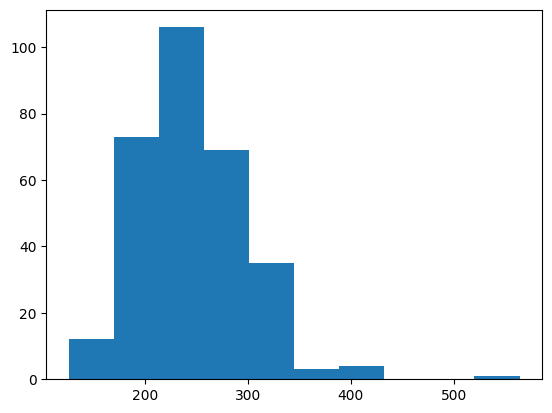

In [73]:
plt.hist(df["chol"])

with more bins:

(array([ 2.,  1.,  2.,  2.,  5., 11.,  7.,  9., 24., 22., 18., 23., 22.,
        23., 20., 18., 18., 14.,  9., 10., 15.,  6.,  7.,  4.,  3.,  1.,
         2.,  0.,  0.,  0.,  1.,  0.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([126.  , 134.76, 143.52, 152.28, 161.04, 169.8 , 178.56, 187.32,
        196.08, 204.84, 213.6 , 222.36, 231.12, 239.88, 248.64, 257.4 ,
        266.16, 274.92, 283.68, 292.44, 301.2 , 309.96, 318.72, 327.48,
        336.24, 345.  , 353.76, 362.52, 371.28, 380.04, 388.8 , 397.56,
        406.32, 415.08, 423.84, 432.6 , 441.36, 450.12, 458.88, 467.64,
        476.4 , 485.16, 493.92, 502.68, 511.44, 520.2 , 528.96, 537.72,
        546.48, 555.24, 564.  ]),
 <BarContainer object of 50 artists>)

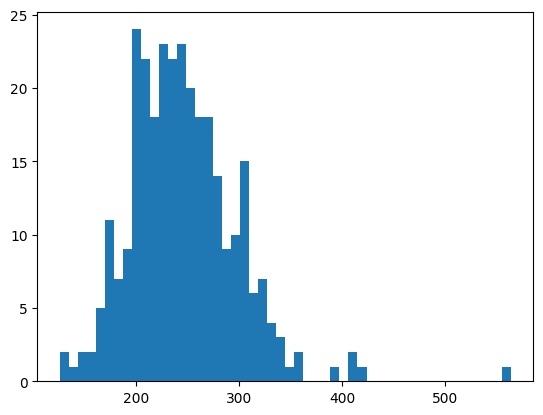

In [74]:
plt.hist(df["chol"],bins=50)

Suppress the return values:

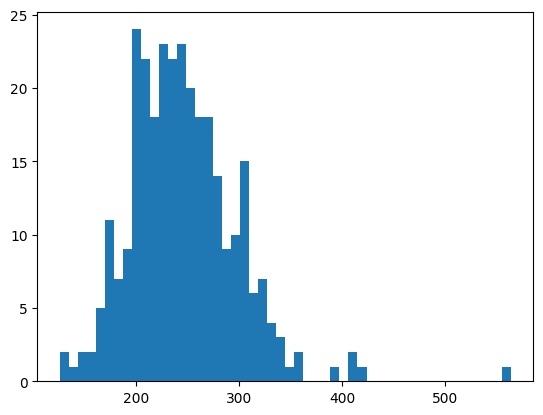

In [75]:
_=plt.hist(df["chol"],bins=50)

#### Counts vs density (normalizing a histogram)

By default, a histogram shows **counts** (how many points landed in each bin).  
Sometimes we want to compare shapes between samples of different size. In that case we normalize so the **area under the histogram is 1**, which lets us interpret it as an estimated probability density. In `matplotlib`, that’s `density=True`.

Number of bins: 5


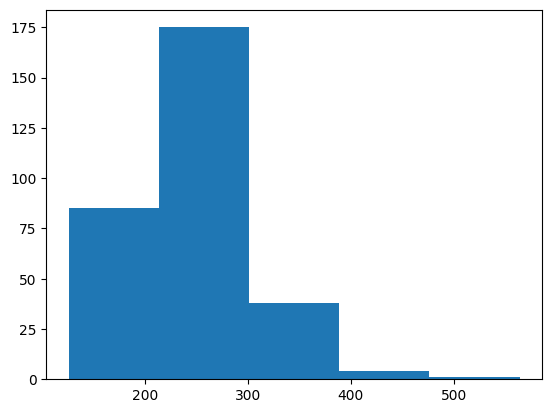

Number of bins: 10


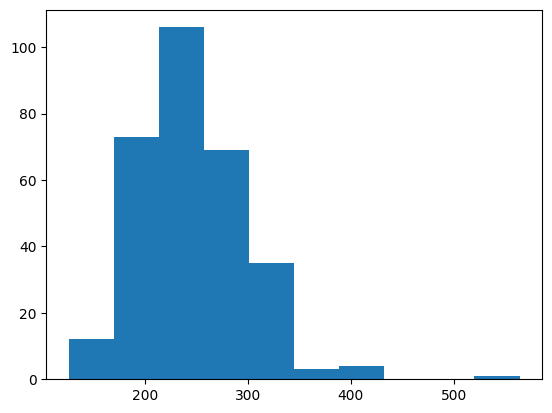

Number of bins: 25


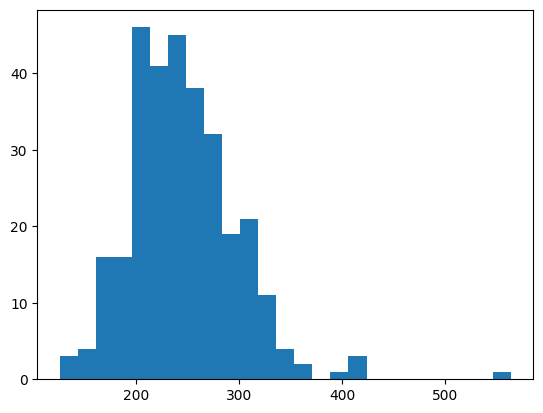

Number of bins: 50


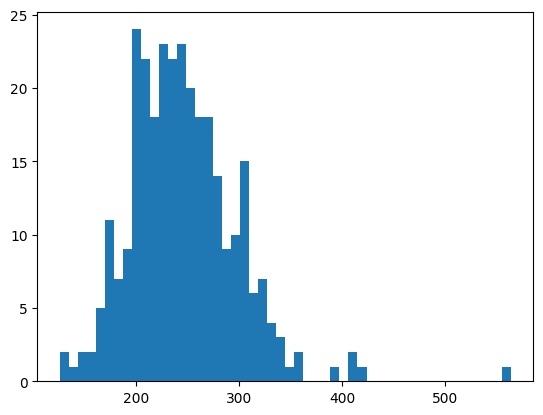

Number of bins: 100


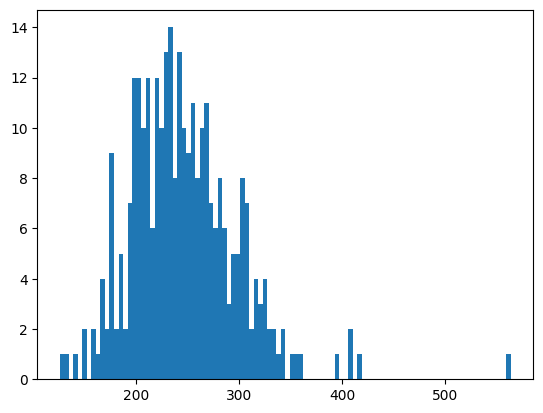

Number of bins: 500


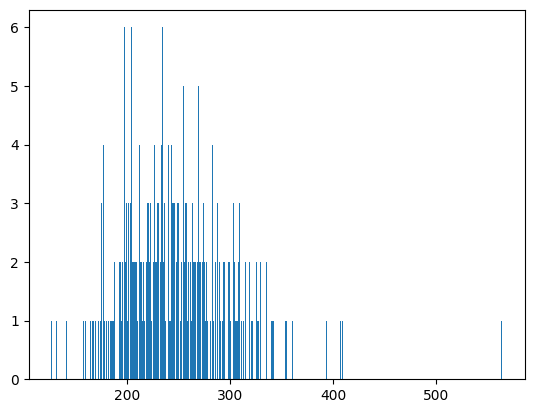

In [76]:
for bins in [5,10,25,50,100,500]:
    print("Number of bins:",bins)
    _=plt.hist(df["chol"],bins=bins)
    plt.show()
#plt.legend()

Number of bins: 500
Number of bins: 100
Number of bins: 50
Number of bins: 25
Number of bins: 10
Number of bins: 5


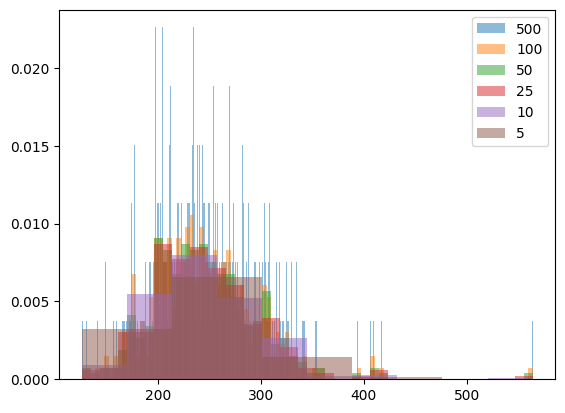

In [77]:
for bins in [5,10,25,50,100,500][::-1]:
    print("Number of bins:",bins)
    _=plt.hist(df["chol"],bins=bins,density=1,label=str(bins), alpha=0.5)
    #plt.show()
plt.legend()

### A histogram example: spotting *two* overlapping populations

A histogram is often the first tool we reach for, because it’s fast and it forces us to think about **shape**:
- Is the distribution symmetric?
- Are there heavy tails?
- Is there evidence for more than one “bump” (i.e., more than one population)?

But binning matters. If two populations overlap strongly, the evidence can be subtle, and what you *think* you see can change with:
- the **number of data points** (*n*), and
- the **number of bins**.

In this example we create data from **two normal populations** with the *same* σ, but their means differ by only **0.5σ**. That’s a lot of overlap—exactly the kind of case where you should be cautious about over-interpreting small wiggles in a histogram.

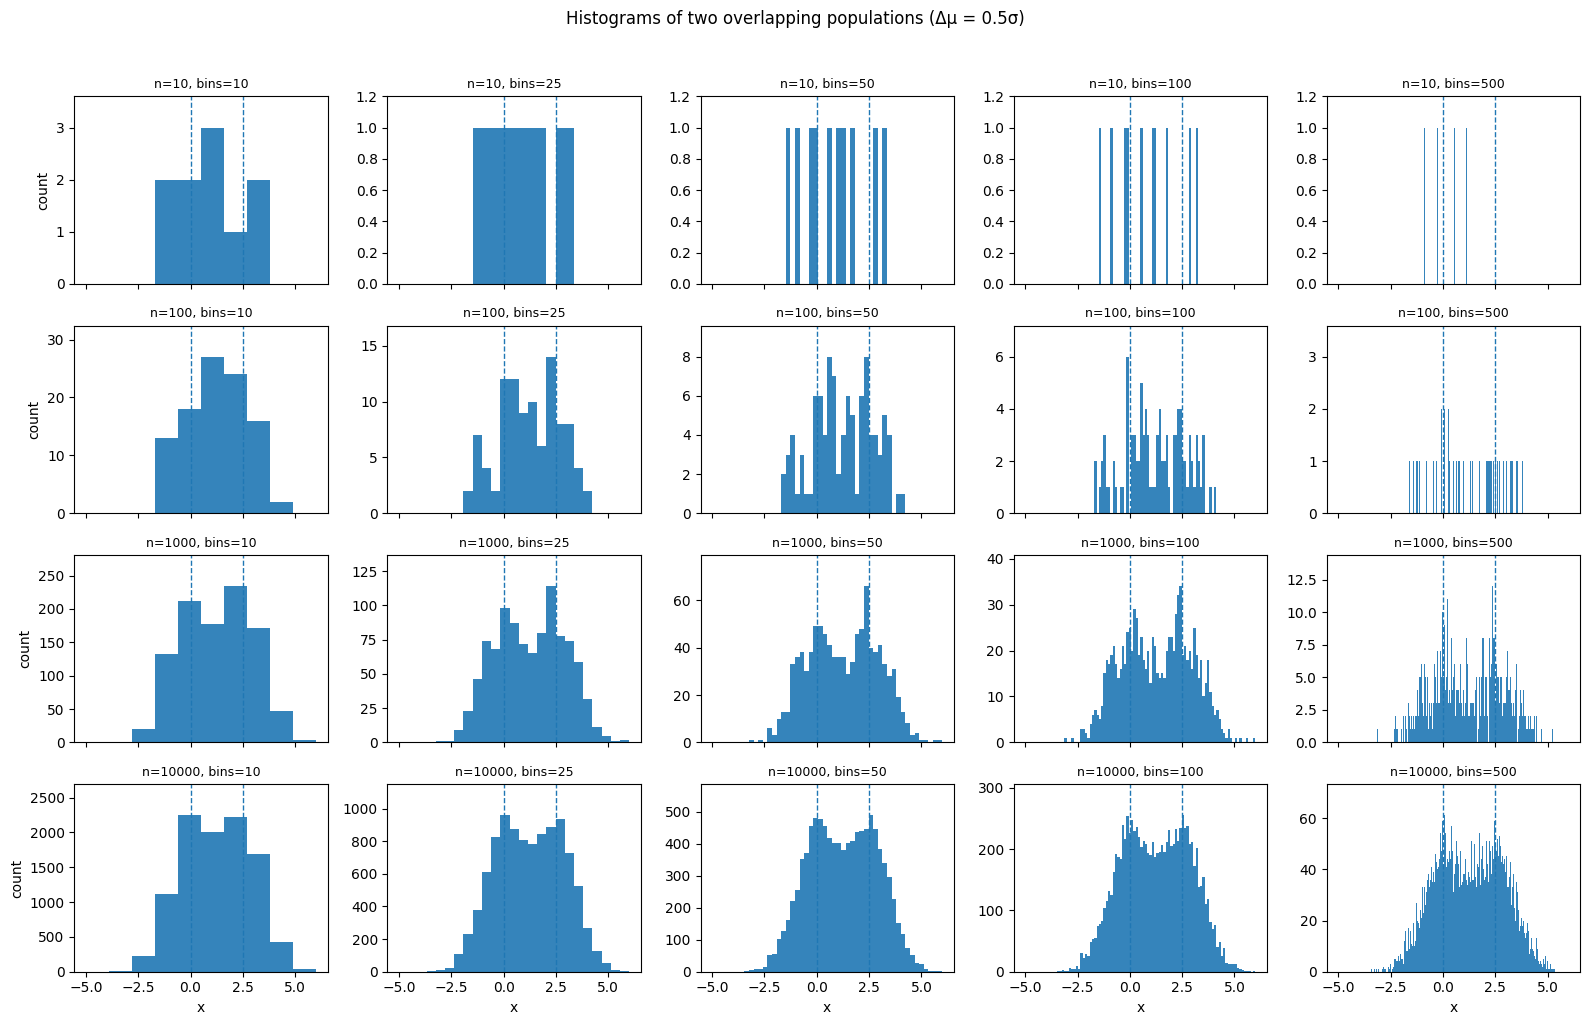

In [78]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(12345)

sigma = 1.0
mu1 = 0.0
mu2 = mu1 + 2.5*sigma

ns = [10, 100, 1000, 10000]
bins_list = [10, 25, 50, 100, 500]

# --- options ---
auto_ylim = True   # each panel scales independently
log_y = False      # log-scale counts
# ----------------

fig, axes = plt.subplots(
    nrows=len(ns),
    ncols=len(bins_list),
    figsize=(16,10),
    sharex=True,
    sharey=not auto_ylim
)

fig.suptitle(
    "Histograms of two overlapping populations (Δμ = 0.5σ)",
    y=1.02
)

x_min, x_max = -5, 6

for i, n in enumerate(ns):

    n1 = n // 2
    n2 = n - n1

    x1 = rng.normal(mu1, sigma, n1)
    x2 = rng.normal(mu2, sigma, n2)
    x = np.concatenate([x1, x2])

    for j, bins in enumerate(bins_list):

        ax = axes[i, j]

        counts, edges, _ = ax.hist(
            x,
            bins=bins,
            range=(x_min, x_max),
            alpha=0.9
        )

        ax.axvline(mu1, linestyle="--", linewidth=1)
        ax.axvline(mu2, linestyle="--", linewidth=1)

        if log_y:
            ax.set_yscale("log")

        if auto_ylim and not log_y:
            ax.set_ylim(0, counts.max() * 1.2)

        ax.set_title(f"n={n}, bins={bins}", fontsize=9)

        if j == 0:
            ax.set_ylabel("count")

        if i == len(ns)-1:
            ax.set_xlabel("x")

plt.tight_layout()
plt.show()

**What to notice**
- With **n = 10**, almost anything can happen. The histogram is dominated by sampling noise.
- With **n = 100**, you might see a hint of asymmetry or a “shoulder,” but it’s ambiguous.
- With **n = 1000–10000**, the shape stabilizes and the mixture becomes more apparent.
- **Too few bins** can smear structure away; **too many bins** can bring noise back in (especially at small *n*).

This is why, in practice, you should treat histograms as a *screening tool*: great for building intuition, not a final proof of multimodality.

## Comparing Populations
There are two populations in the dataset, those with and without heart disease. We would like to see if any of features about the patients (e.g. their cholestrol level) correlate with the disease. Let's first divide us the data into the two populations:

In [79]:
cp_0_selection=df["cp"]==0
cp_not_0_selection=df["cp"]!=0

In [80]:
cp_0_selection

0      False
1      False
2      False
3      False
4       True
       ...  
298     True
299    False
300     True
301     True
302    False
Name: cp, Length: 303, dtype: bool

Then separately historgram the feature to see if the distributions look different for the two populations:

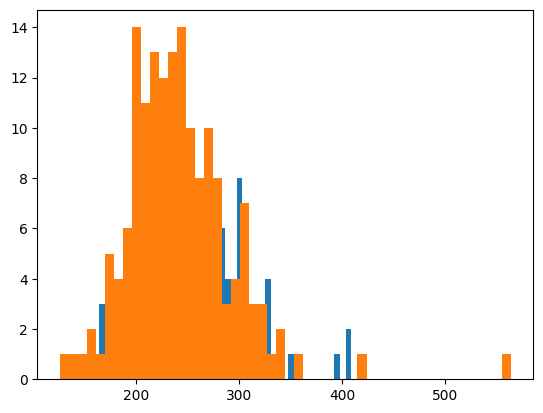

In [81]:
_=plt.hist(df[cp_0_selection]["chol"],bins=50)
_=plt.hist(df[cp_not_0_selection]["chol"],bins=50)

Hmmm... which is which? Need a legend:

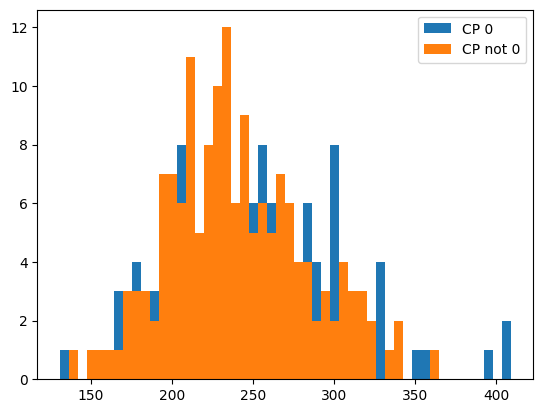

In [82]:
_,bins,_=plt.hist(df[cp_0_selection]["chol"],bins=50,label="CP 0")
_=plt.hist(df[cp_not_0_selection]["chol"],bins=bins,label="CP not 0")
_=plt.legend()

Can't see too well... make the histograms partially transparent:

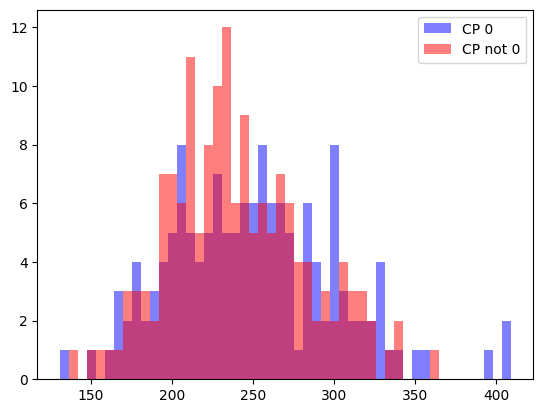

In [83]:
_,bins,_=plt.hist(df[cp_0_selection]["chol"],bins=50,alpha=.5,color='b',label="CP 0")
_=plt.hist(df[cp_not_0_selection]["chol"],bins=bins,alpha=.5,color='r',label="CP not 0")
_=plt.legend()

Not sure if there is a difference in the distributions because there different number of patients in the two populations:

In [84]:
print(np.sum(cp_0_selection))
print(np.sum(cp_not_0_selection))

143
160


What we need is to "normalize" the histogram so the integral is the same, namely 1, therefore we can interpret the histogram as a density:

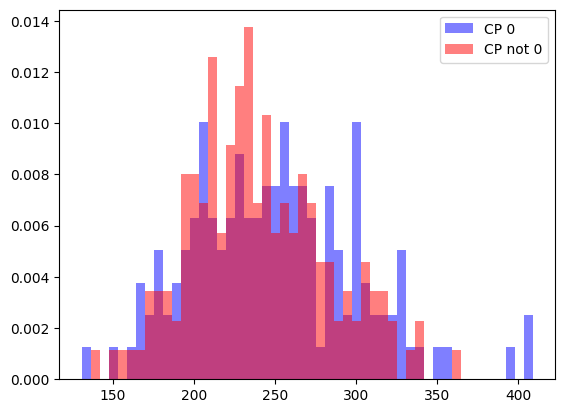

In [85]:
_,bins,_=plt.hist(df[cp_0_selection]["chol"],bins=50,alpha=.5,color='b',density=1,label="CP 0")
_=plt.hist(df[cp_not_0_selection]["chol"],bins=bins,alpha=.5,color='r',density=1,label="CP not 0")
_=plt.legend()

Now we want to do it for all the features, so lets write a function, first to nicely compare distributions of different populations:

In [86]:
def compare_distributions(df,column_name,selections,bins=10.,**kwargs):

    for label,selection in selections.items():        
        _,bins,_=plt.hist(df[selection][column_name],bins=bins,label=label,**kwargs)

    _=plt.legend()


Note that we define the populations using a dictionary:

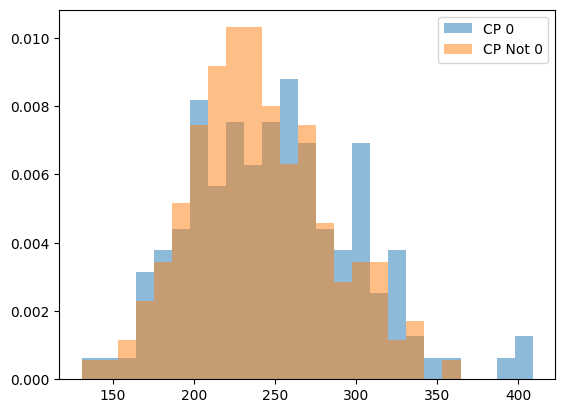

In [87]:
compare_distributions(df,"chol",
                     {"CP 0":df["cp"]==0.,
                      #"CP 1":df["cp"]==1.,
                      #"CP 2":df["cp"]==2.,
                      #"CP 3":df["cp"]==3.,
                      #"CP 4":df["cp"]==4.,
                      "CP Not 0":df["cp"]!=0},
                     alpha=0.5,
                     density=1,
                     bins=25,
                     )

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


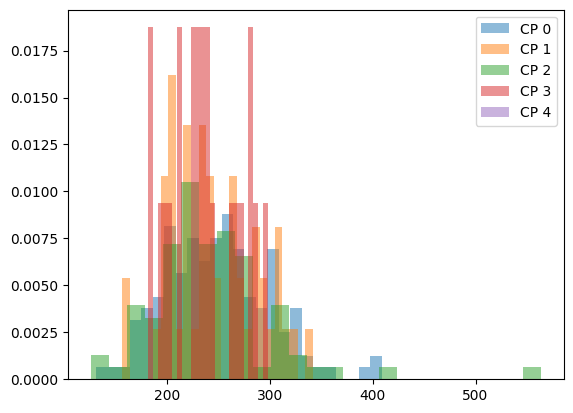

In [20]:
compare_distributions(df,"chol",
                     {"CP 0":df["cp"]==0.,
                      "CP 1":df["cp"]==1.,
                      "CP 2":df["cp"]==2.,
                      "CP 3":df["cp"]==3.,
                      "CP 4":df["cp"]==4.,
                      #"CP Not 0":df["cp"]!=0
                     },
                     alpha=0.5,
                     density=1,
                     bins=25,
                     )

Now lets histogram every feature:

age


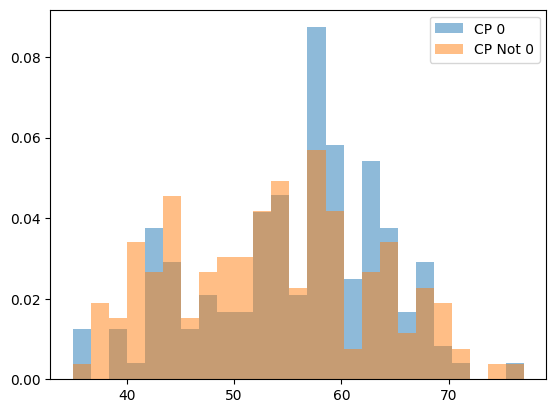

sex


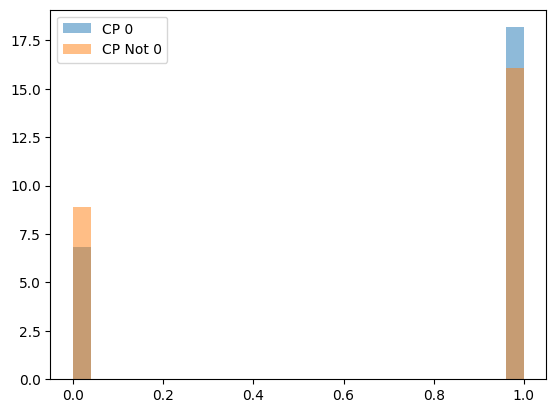

cp


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


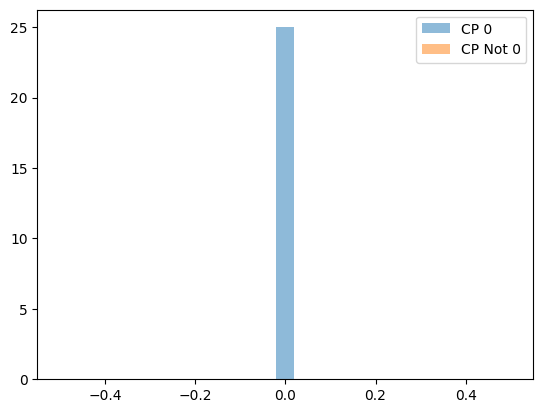

trestbps


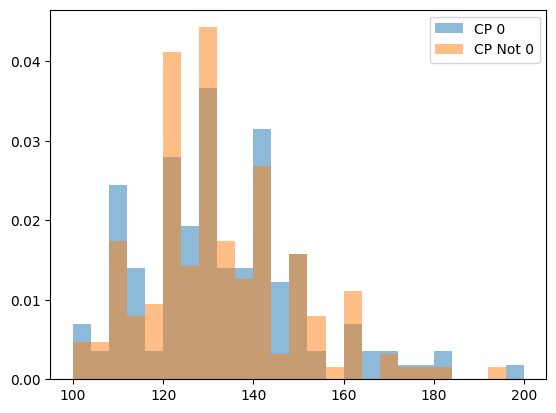

chol


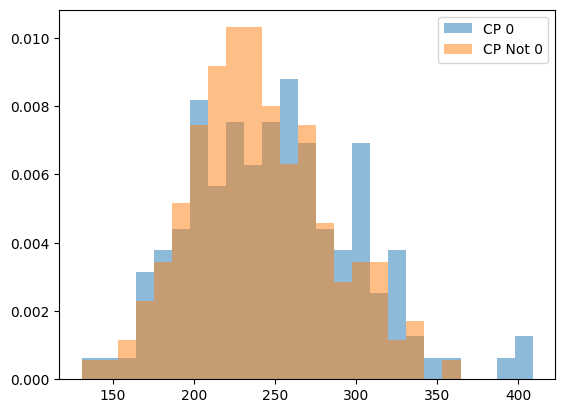

fbs


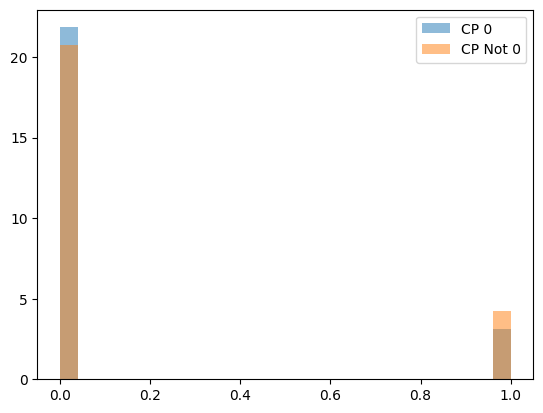

restecg


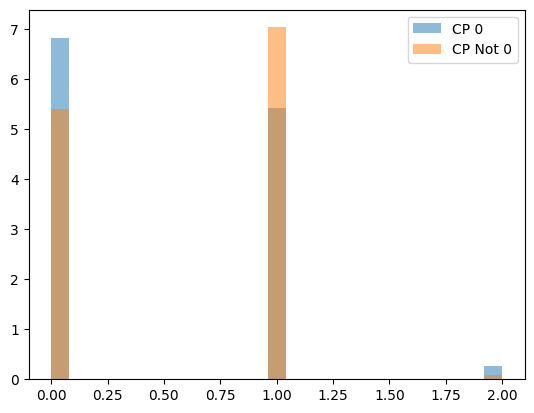

thalach


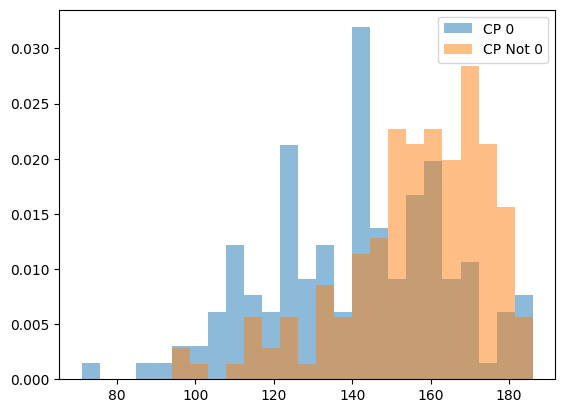

exang


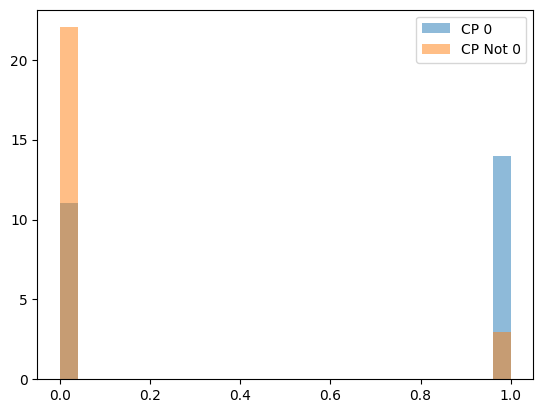

oldpeak


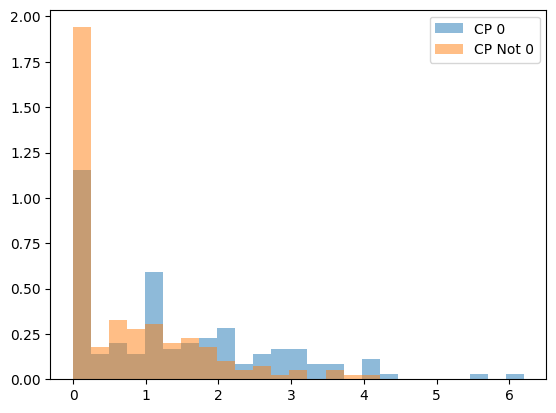

slope


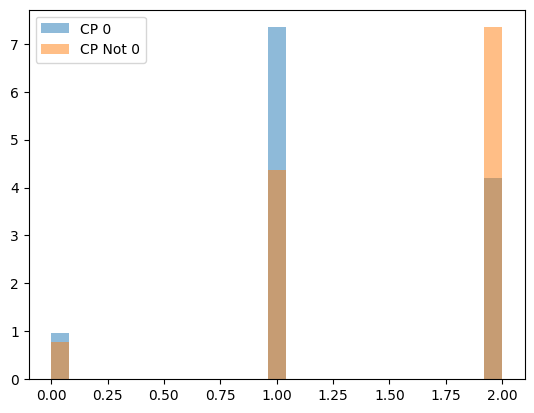

ca


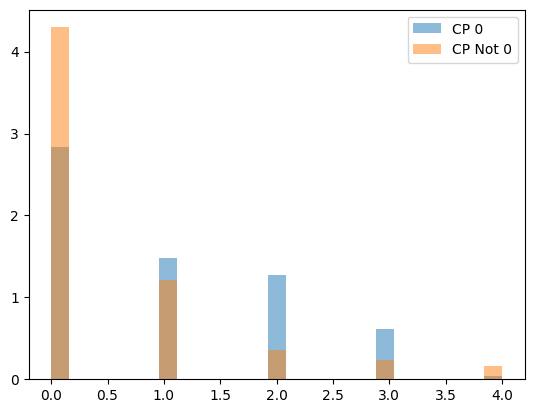

thal


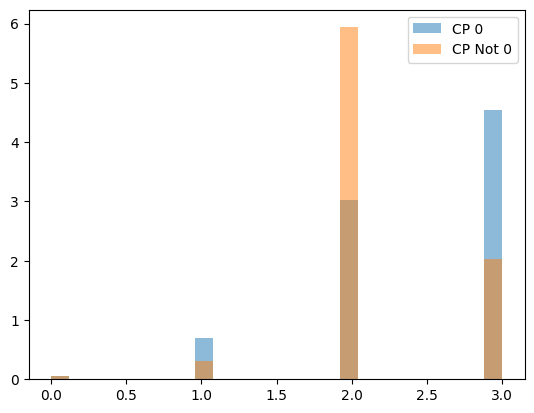

target


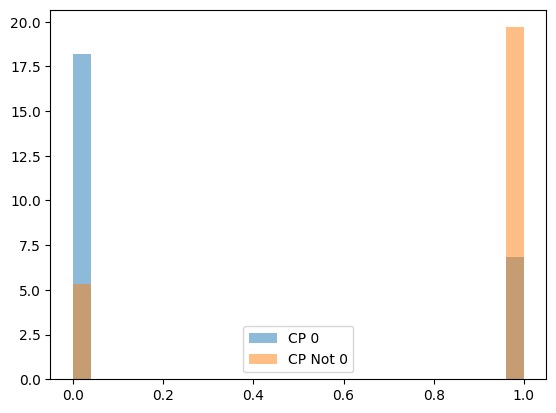

In [88]:
selection_dict={"CP 0":df["cp"]==0.,"CP Not 0":df["cp"]!=0}

for column_name in df.columns:
    print(column_name)
    compare_distributions(df,column_name,
                     selection_dict,
                     alpha=0.5,
                     density=1,
                     bins=25,
                     )
    plt.show()

In [22]:
len(df.columns)

14

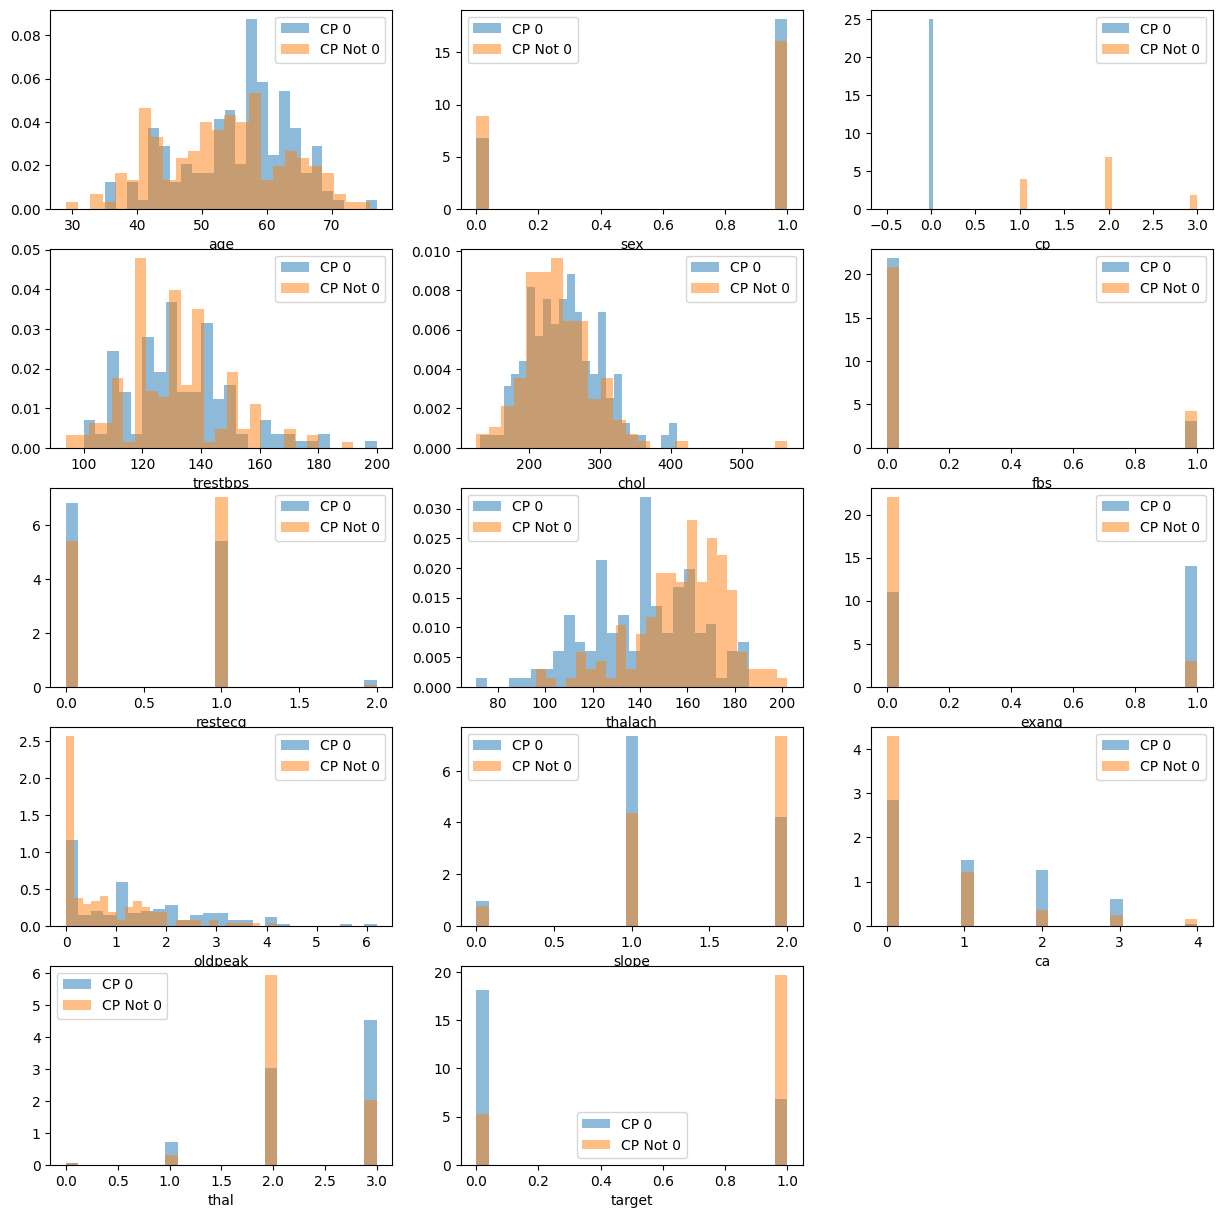

In [23]:
selection_dict={"CP 0":df["cp"]==0.,"CP Not 0":df["cp"]!=0}

plt.figure(figsize=(15,15))

for i,column_name in enumerate(df.columns):
    plt.subplot(5,3,i+1)
    compare_distributions(df,column_name,
                     selection_dict,
                     alpha=0.5,
                     density=1,
                     bins=25,
                     stacked=True
                     )
    plt.xlabel(column_name)
plt.show()

For the categorical features, the information in the histogram can be summarized better in a table of what fraction of each population belongs to each category. Quick example of such tables:

**Mini-workflow block**

The next few cells are meant to be read as *one* block: we run a short sequence of commands to answer a single question about the data.

*(First line: `def compare_categorical(df,column_name,selections,**kwargs):`)*

In [24]:
def compare_categorical(df,column_name,selections,**kwargs):
    out = list()
    
    for label,selection in selections.items():        
        total = np.sum(selection)
        df_0=df[selection]
        values = df_0[column_name].unique()
        out.append([label] + [ np.sum(df_0[column_name]==val)/total for val in values ])
        
    return out,values


In [25]:
from IPython.display import HTML, display
import tabulate

In [26]:
results = compare_categorical(df,"sex",selection_dict)
print(results)
display(HTML(tabulate.tabulate(results[0], tablefmt='html', headers=results[1])))

([['CP 0', np.float64(0.2727272727272727), np.float64(0.7272727272727273)], ['CP Not 0', np.float64(0.64375), np.float64(0.35625)]], array([1, 0]))


,1,0
CP 0,0.272727,0.727273
CP Not 0,0.64375,0.35625


In [27]:
for cat_feature in ["sex","thal","ca", "slope", "exang","restecg", "fbs"]:
    print(cat_feature)
    results = compare_categorical(df,cat_feature,selection_dict)
    display(HTML(tabulate.tabulate(results[0], tablefmt='html', headers=results[1])))
  

sex


,1,0
CP 0,0.272727,0.727273
CP Not 0,0.64375,0.35625


thal


,1,2,3,0
CP 0,0.363636,0.0839161,0.545455,0.00699301
CP Not 0,0.0375,0.7125,0.24375,0.00625


ca


...

,0,1
CP 0,0.559441,0.440559
CP Not 0,0.88125,0.11875


restecg


,0,1,2
CP 0,0.433566,0.545455,0.020979
CP Not 0,0.43125,0.5625,0.00625


fbs


,1,0
CP 0,0.874126,0.125874
CP Not 0,0.16875,0.83125


In [28]:
def compare_categorical_T(df,column_name,selections,**kwargs):
    out = list()
    values = df[column_name].unique()        
    N_val = dict([ (val, np.sum(df[column_name]==val)) for val in values ])

    for label,selection in selections.items():        
        total = np.sum(selection)
        df_0=df[selection]
        out.append([label] + [ np.sum(df_0[column_name]==val)/N_val[val] for val in values ])       
    
        
    return out,values


for cat_feature in ["sex","thal","ca", "slope", "exang","restecg", "fbs"]:
    print(cat_feature)
    results = compare_categorical_T(df,cat_feature,selection_dict)
    #print(results[0])
    display(HTML(tabulate.tabulate(results[0], tablefmt='html', headers=results[1])))
  

sex


,1,0
CP 0,0.502415,0.40625
CP Not 0,0.497585,0.59375


thal


,1,2,3,0
CP 0,0.666667,0.313253,0.666667,0.5
CP Not 0,0.333333,0.686747,0.333333,0.5


ca


...

,0,1
CP 0,0.308824,0.808081
CP Not 0,0.691176,0.191919


restecg


,0,1,2
CP 0,0.530612,0.407895,0.75
CP Not 0,0.469388,0.592105,0.25


fbs


,1,0
CP 0,0.4,0.484496
CP Not 0,0.6,0.515504


## 1-D Plots

**Mini-workflow block**

The next few cells are meant to be read as *one* block: we run a short sequence of commands to answer a single question about the data.

*(First line: `import math`)*

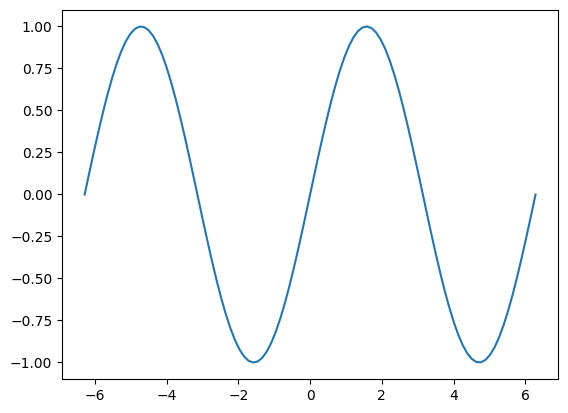

In [29]:
import math

x = np.linspace(-2.*math.pi,2.*math.pi,100)
y = list(map(math.sin,x))

_=plt.plot(x,y)

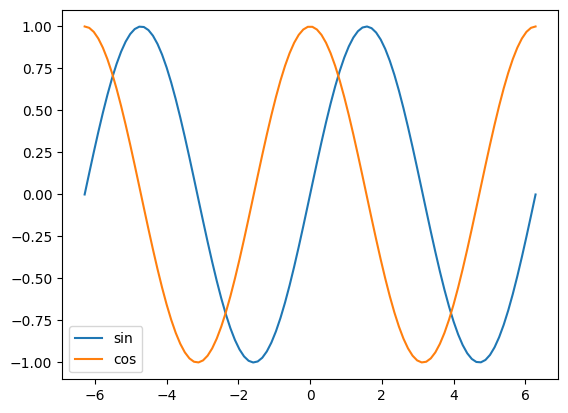

In [30]:
x = np.linspace(-2.*math.pi,2.*math.pi,100)
y_1 = list(map(math.sin,x))
y_2 = list(map(math.cos,x))

_=plt.plot(x,y_1,label="sin")
_=plt.plot(x,y_2,label="cos")

_=plt.legend()

In [31]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

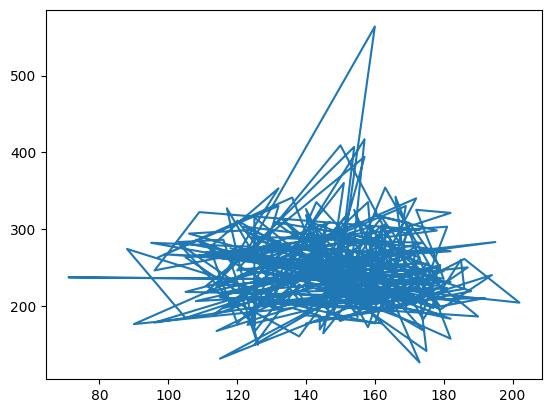

In [32]:
_=plt.plot(df["thalach"],df["chol"])

## 2-D Plots

When in comes to data, looking at 2 random variables together can serve to see trends in correlations between the variables. 2D histograms are one way to see this info 

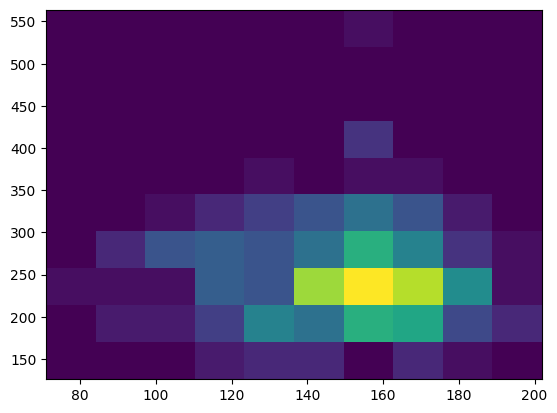

In [33]:
_=plt.hist2d(df["thalach"],df["chol"])

But they can be difficult to compare trends in correlations in different populations.

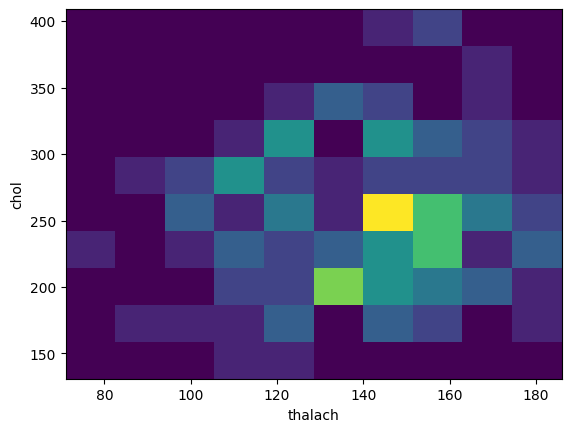

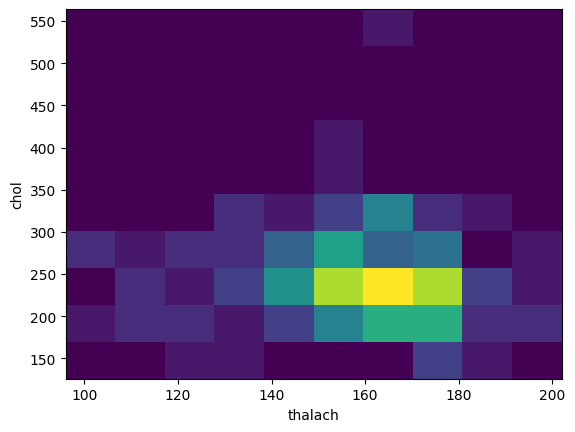

In [34]:
selection_dict={"CP 0":df["cp"]==0.,"CP Not 0":df["cp"]!=0}

for label,selection in selection_dict.items():   
    _=plt.hist2d(df[selection]["thalach"],df[selection]["chol"],label=label)

    _=plt.xlabel("thalach")
    _=plt.ylabel("chol")

    plt.show()

Scatter plots can be useful in this instance:

**Mini-workflow block**

The next few cells are meant to be read as *one* block: we run a short sequence of commands to answer a single question about the data.

*(First line: `_=plt.scatter(df["thalach"],df["chol"])`)*

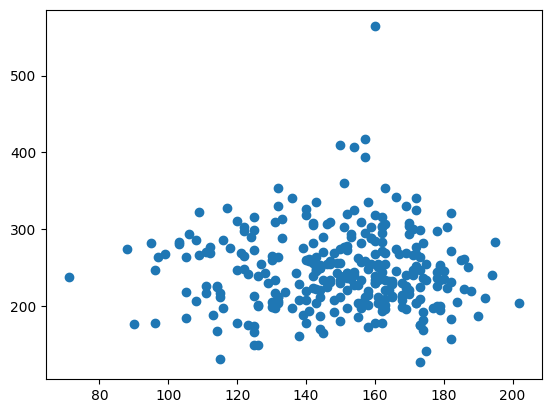

In [35]:
_=plt.scatter(df["thalach"],df["chol"])

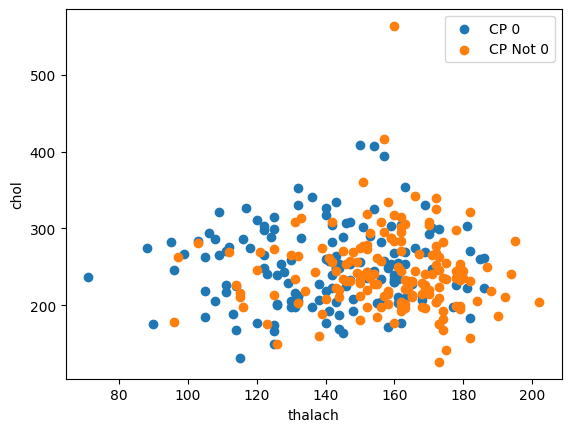

In [36]:
selection_dict={"CP 0":df["cp"]==0.,"CP Not 0":df["cp"]!=0}

for label,selection in selection_dict.items():   
    _=plt.scatter(df[selection]["thalach"],df[selection]["chol"],label=label)

_=plt.xlabel("thalach")
_=plt.ylabel("chol")

_=plt.legend()


In [37]:
selection_dict={"CP 0":df["cp"]==0.,"CP Not 0":df["cp"]!=0}

def compare_scatter(df,x_var_name,y_var_name,selections,make_legend=True) :
    for label,selection in selections.items():   
        _=plt.scatter(df[selection][x_var_name],df[selection][y_var_name],label=label)

    _=plt.xlabel(x_var_name)
    _=plt.ylabel(y_var_name)

    if make_legend:
        _=plt.legend()



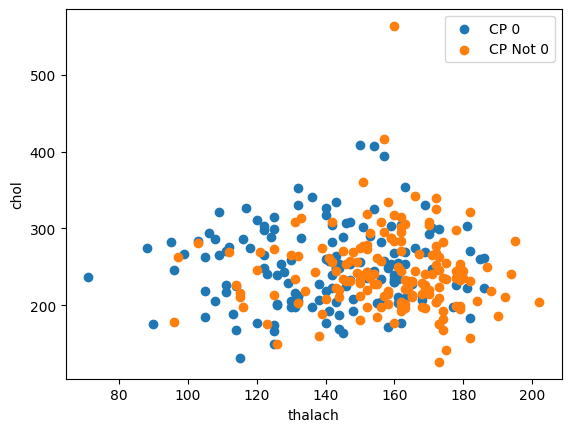

In [38]:
compare_scatter(df,"thalach","chol",selection_dict)

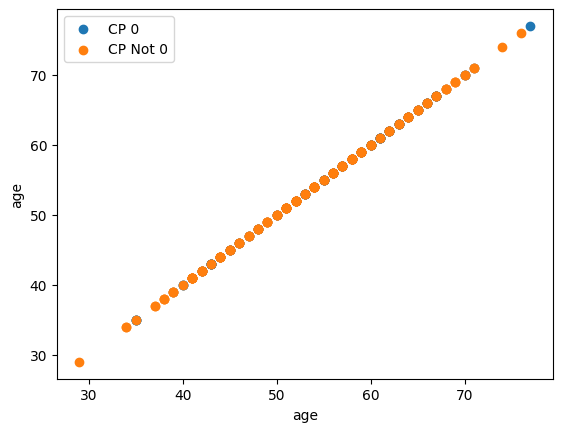

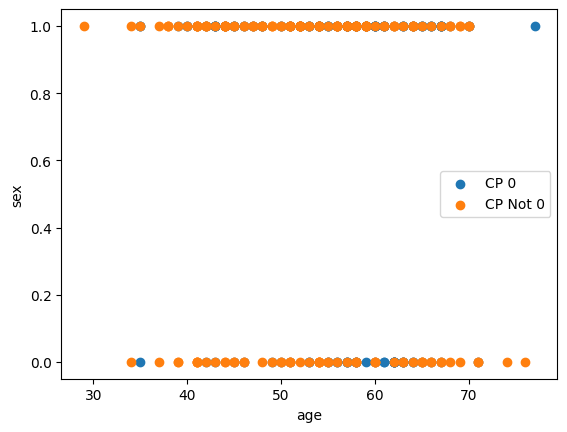

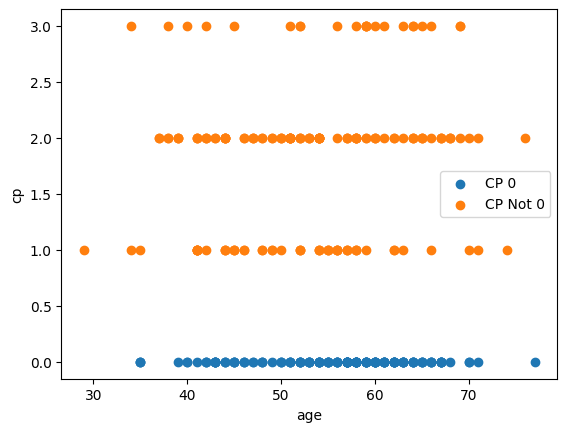

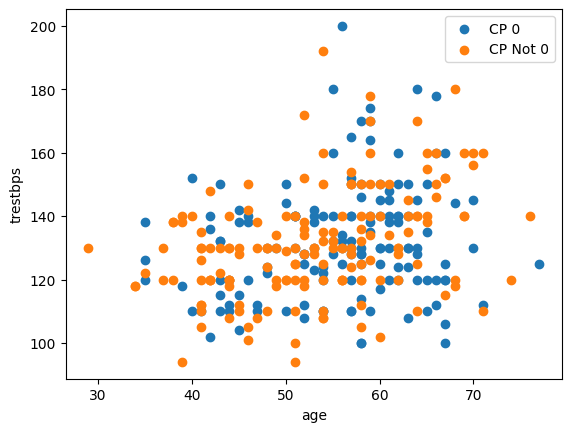

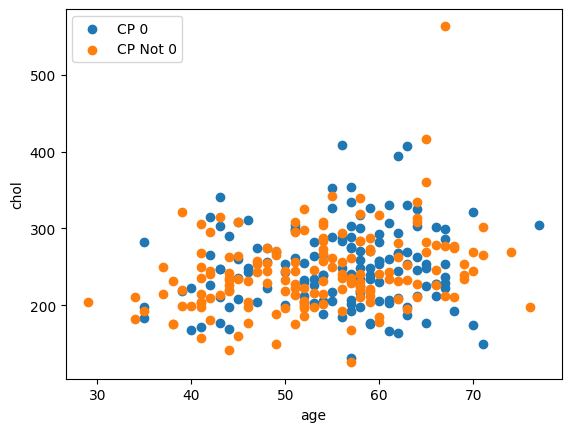

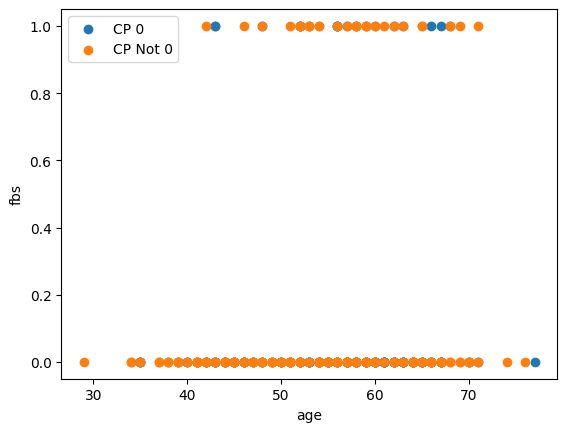

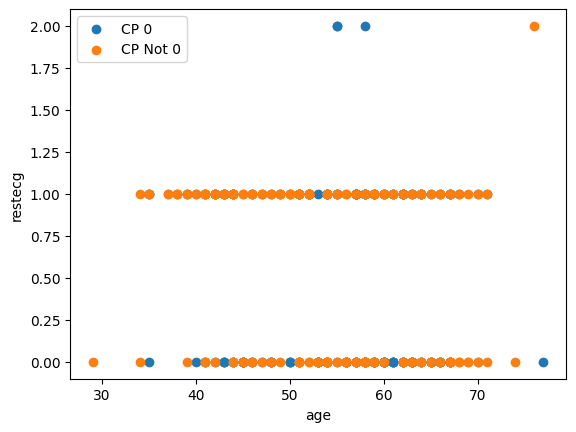

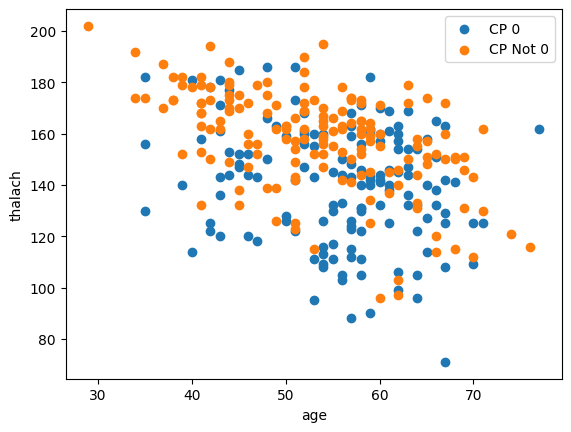

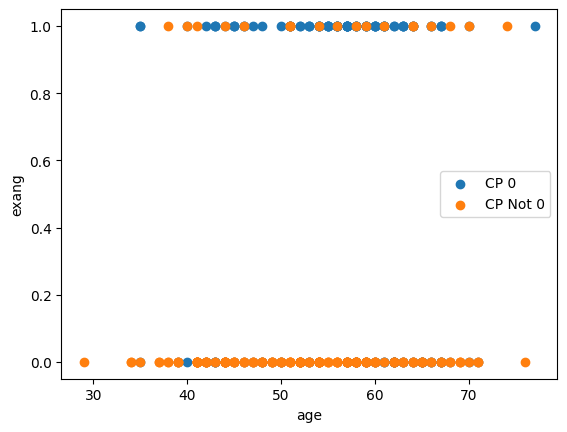

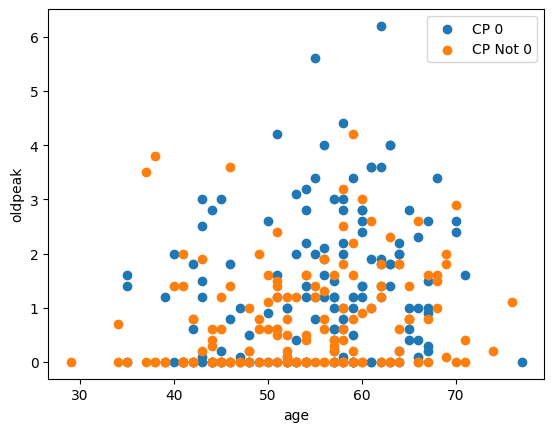

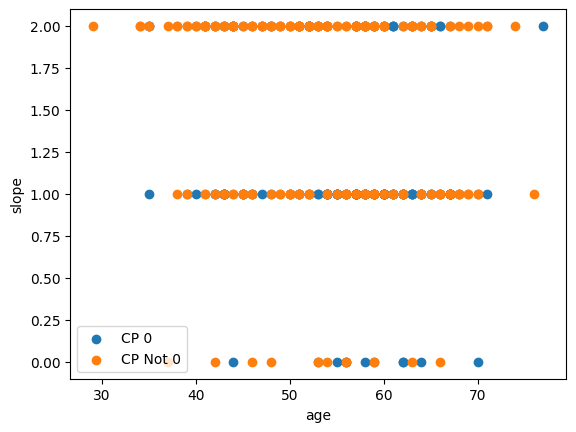

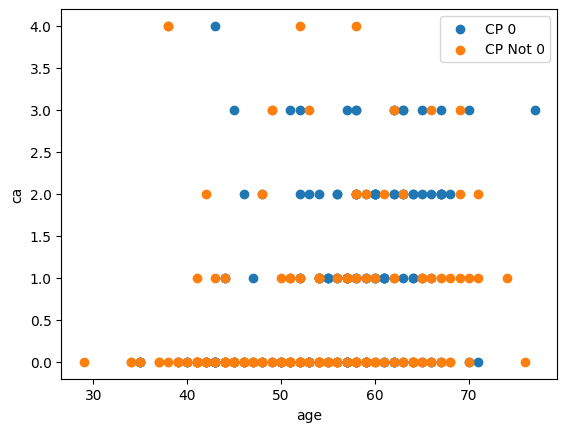

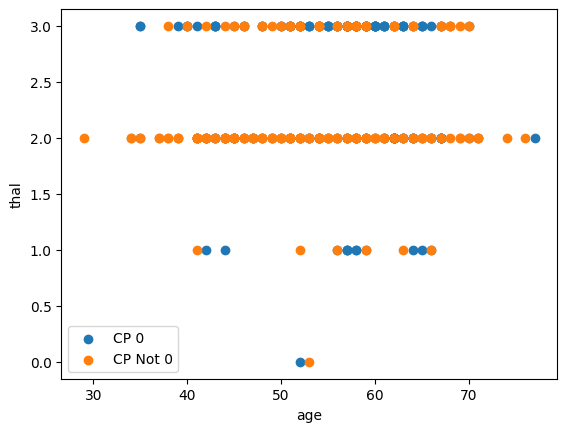

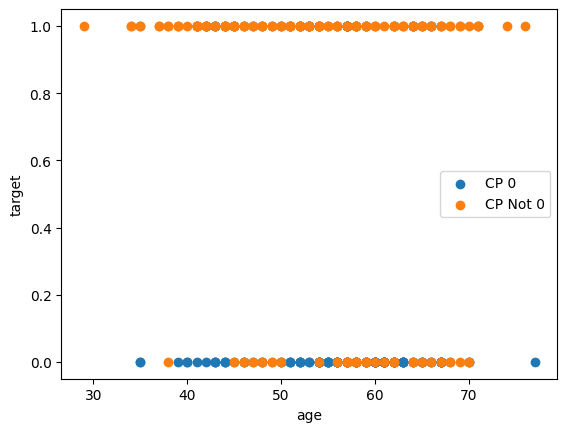

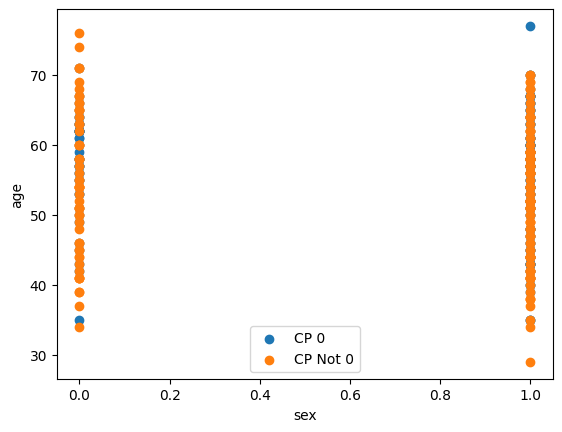

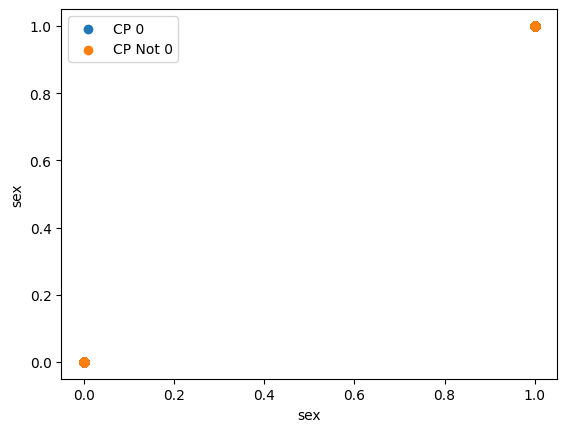

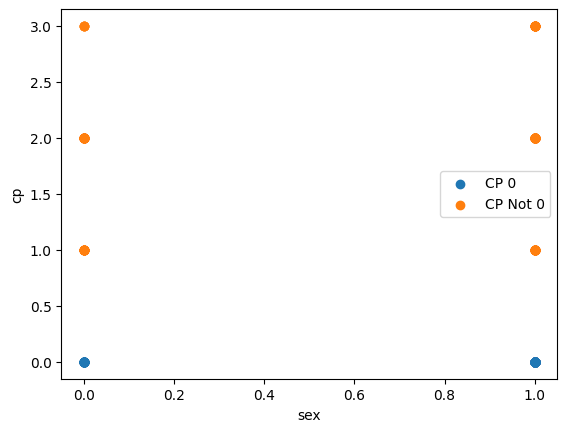

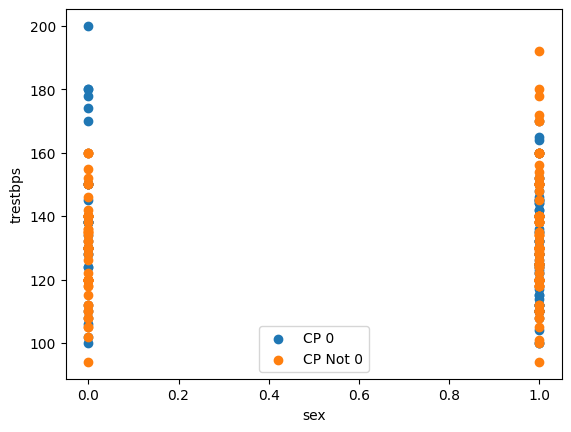

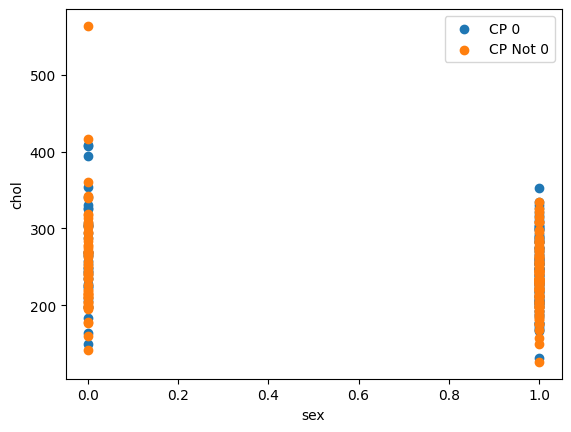

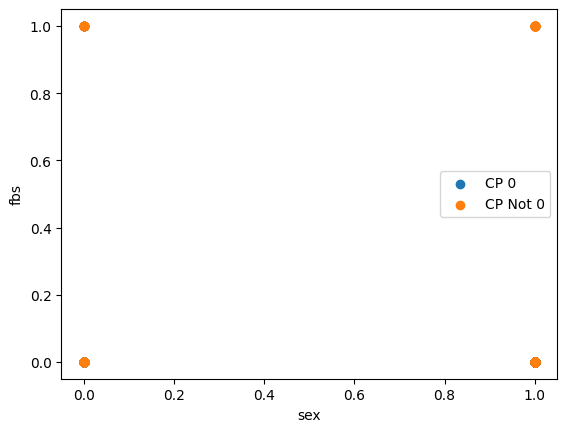

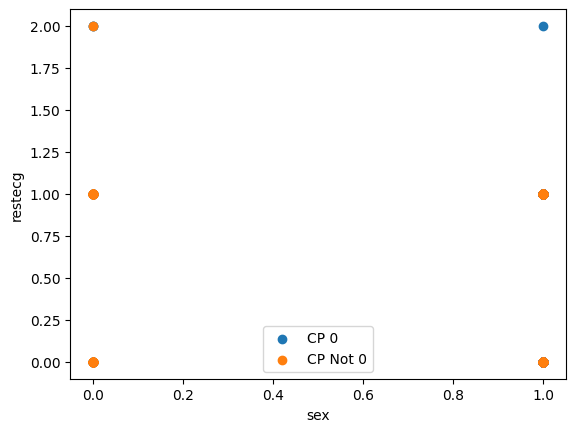

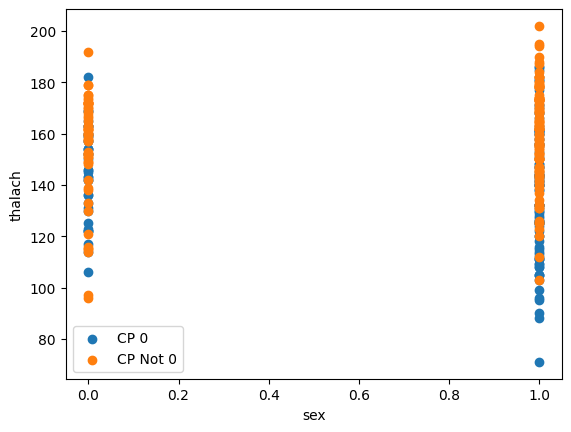

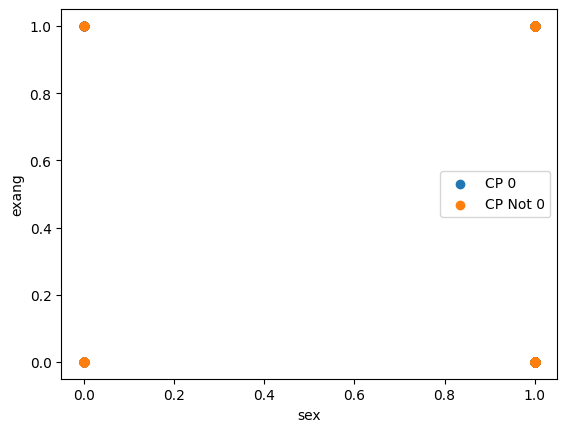

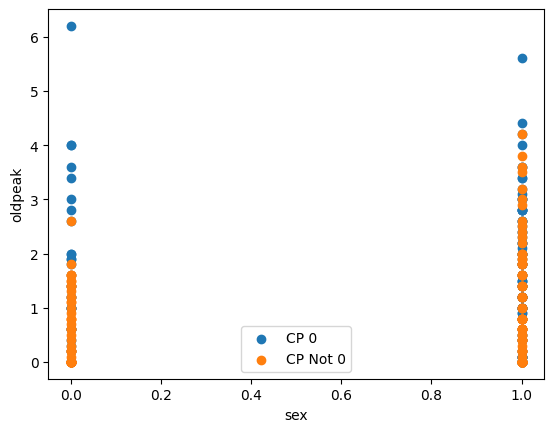

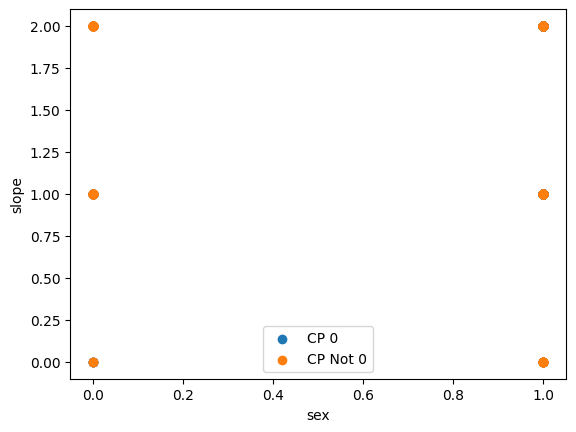

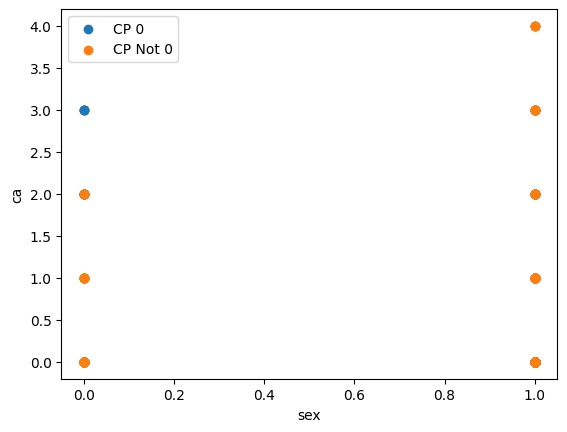

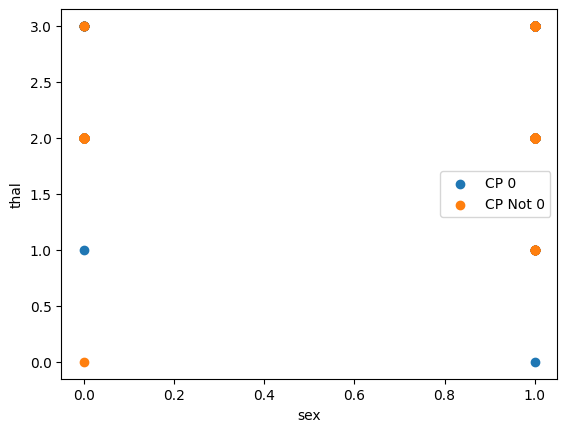

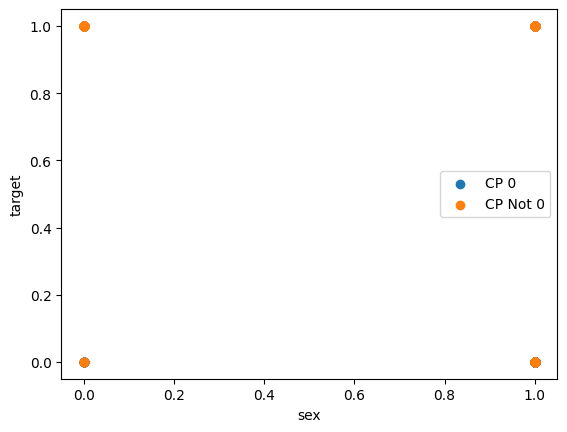

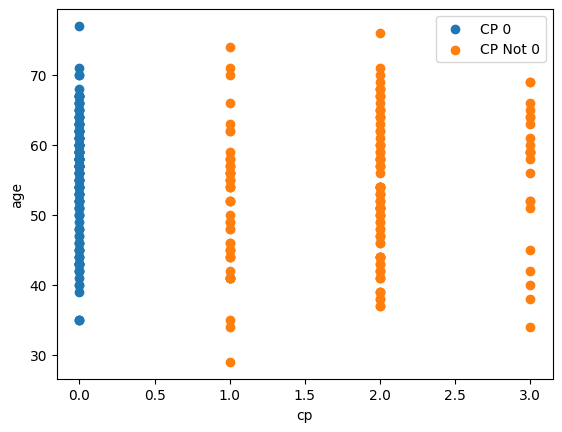

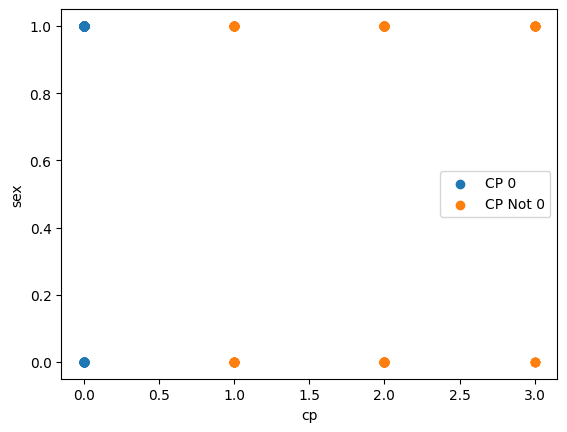

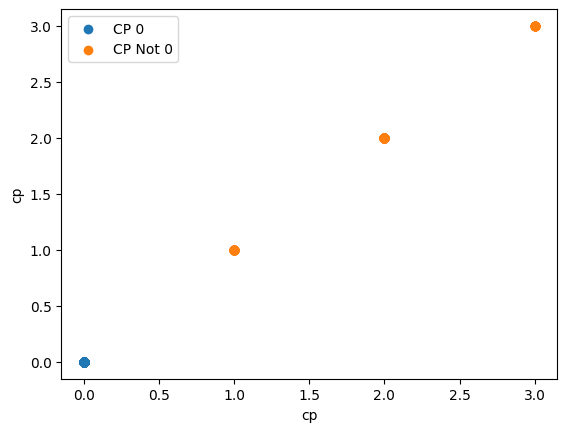

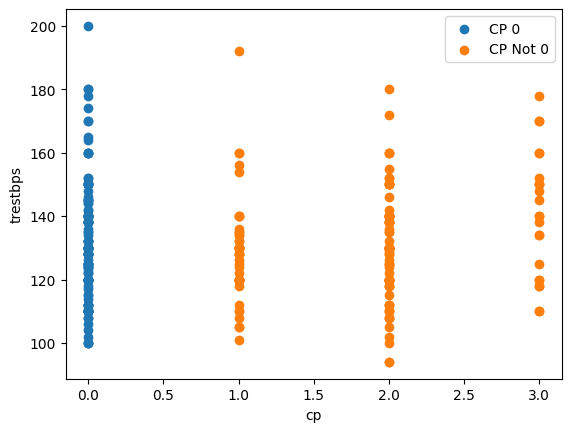

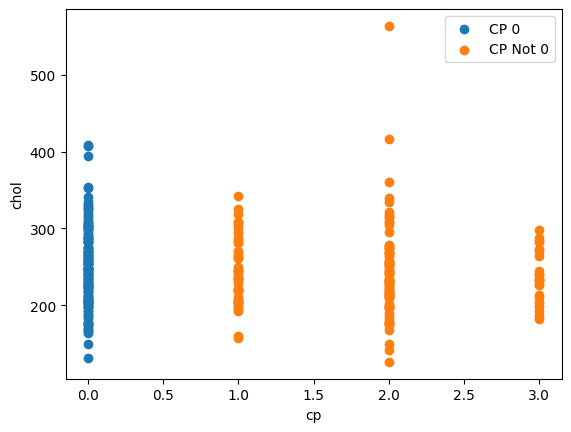

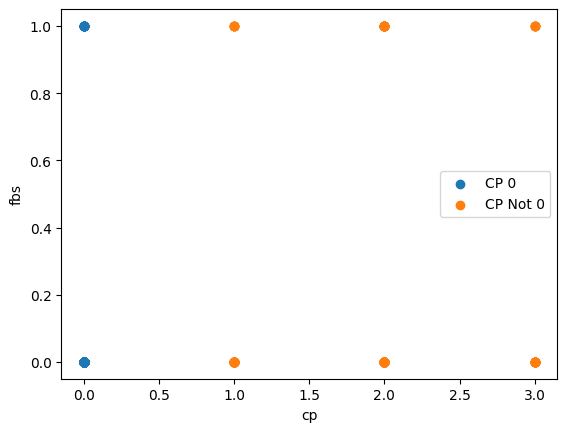

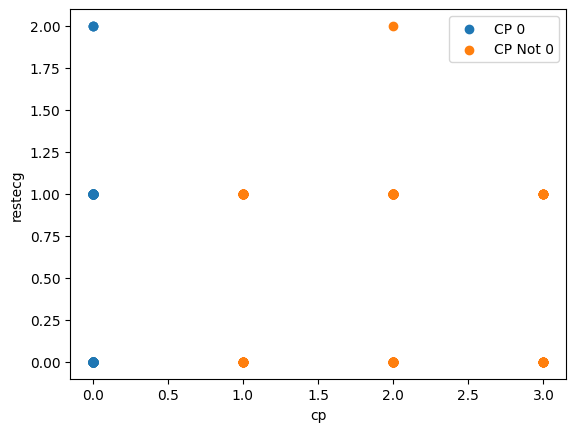

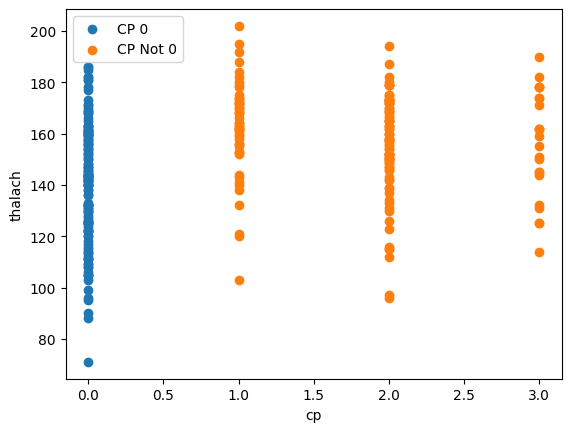

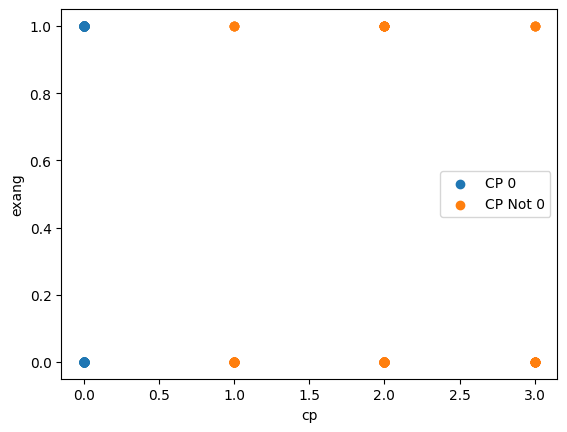

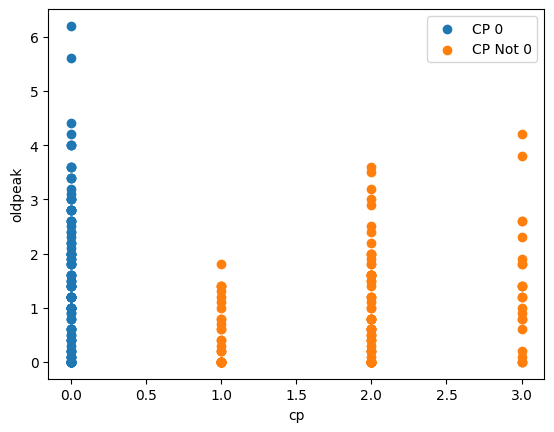

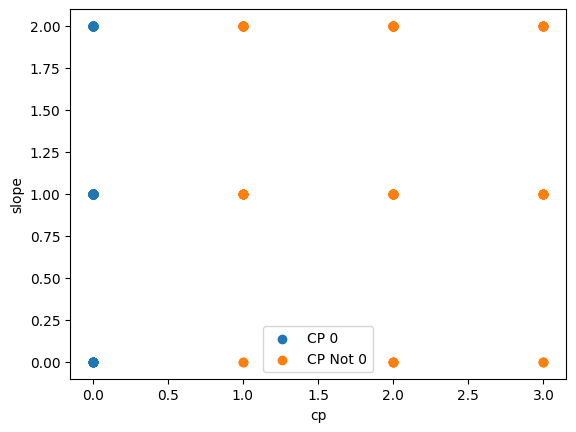

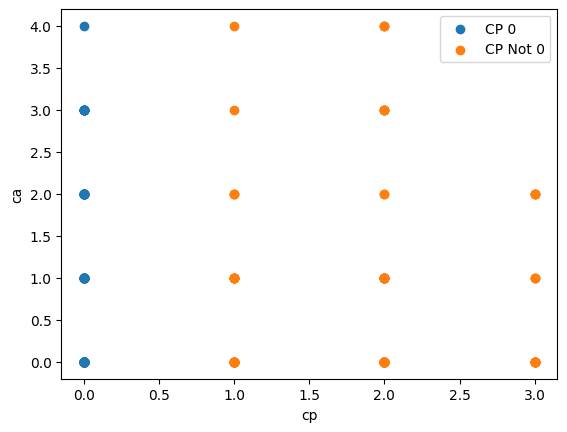

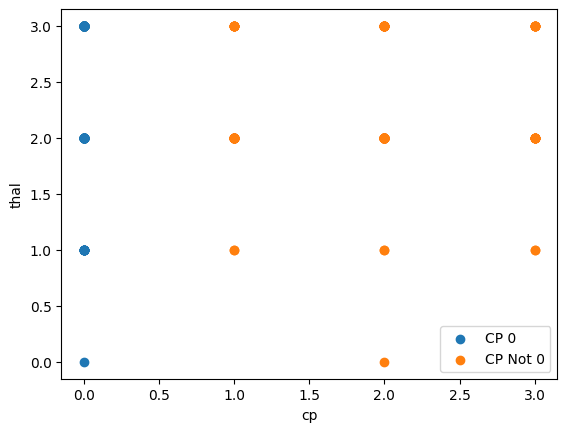

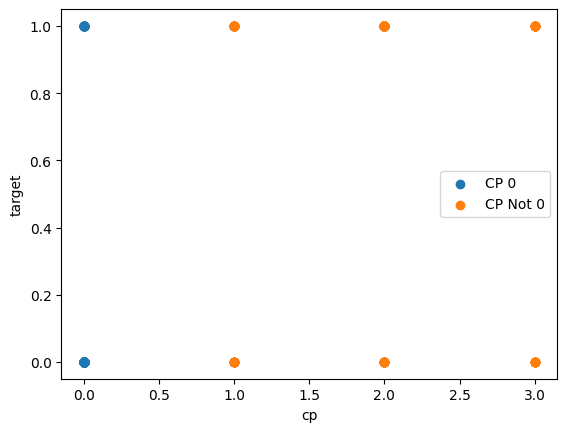

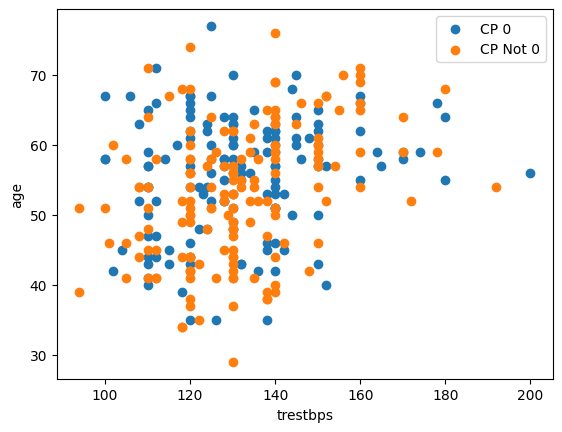

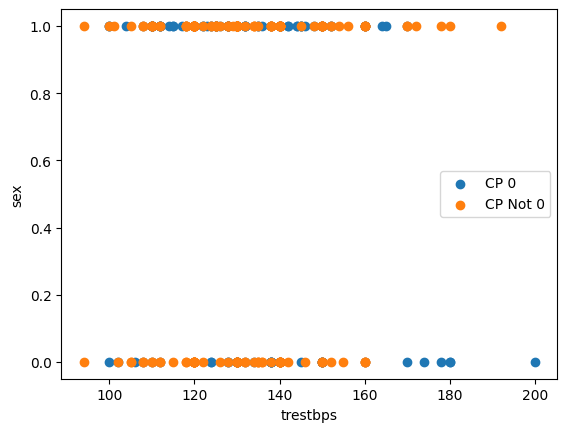

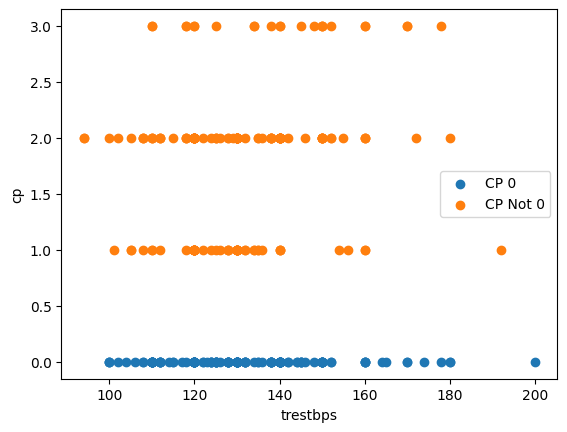

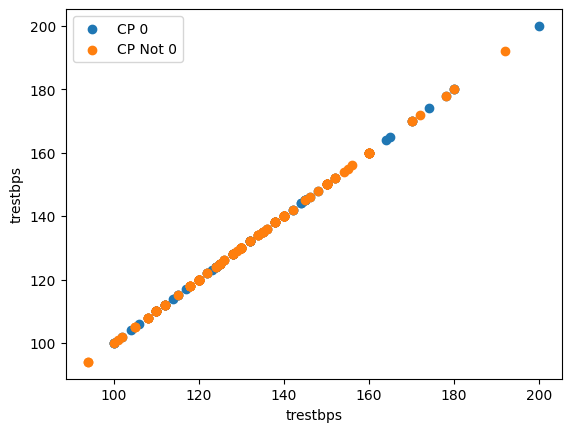

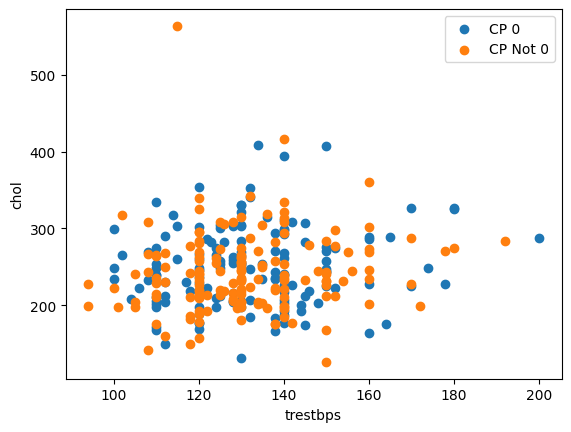

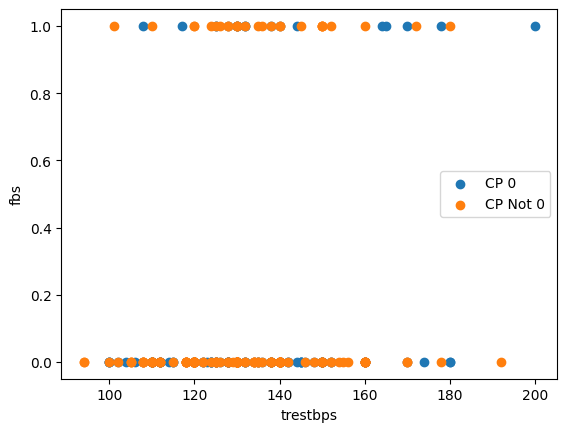

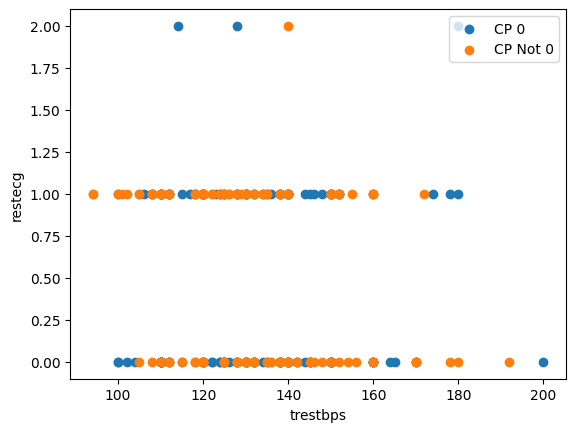

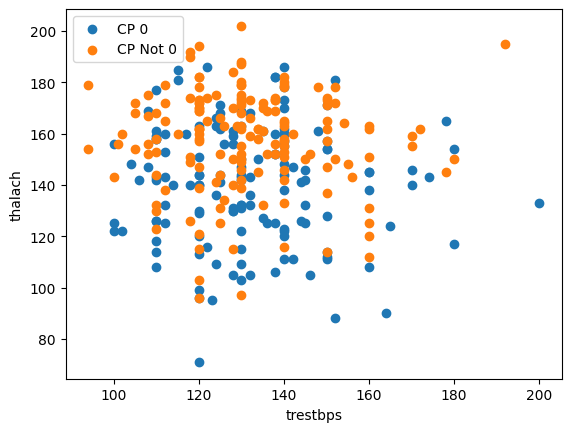

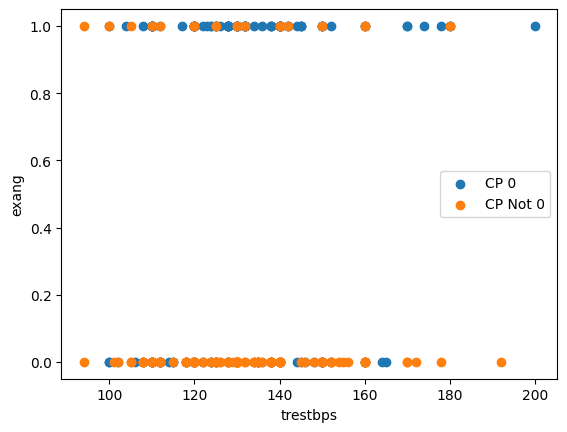

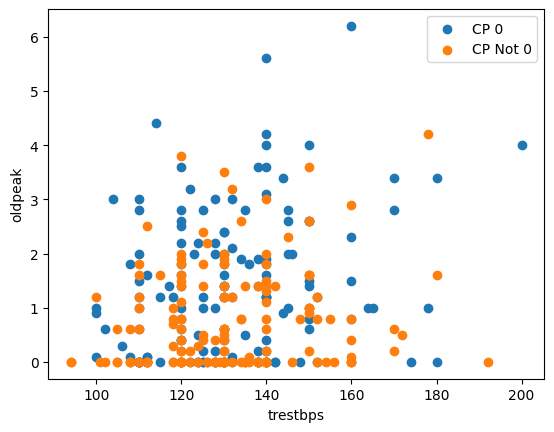

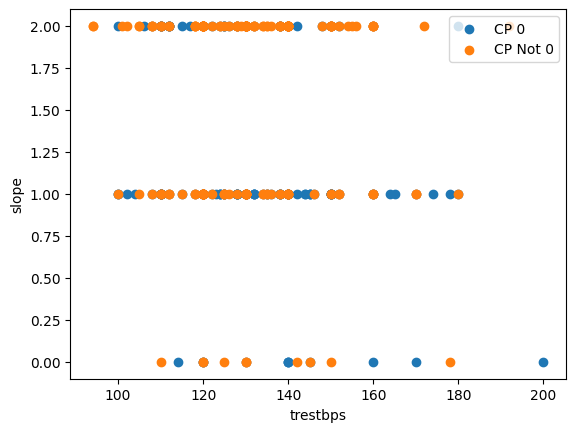

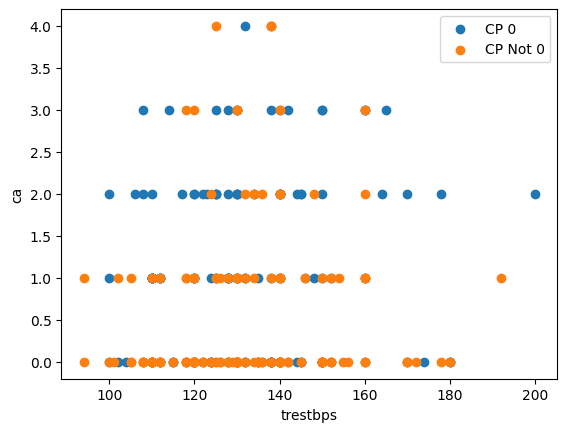

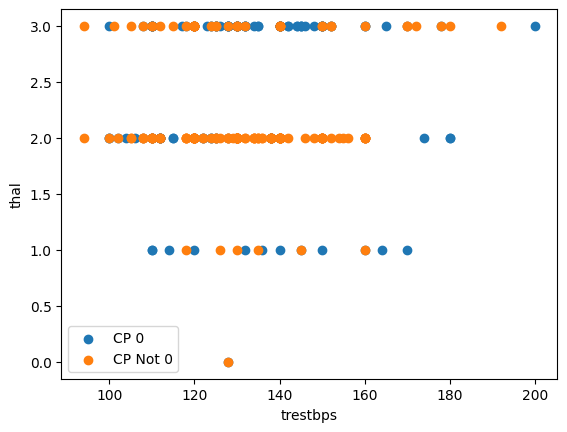

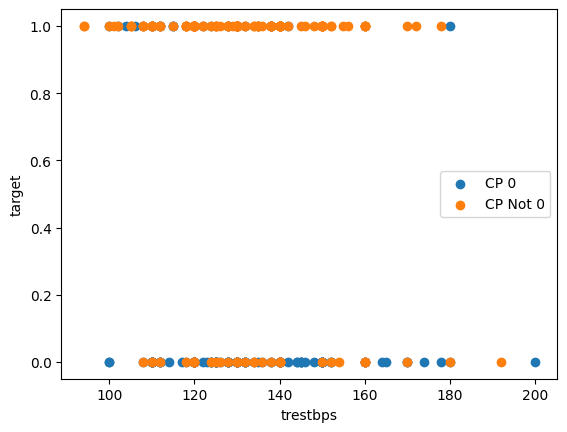

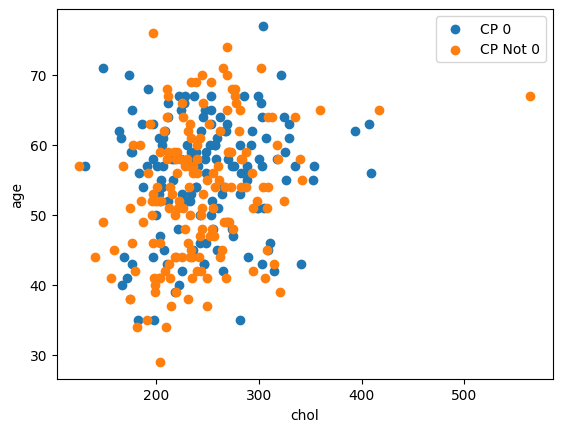

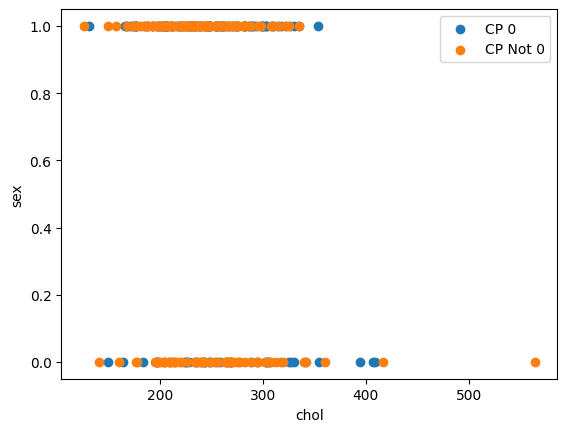

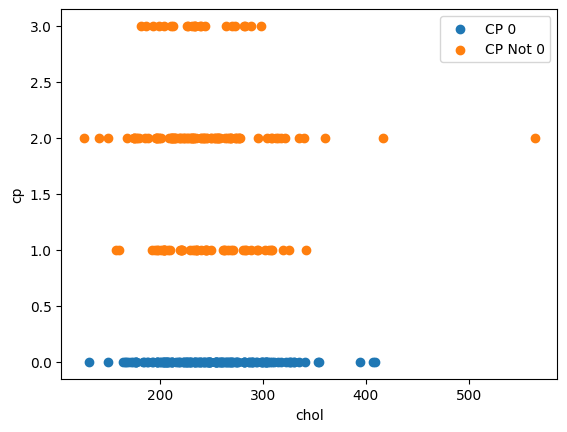

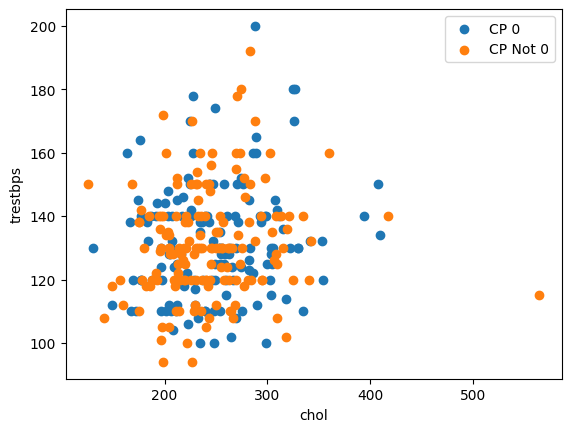

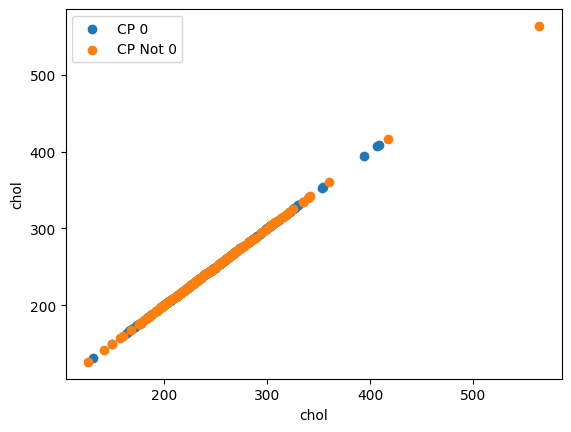

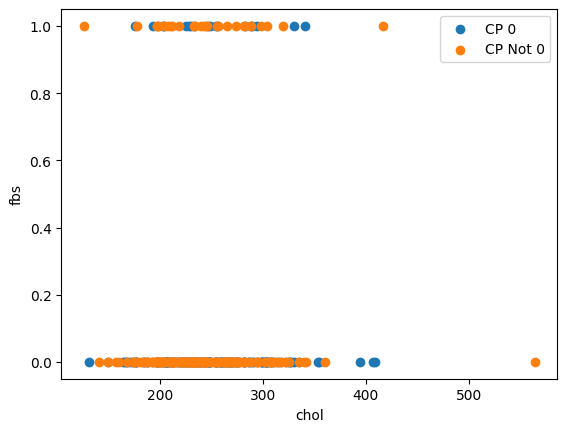

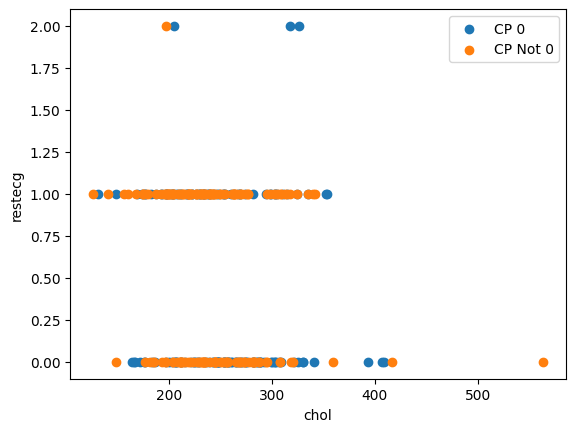

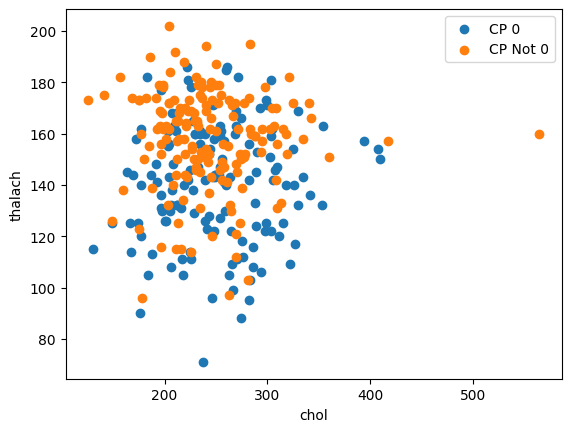

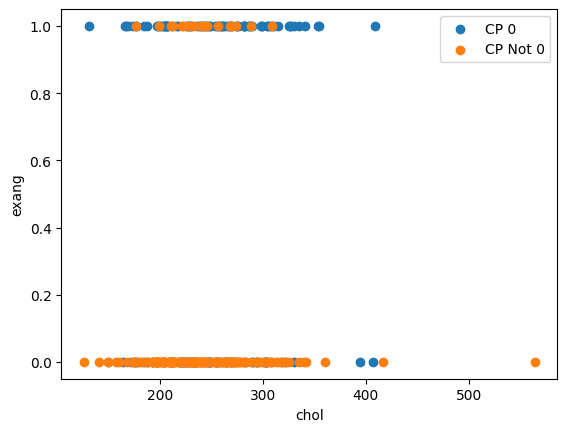

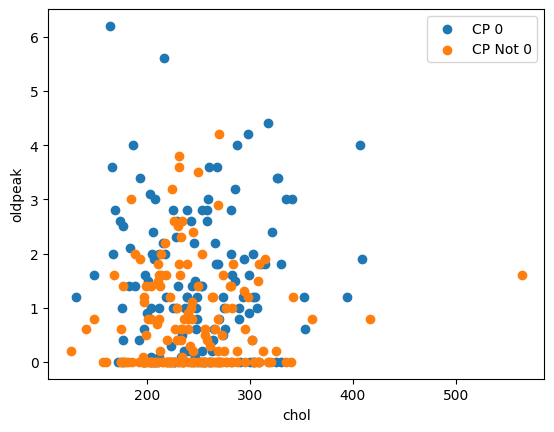

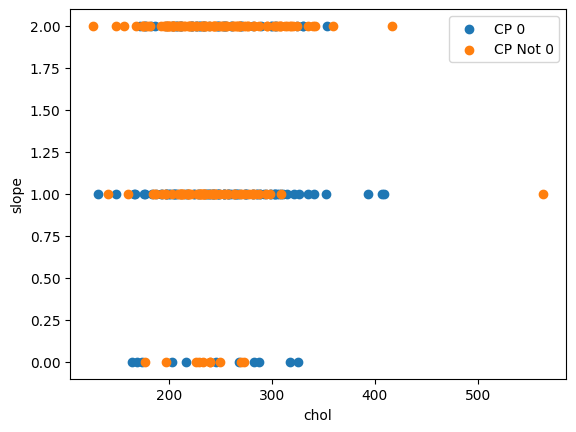

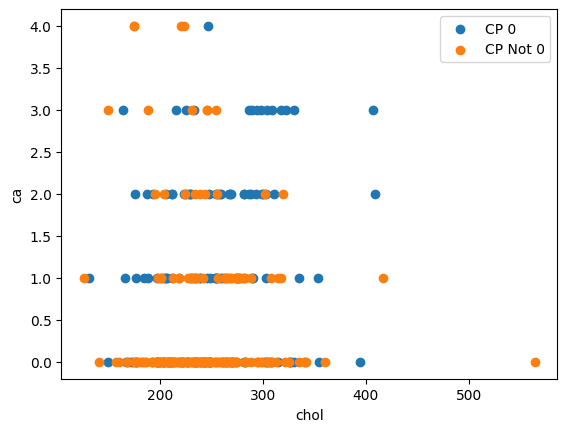

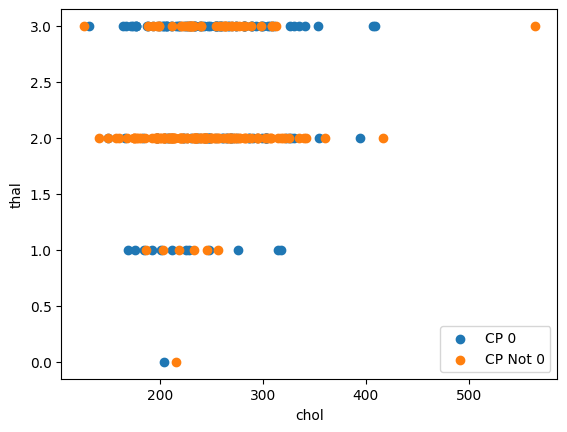

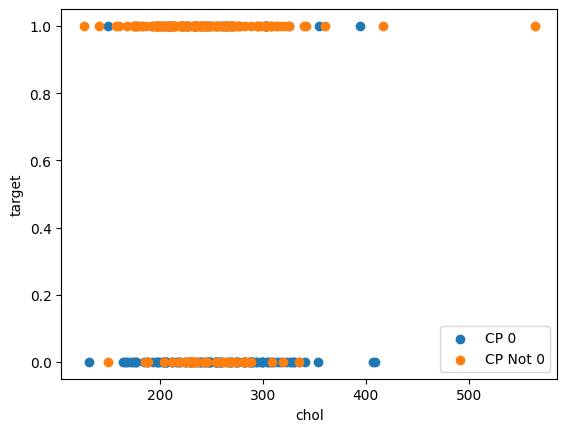

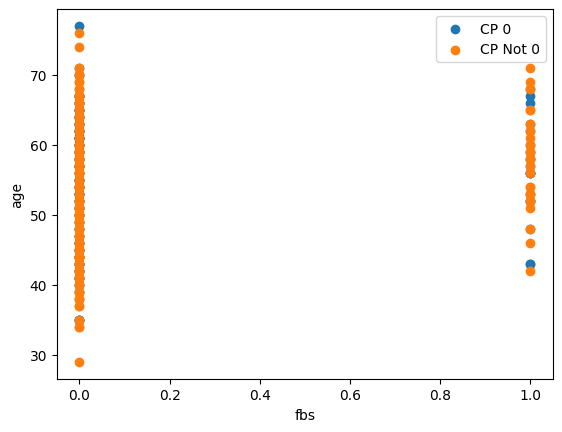

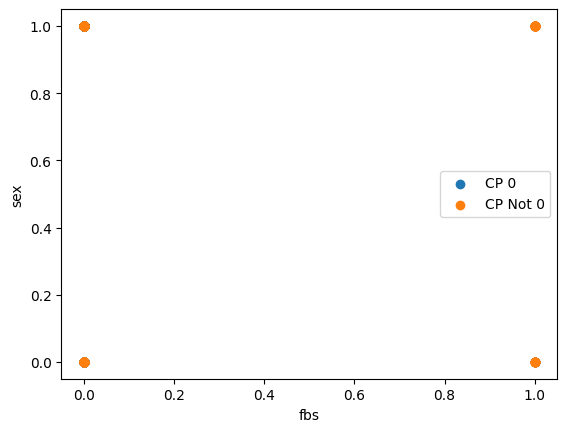

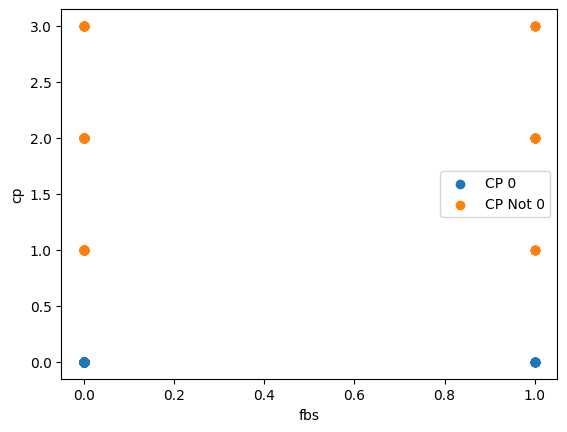

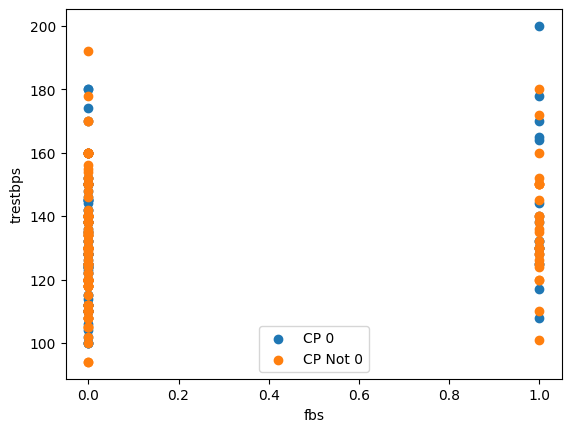

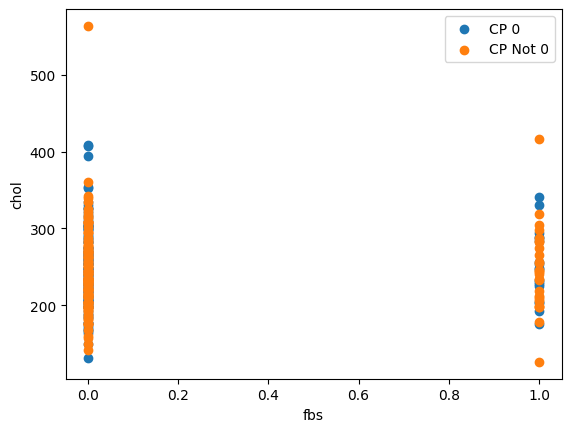

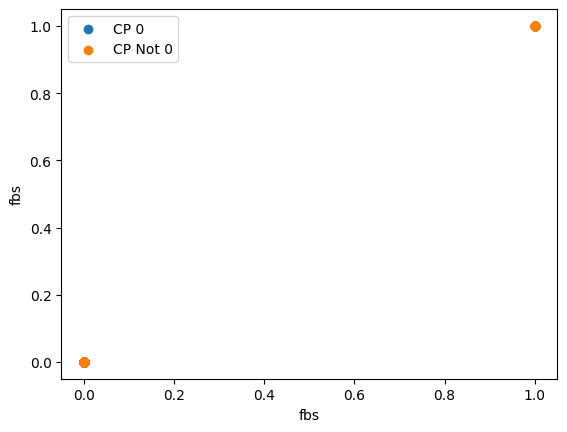

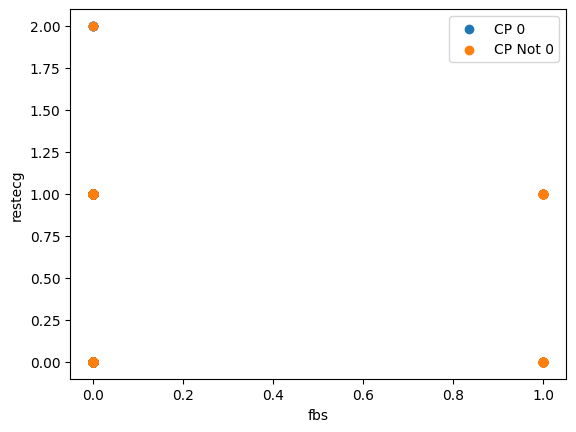

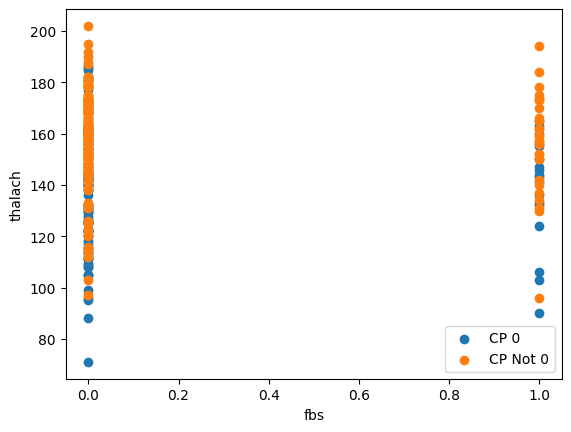

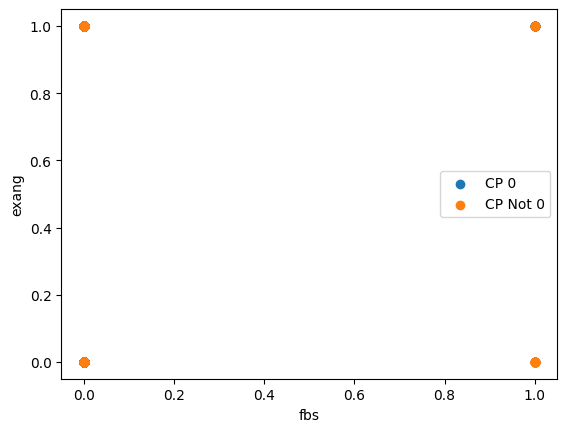

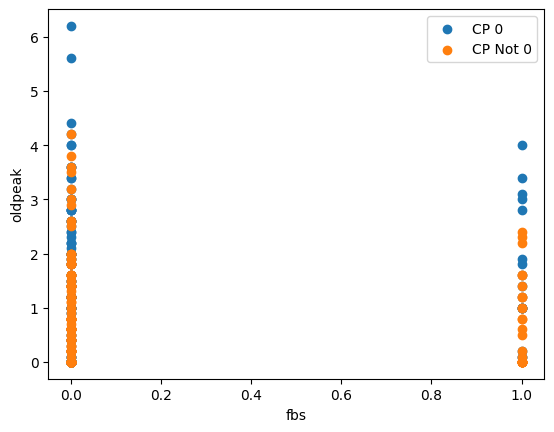

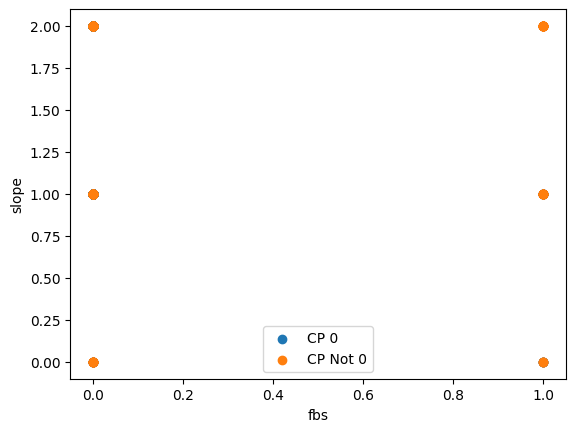

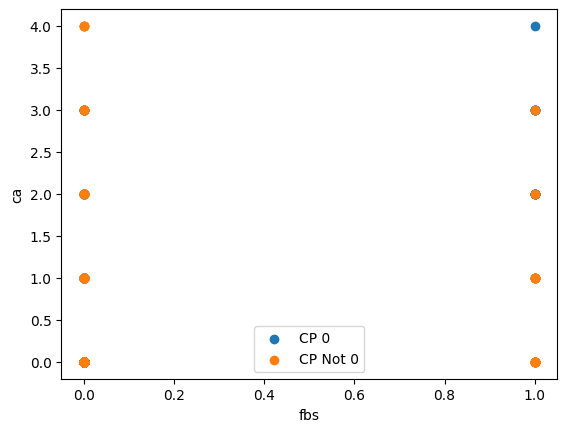

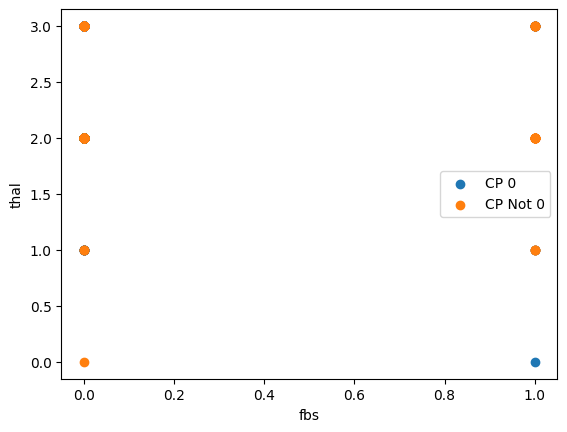

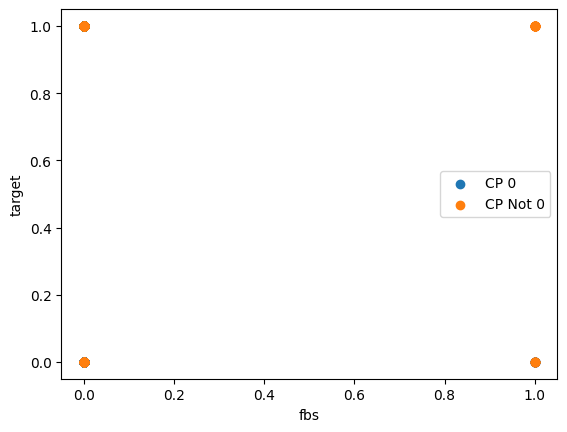

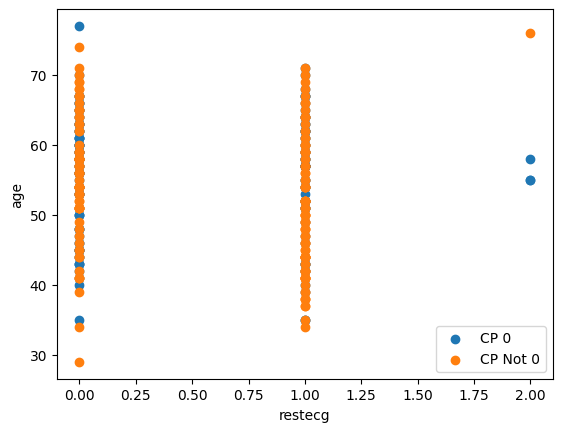

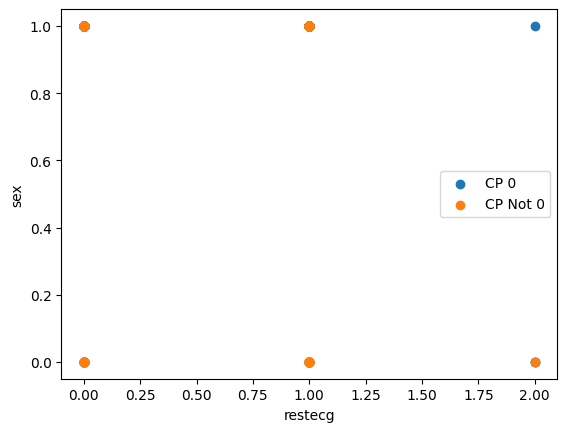

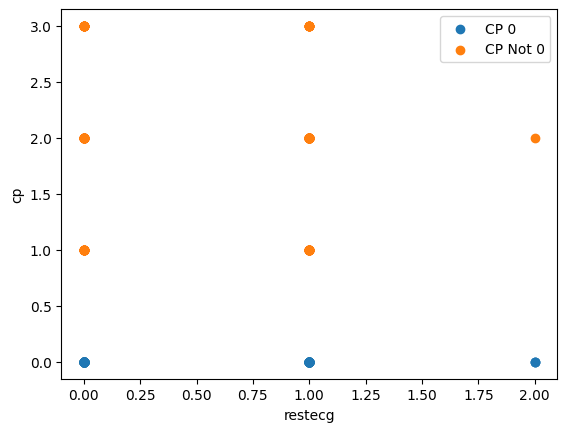

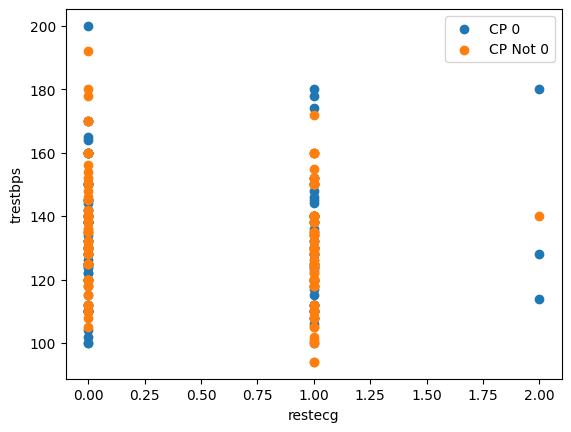

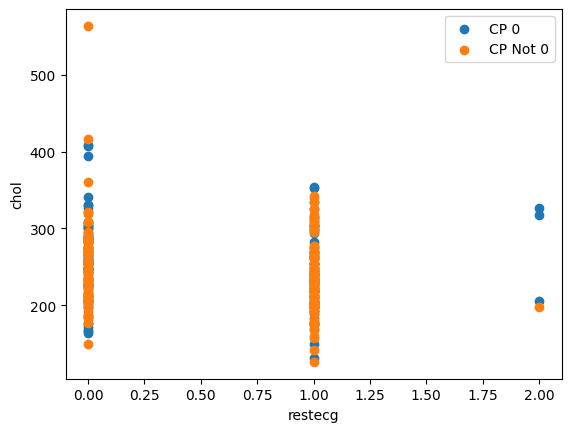

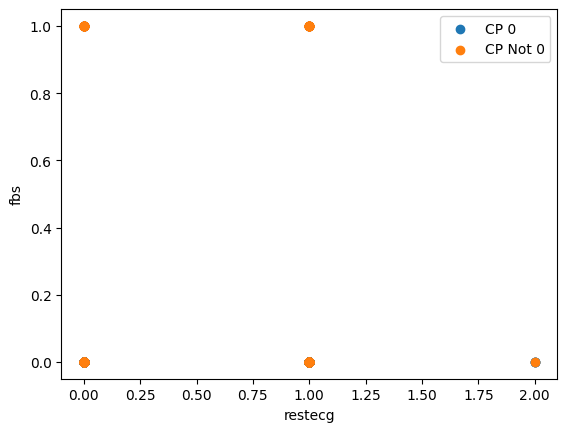

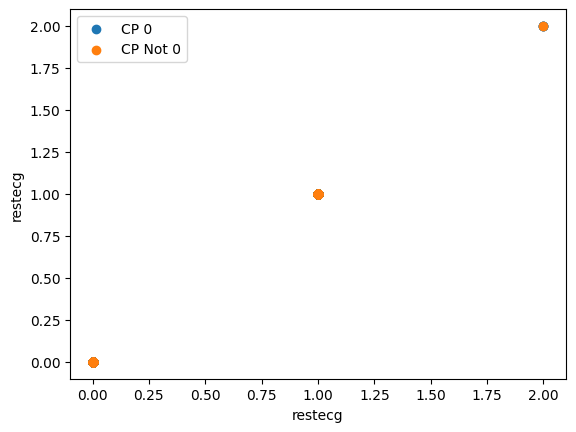

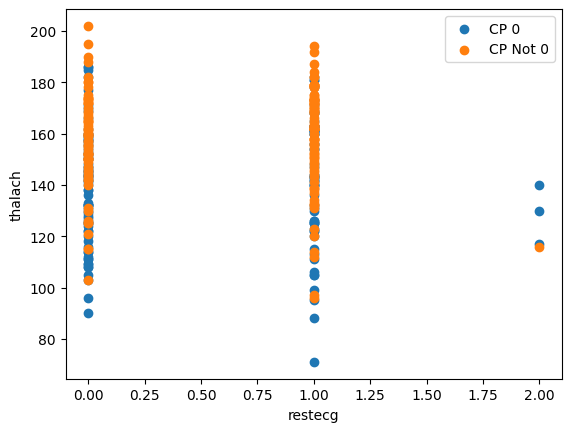

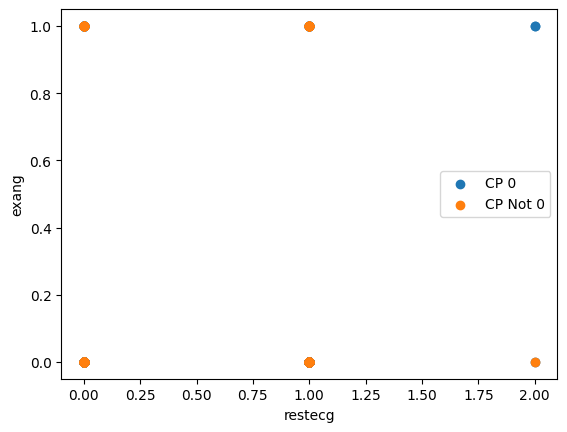

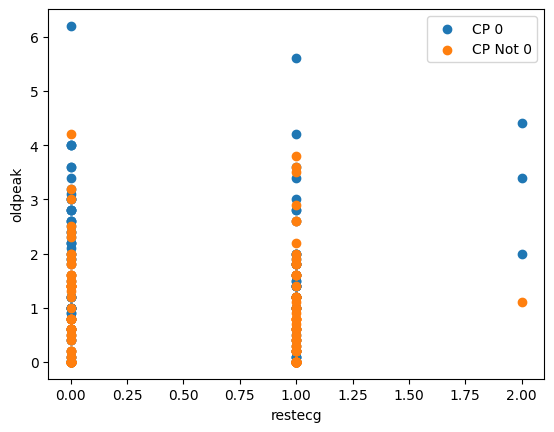

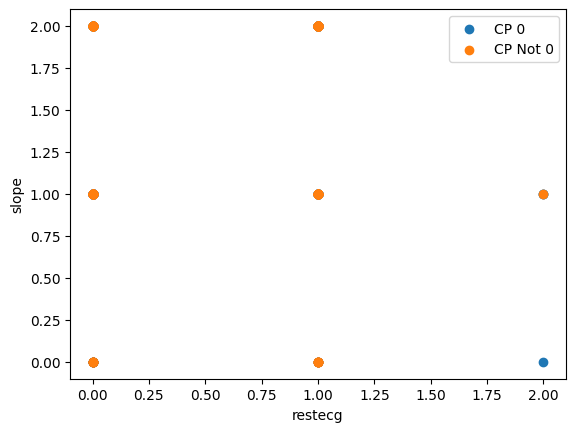

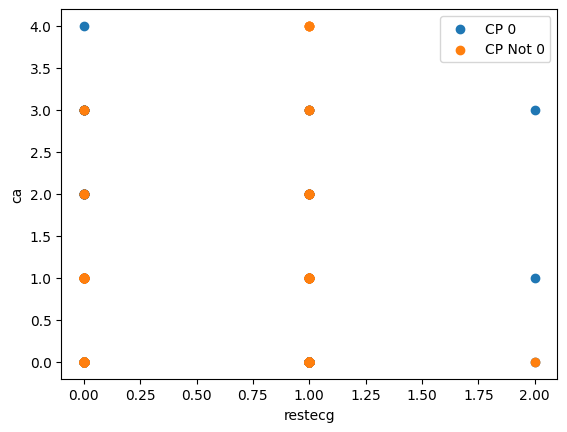

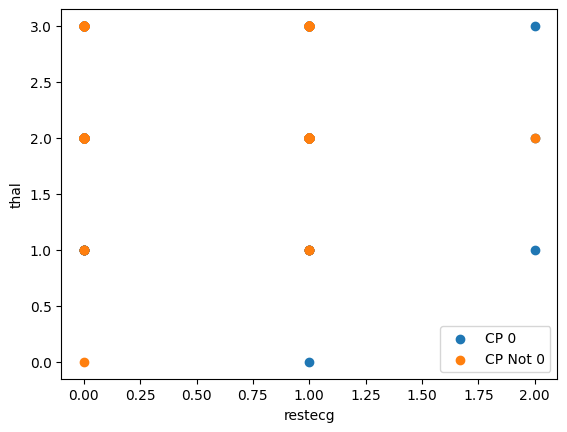

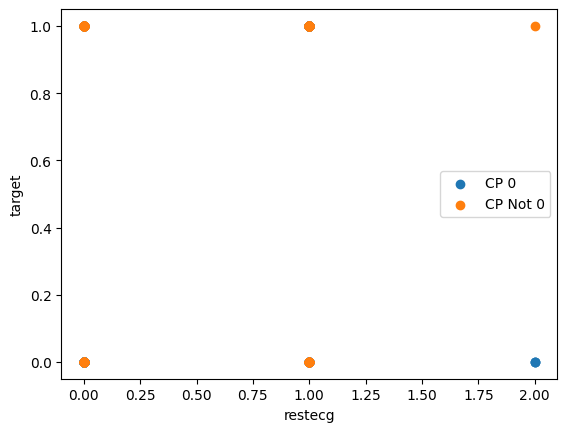

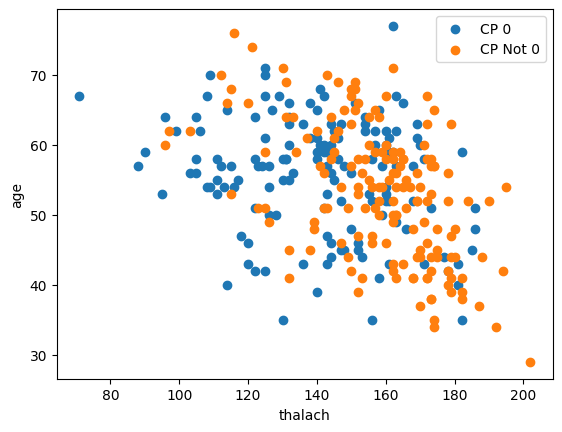

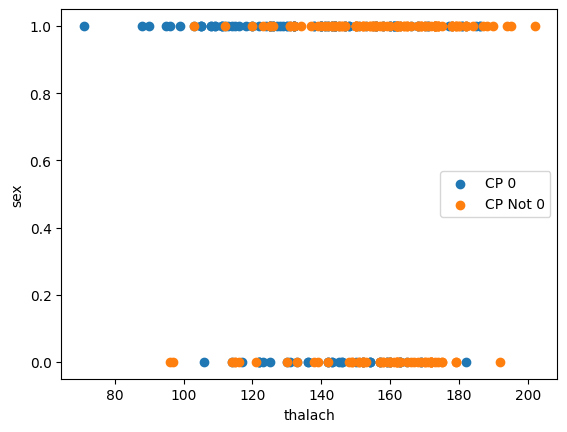

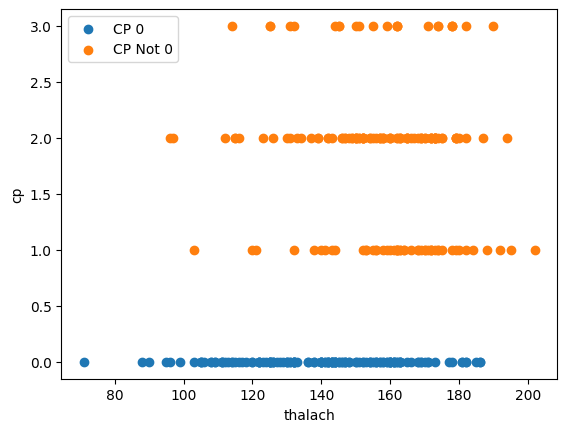

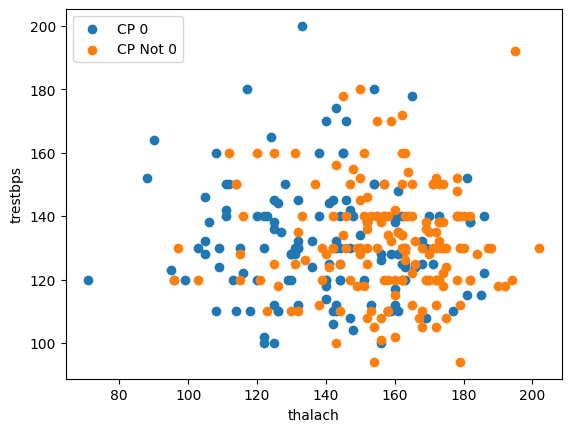

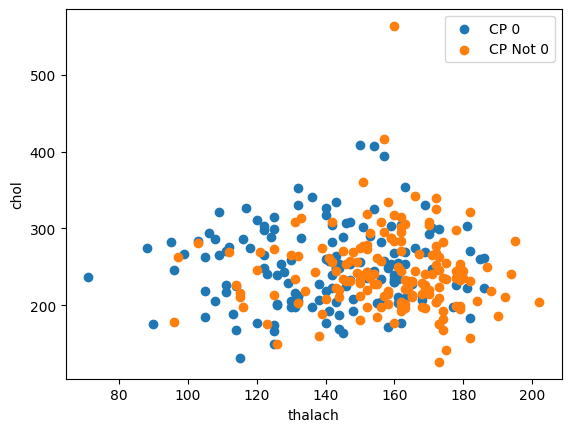

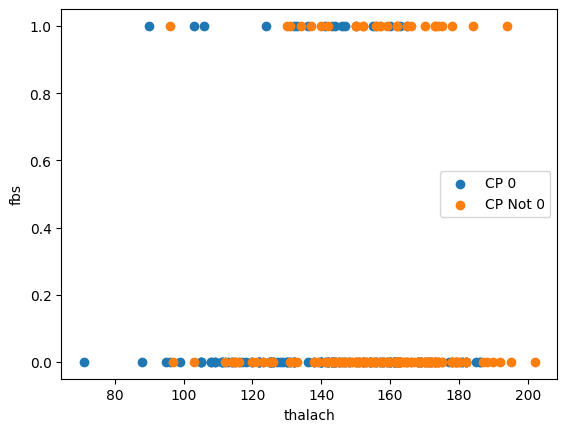

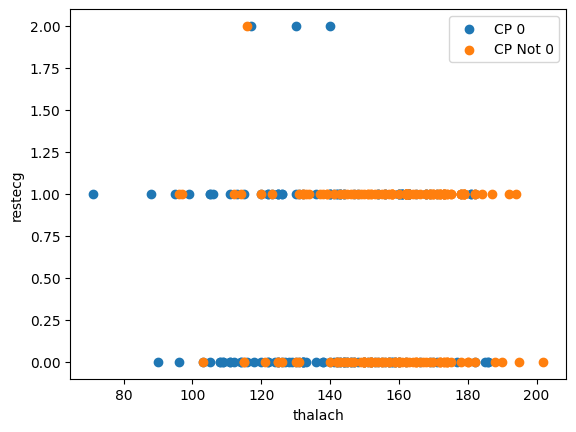

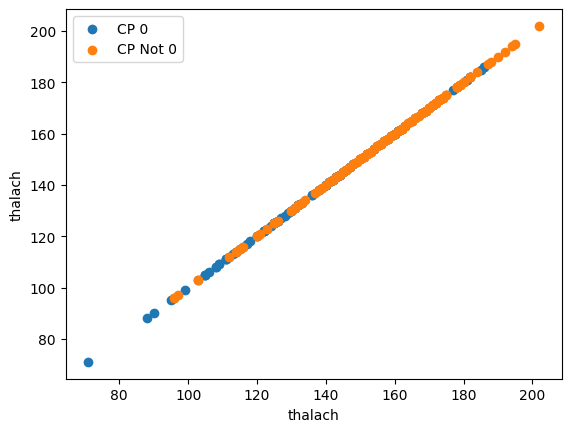

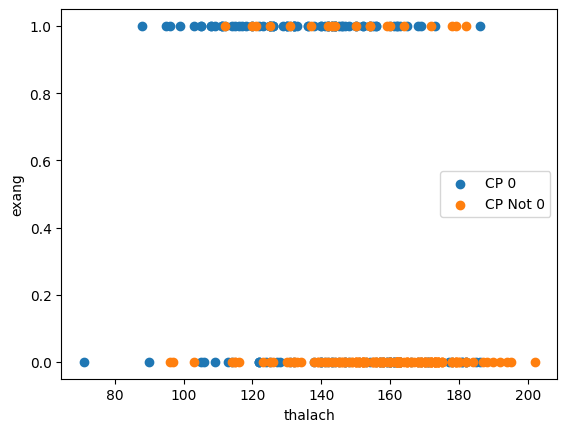

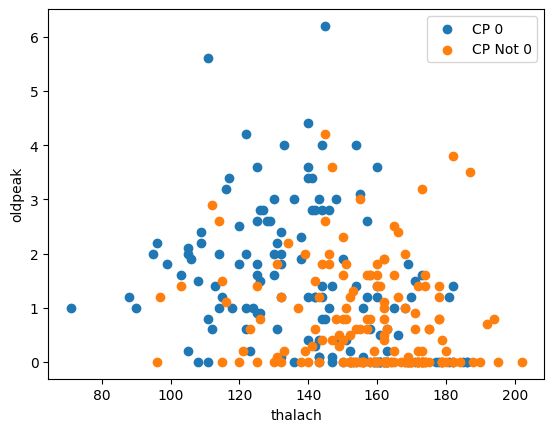

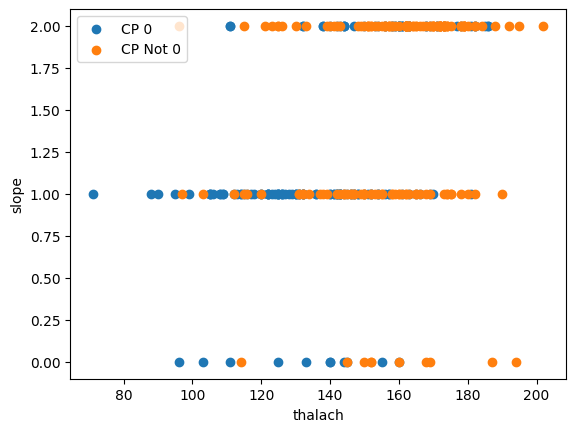

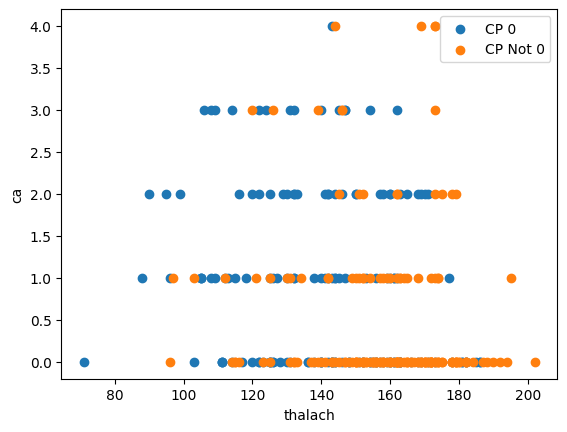

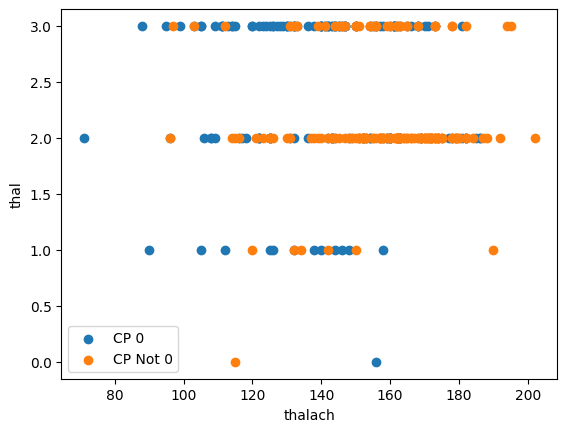

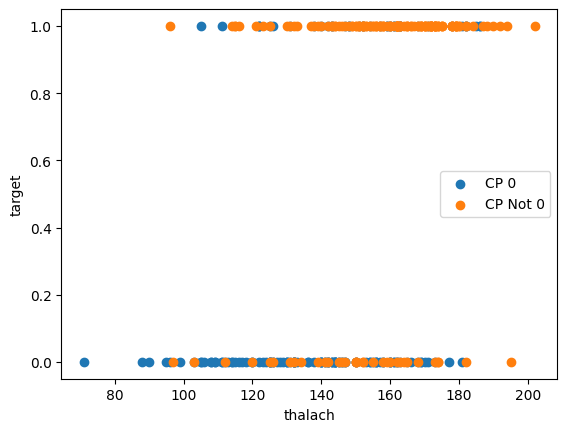

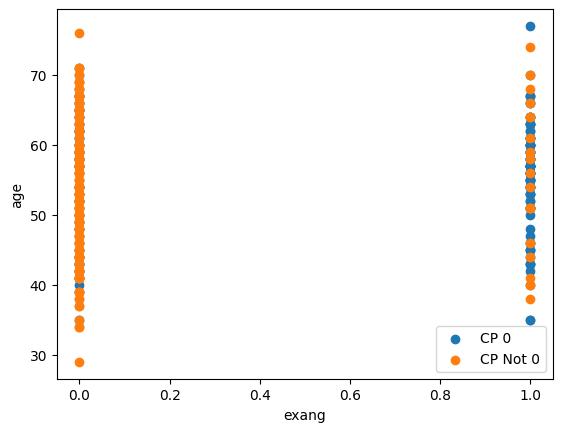

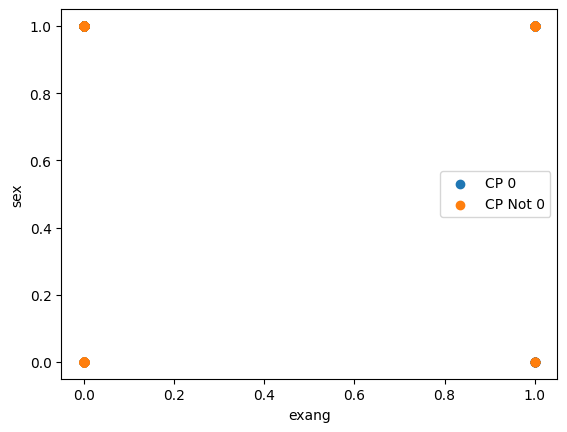

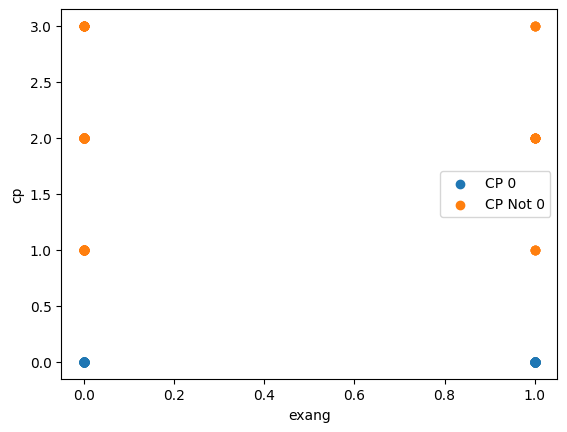

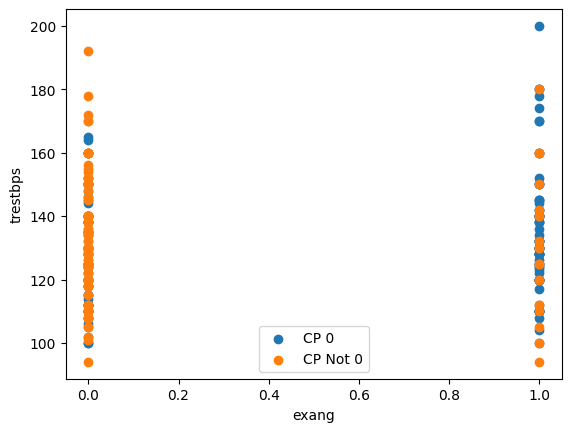

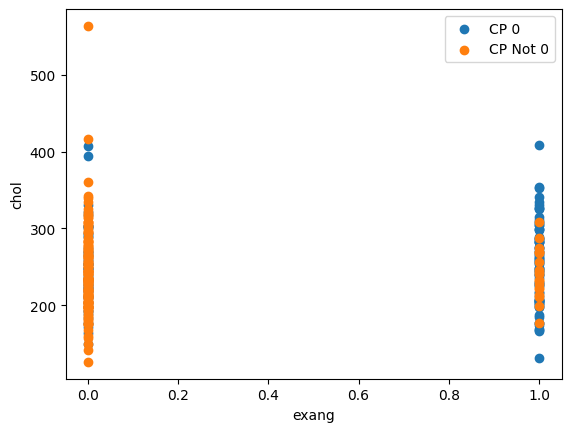

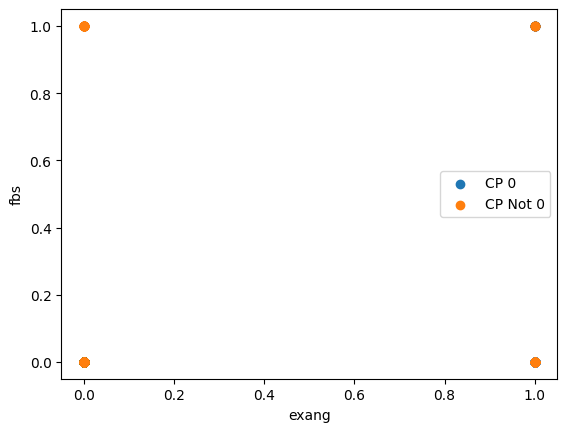

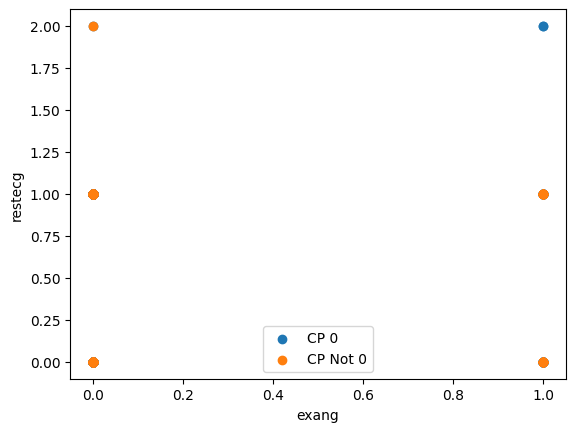

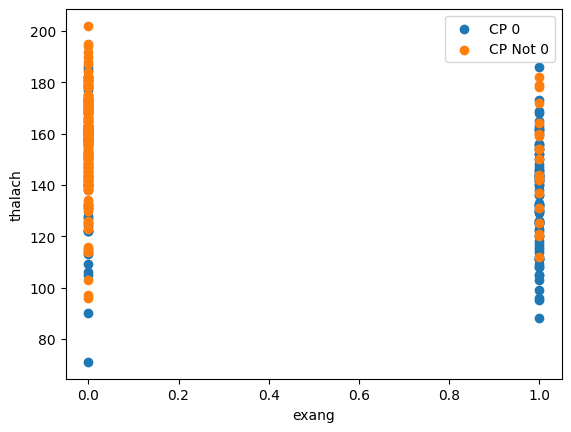

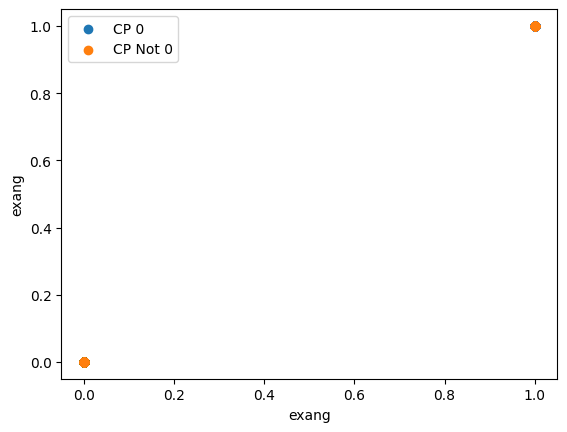

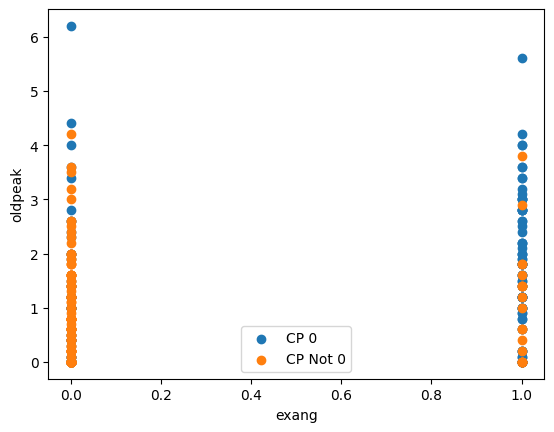

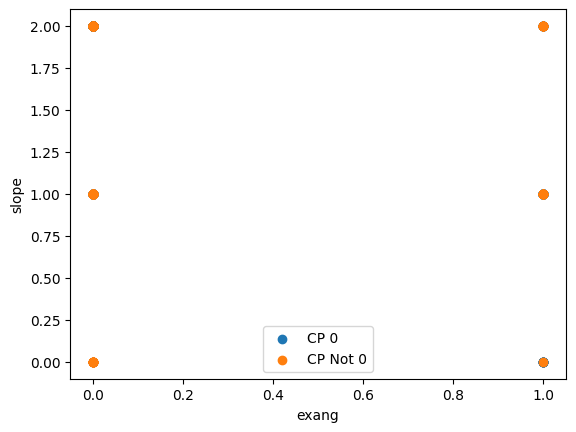

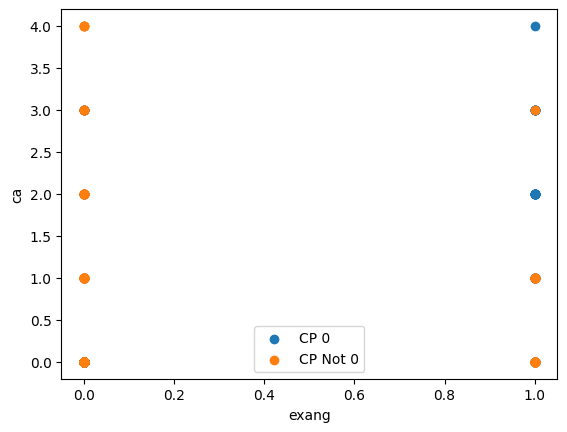

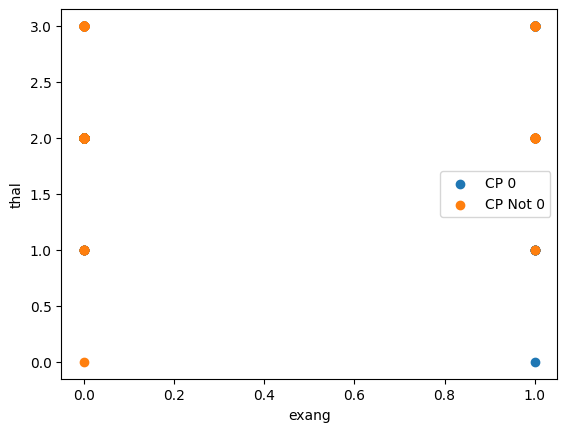

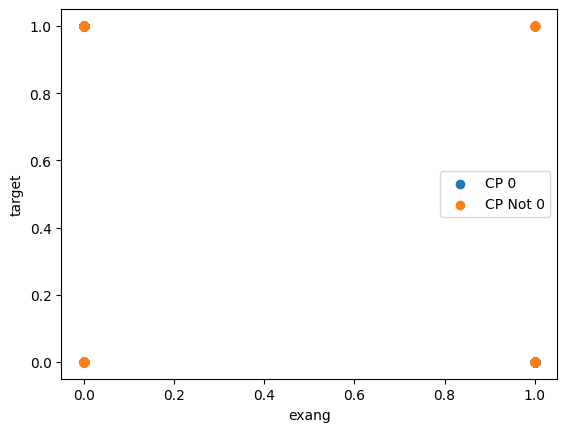

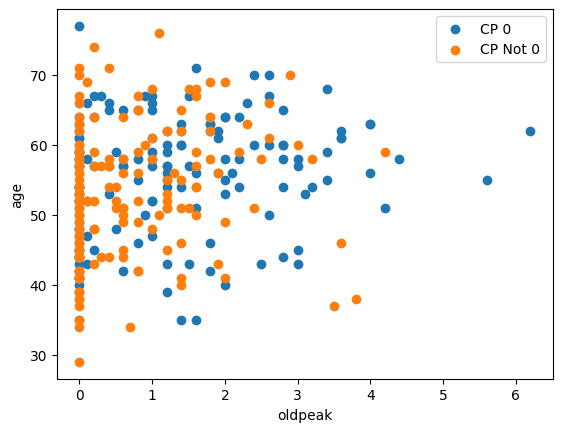

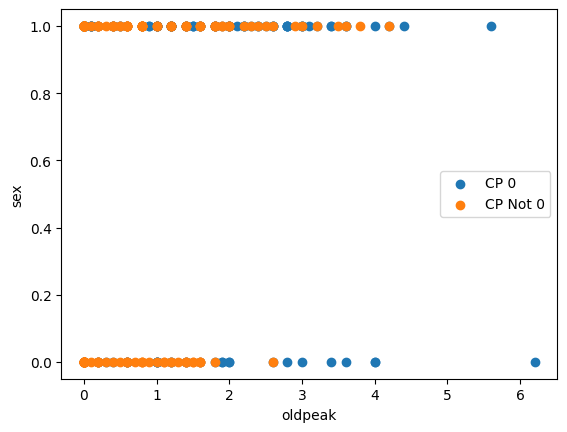

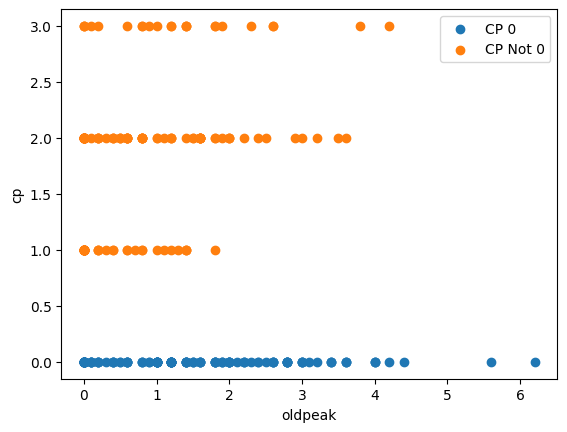

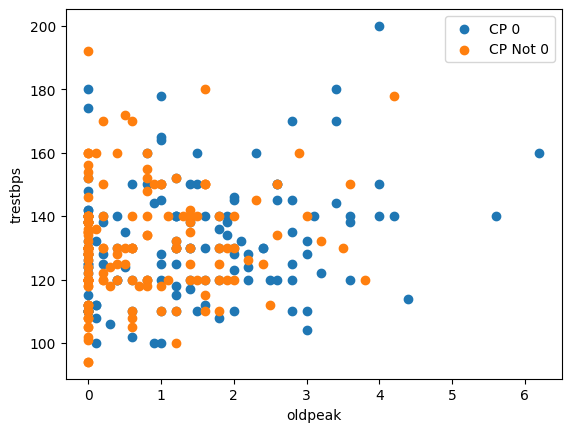

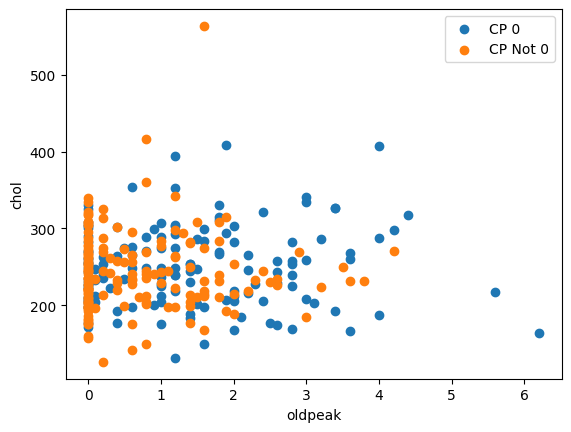

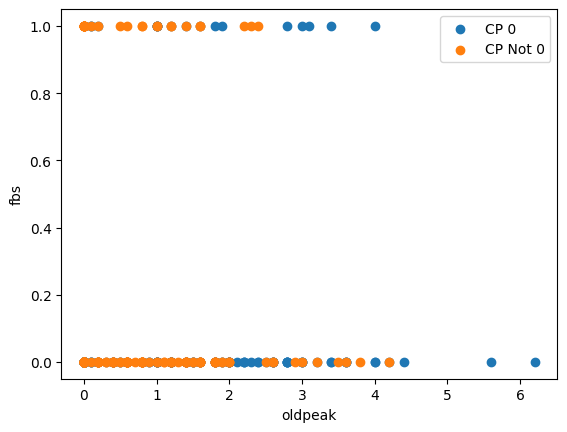

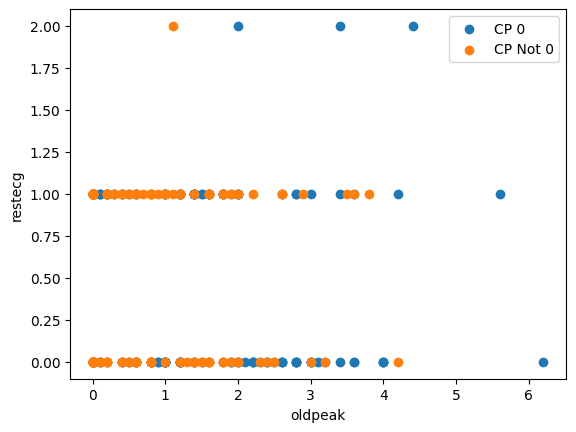

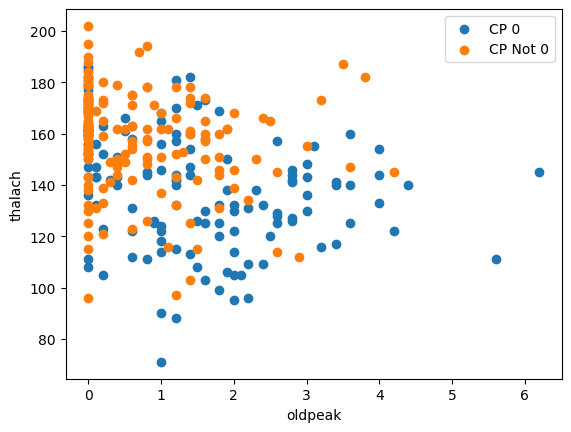

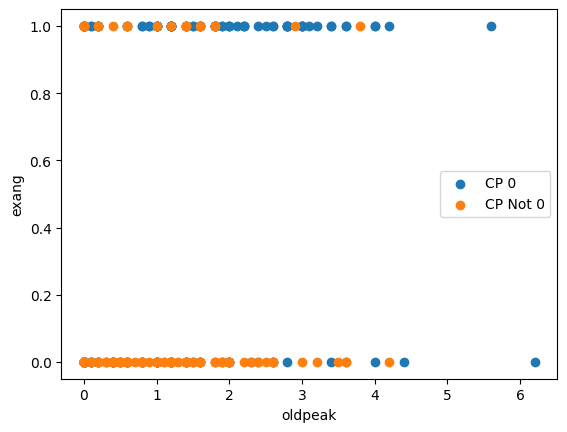

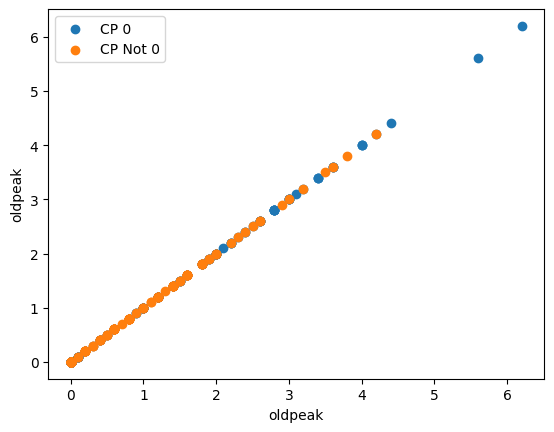

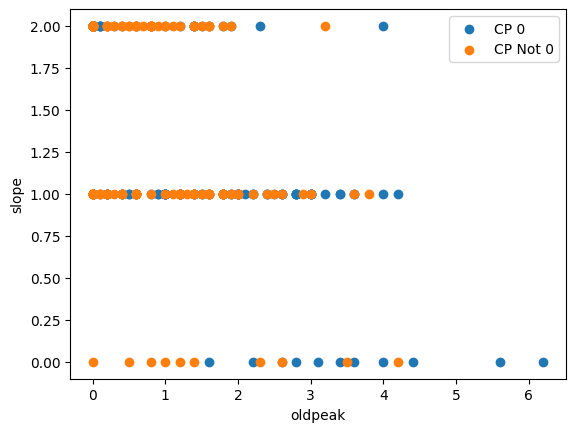

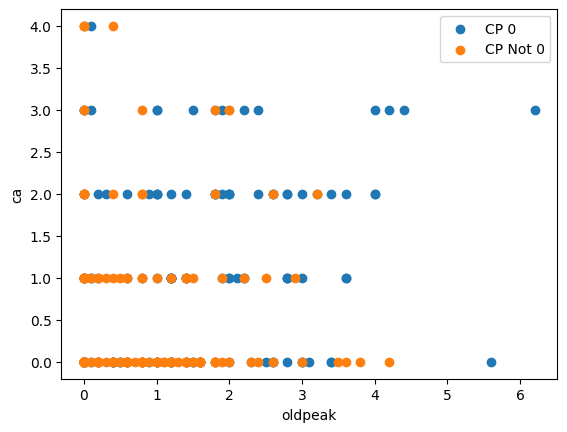

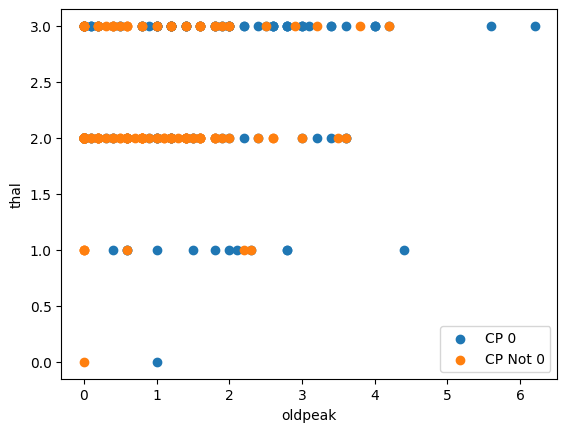

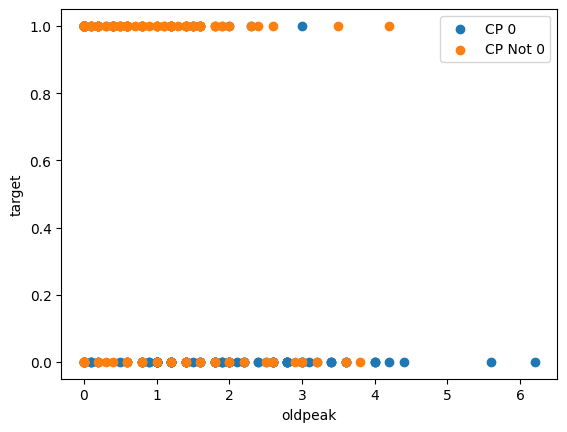

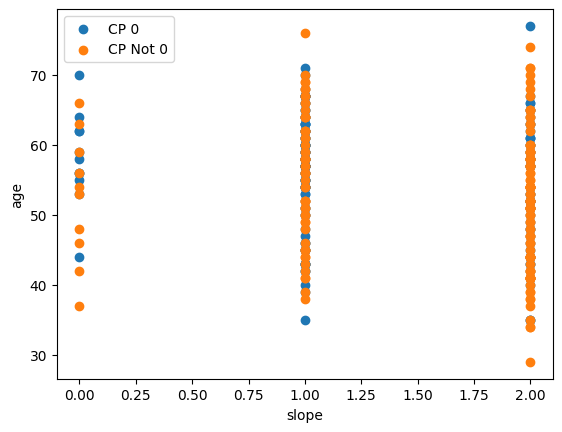

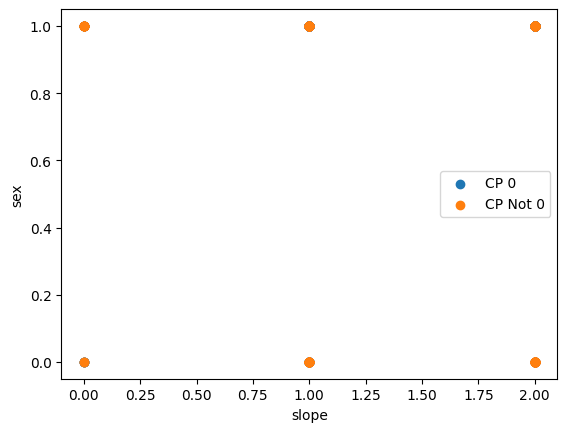

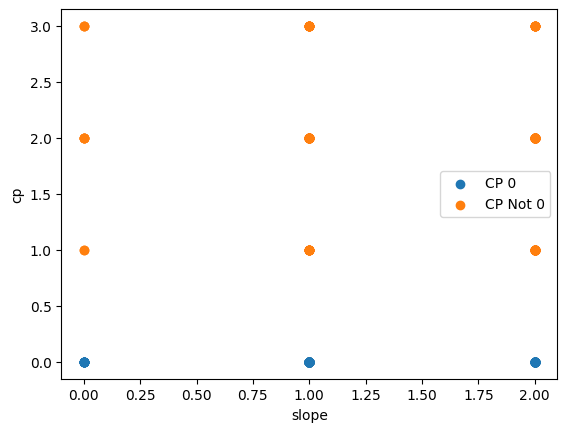

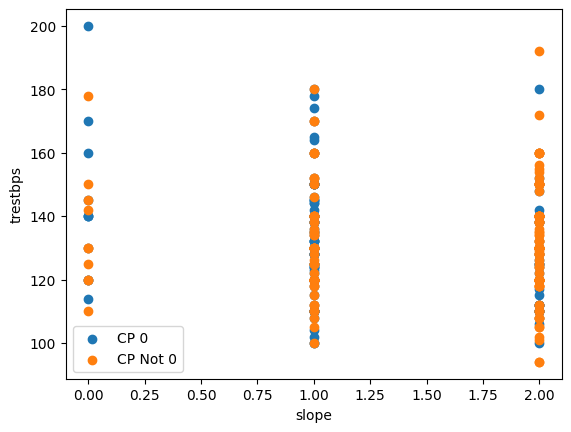

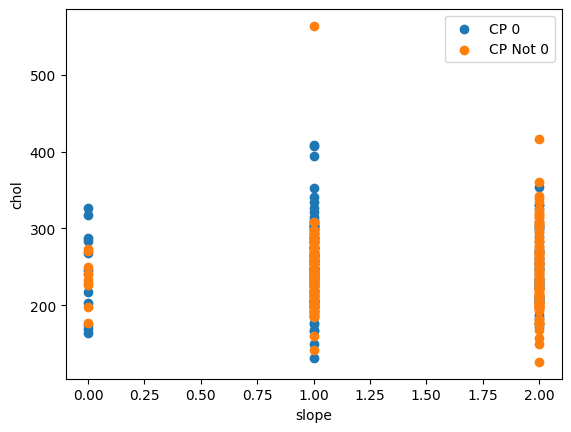

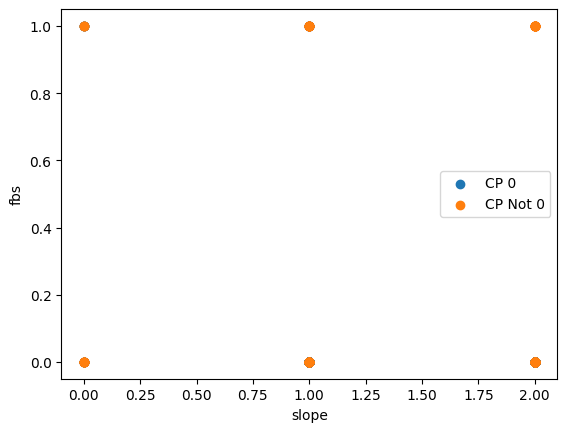

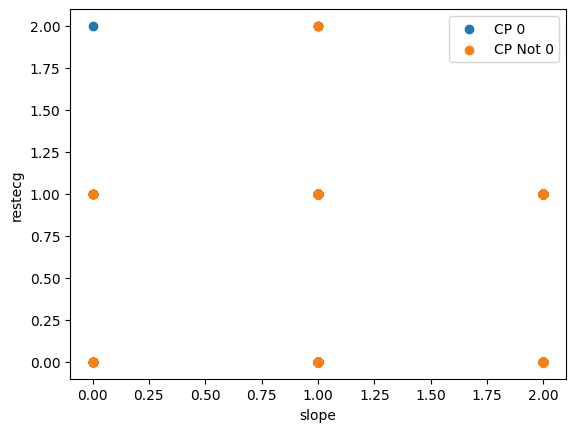

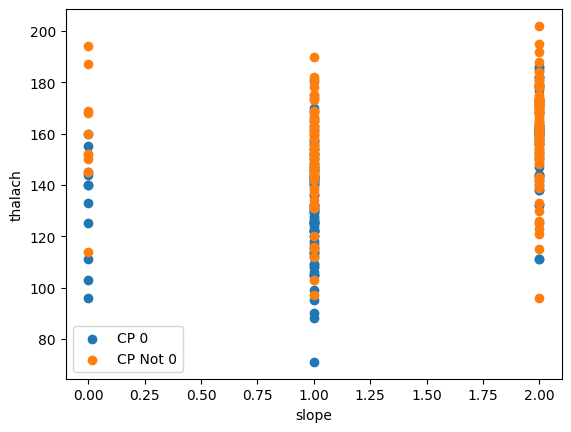

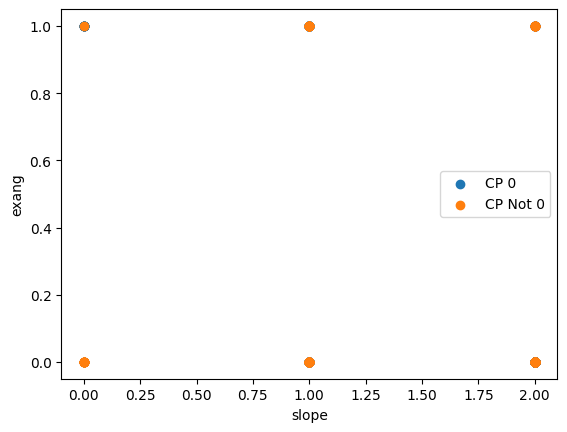

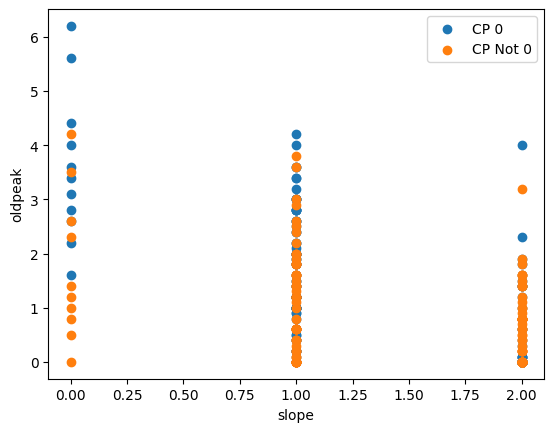

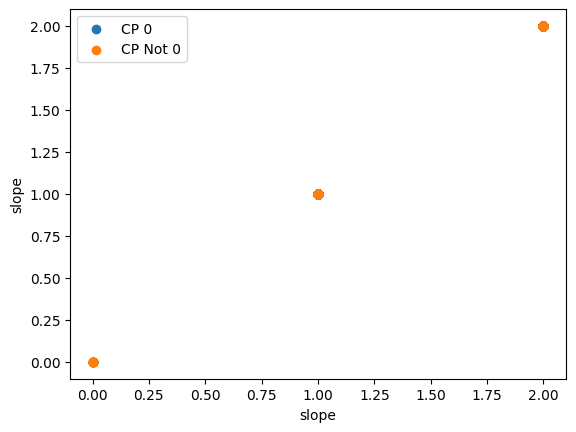

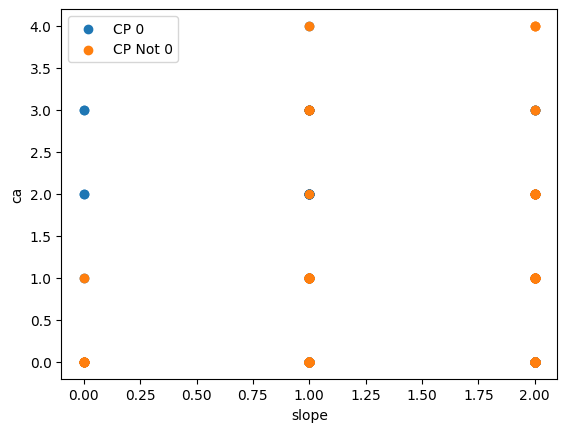

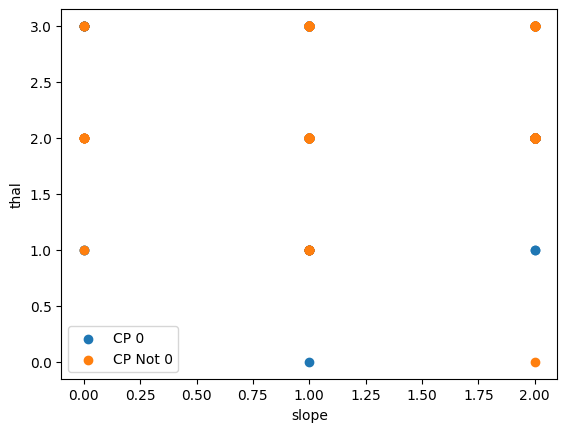

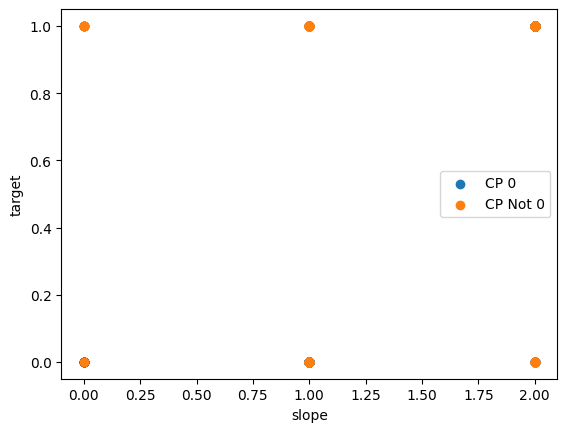

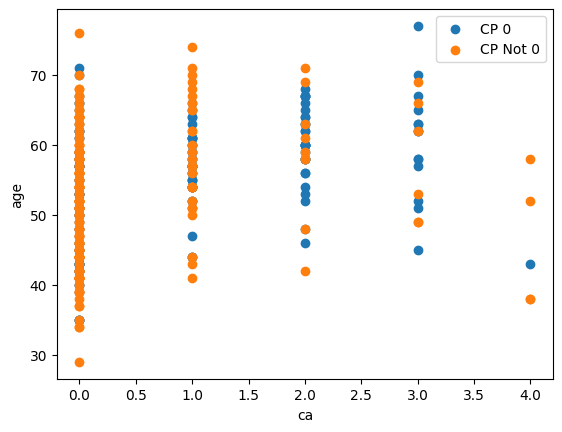

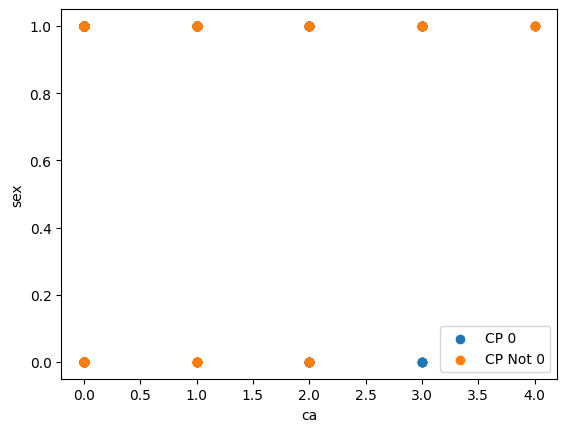

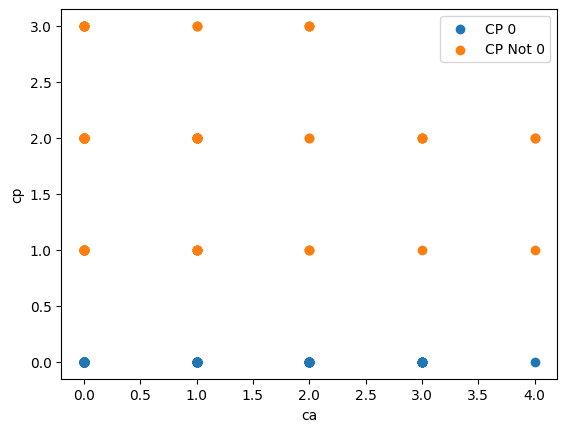

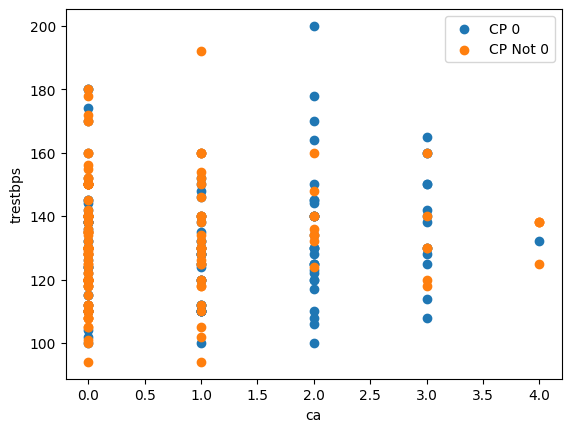

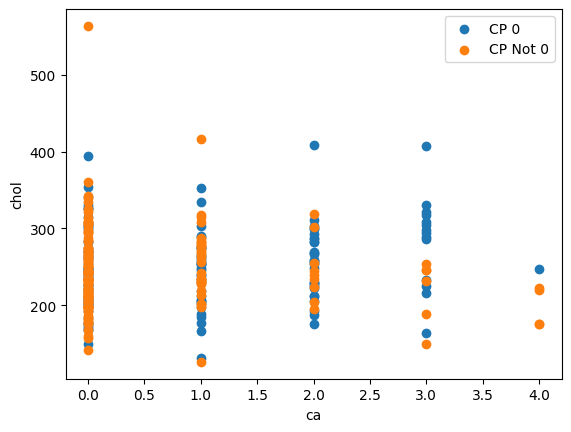

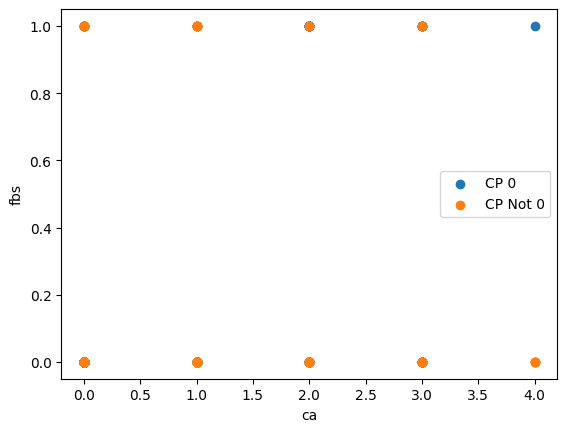

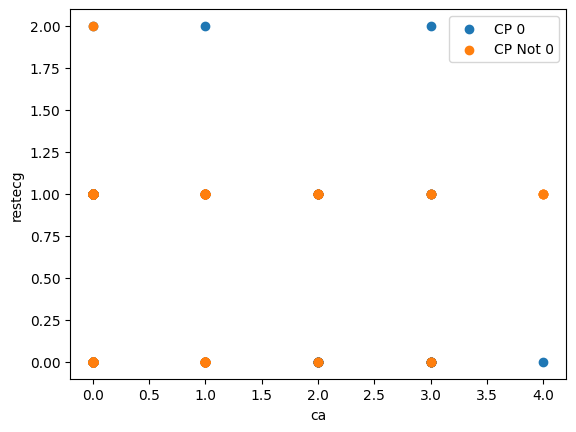

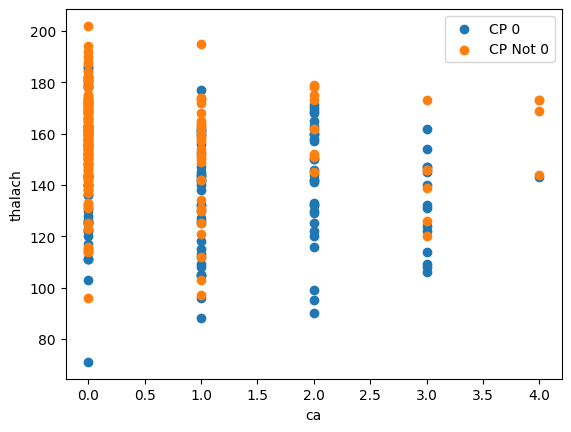

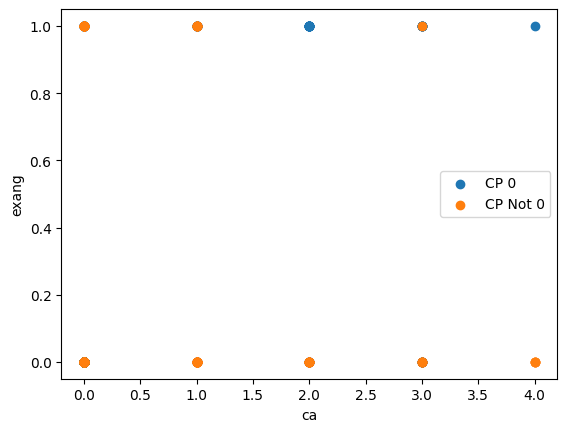

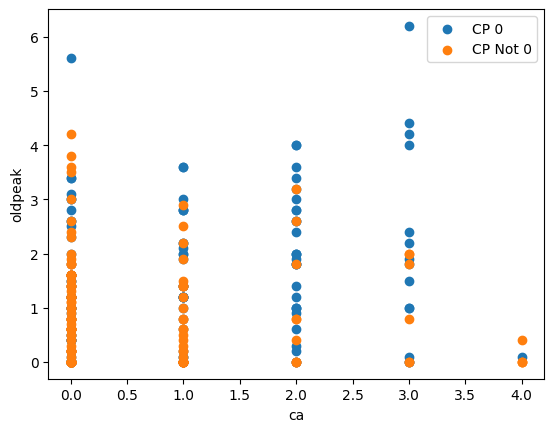

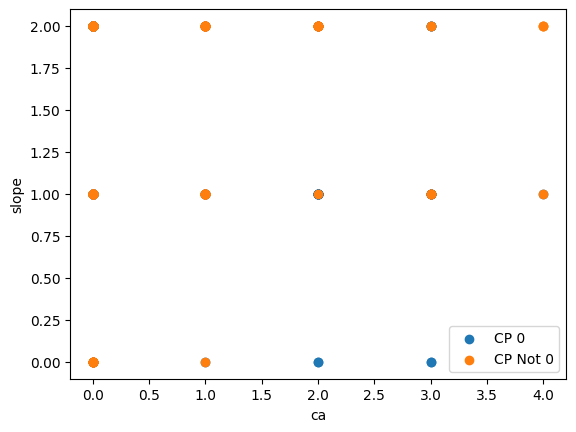

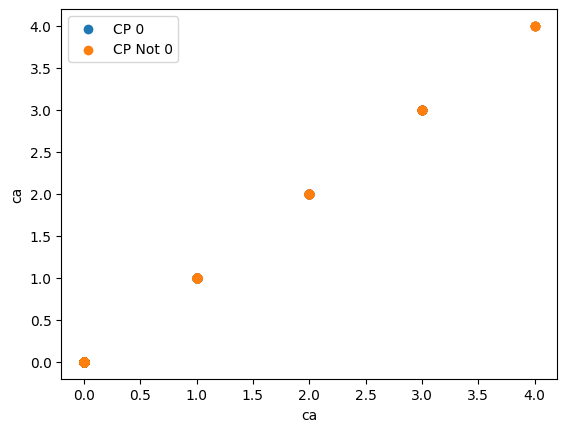

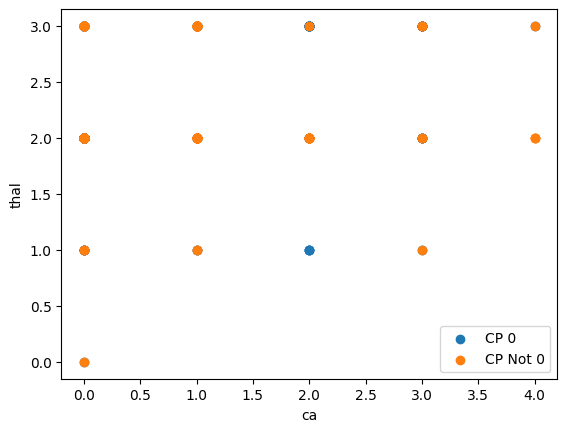

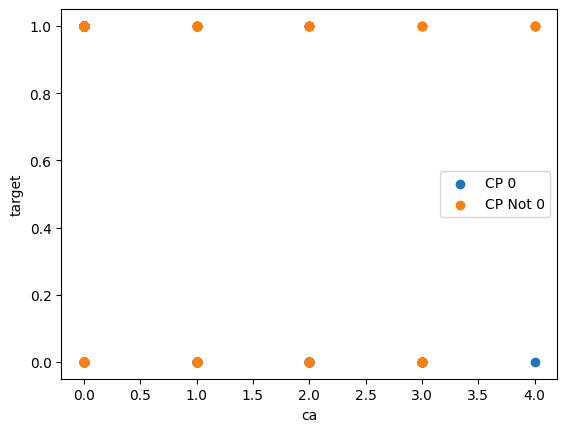

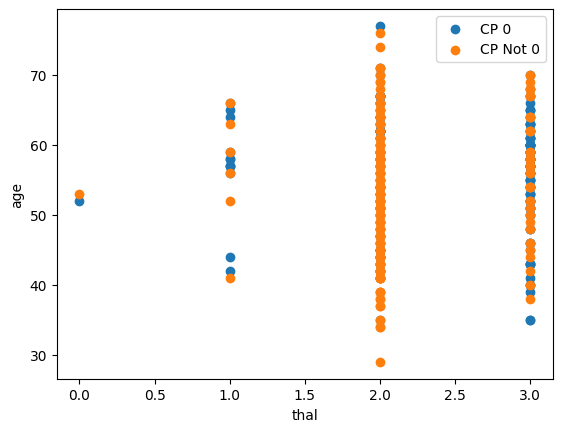

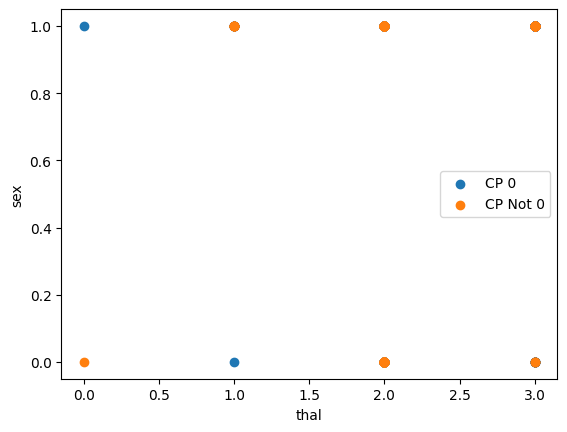

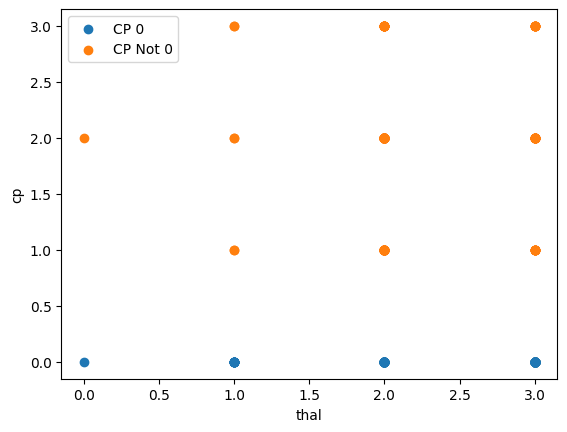

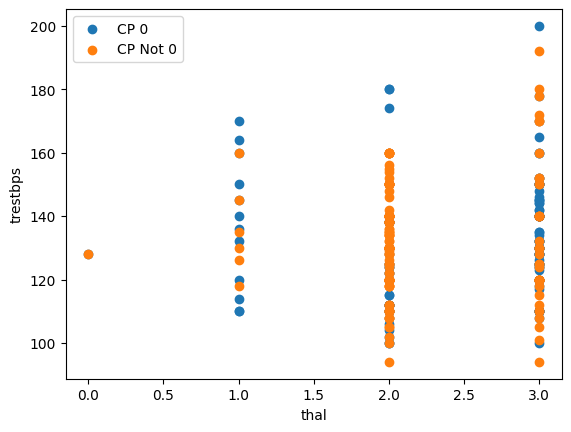

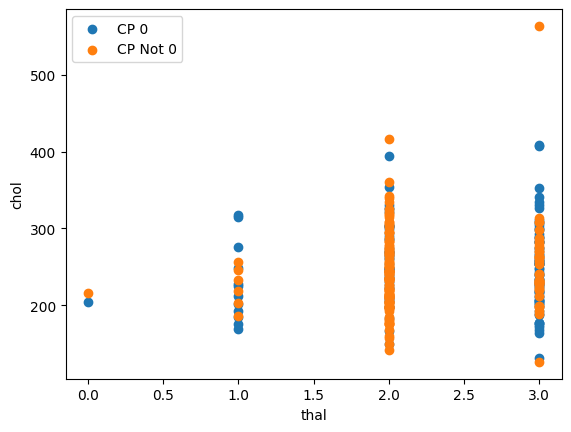

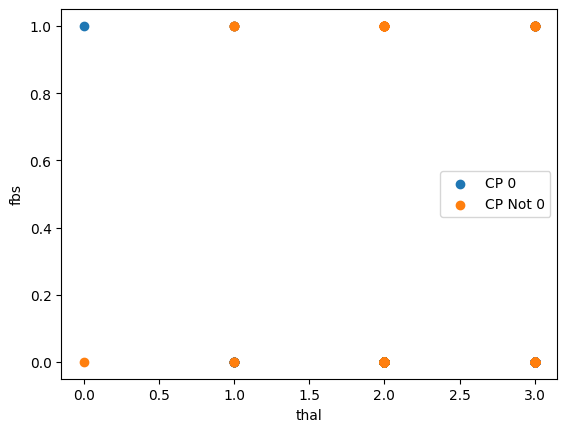

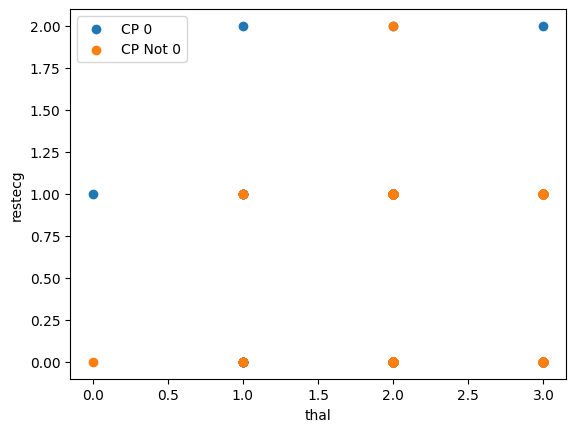

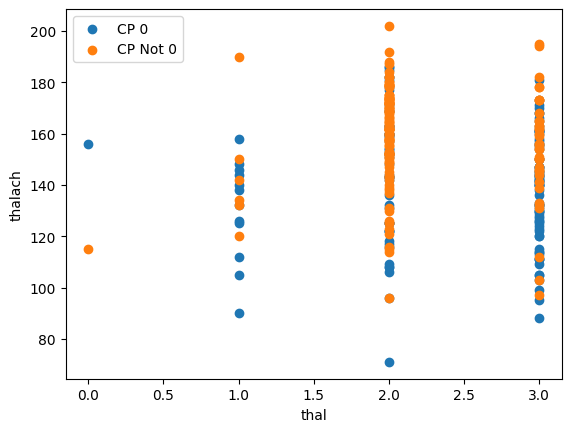

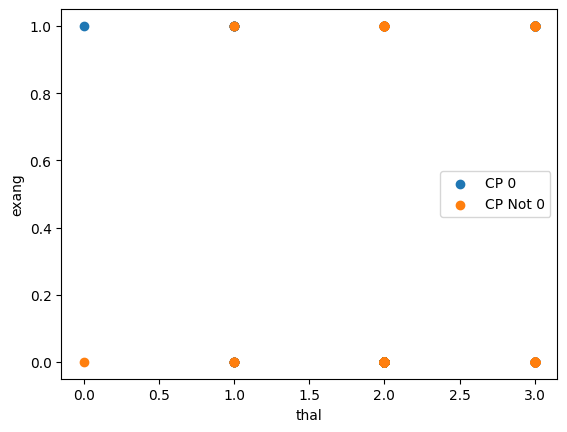

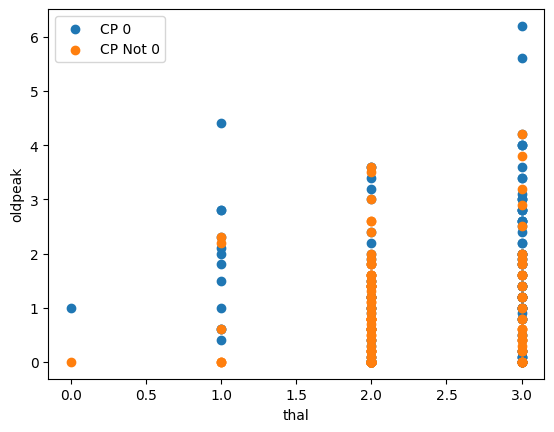

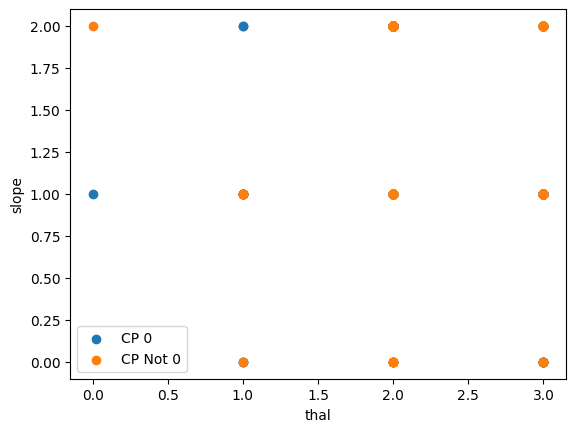

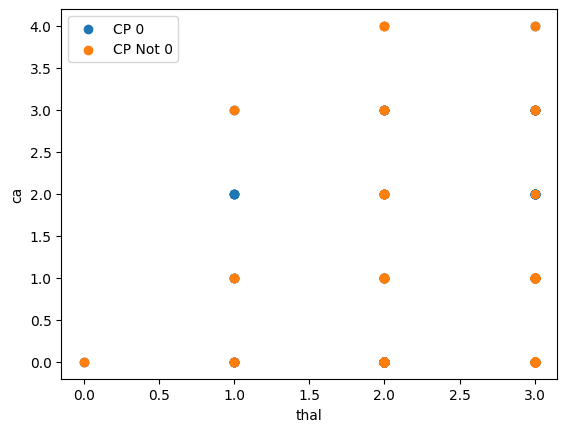

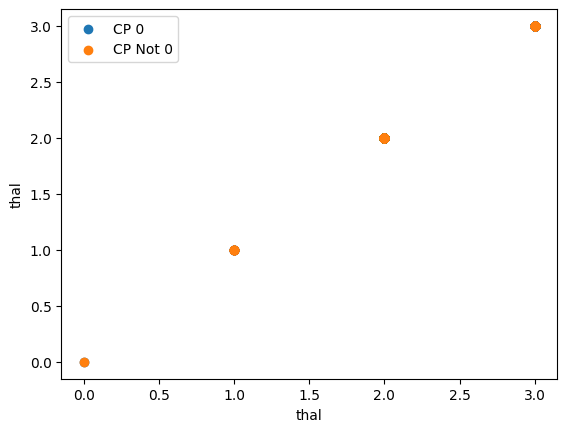

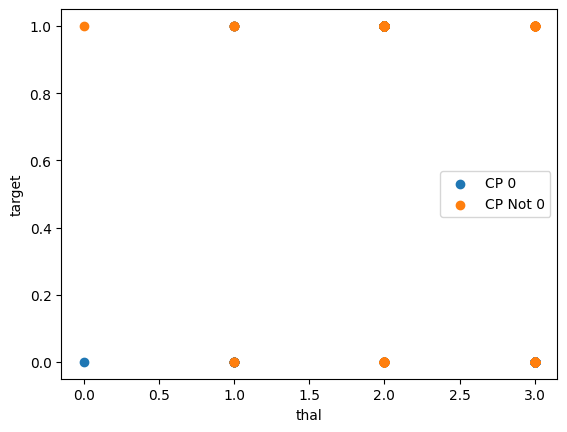

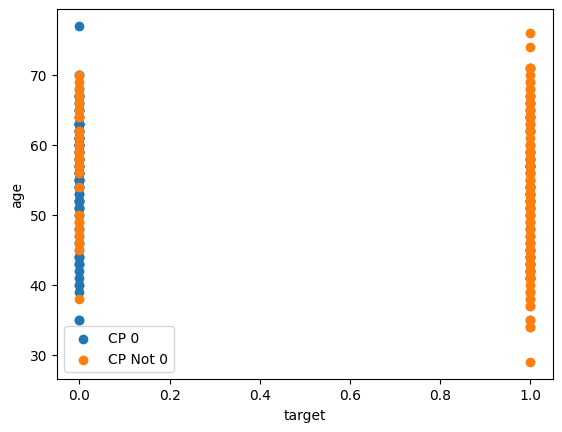

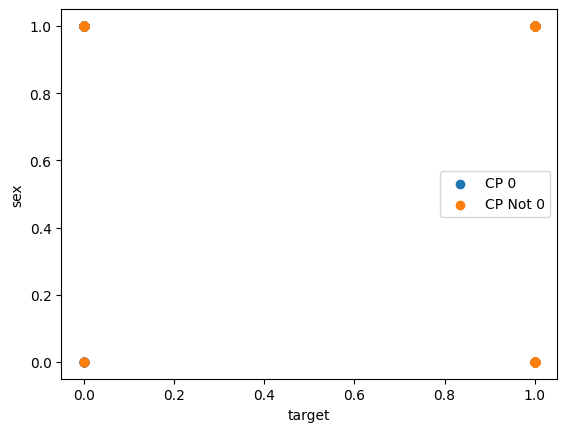

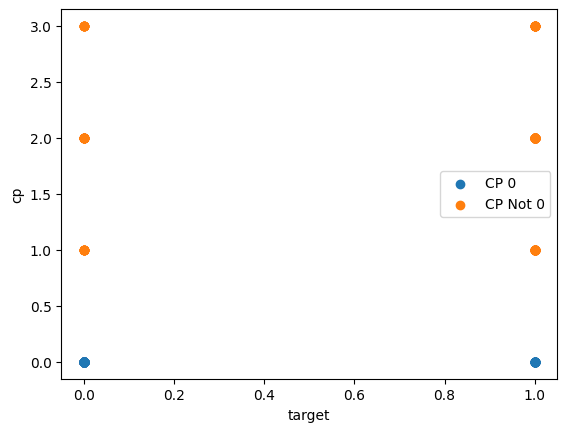

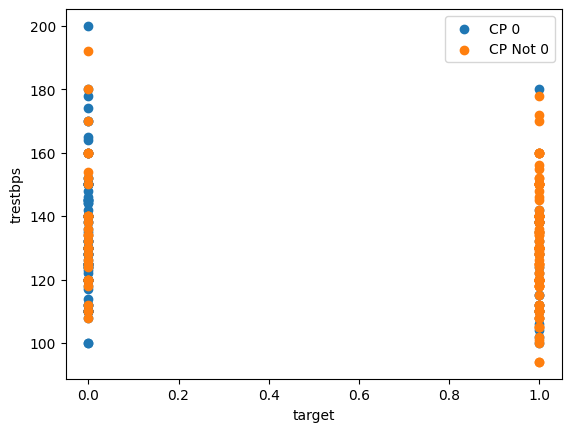

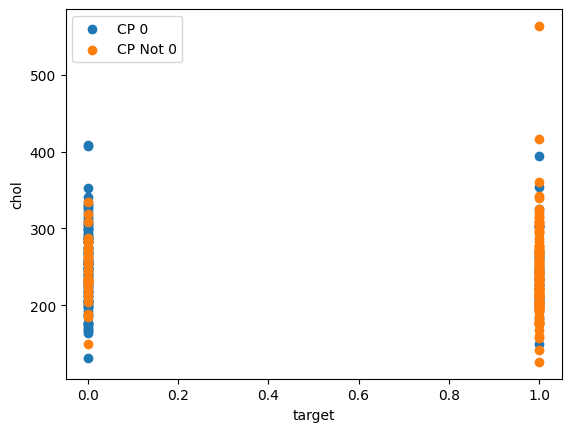

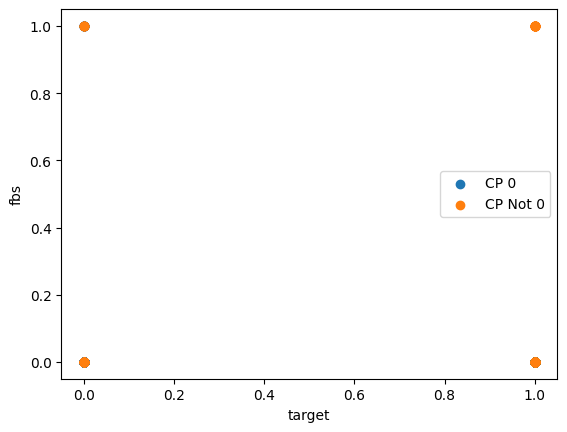

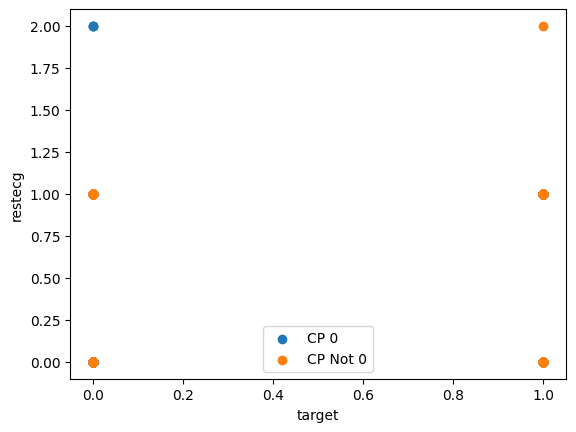

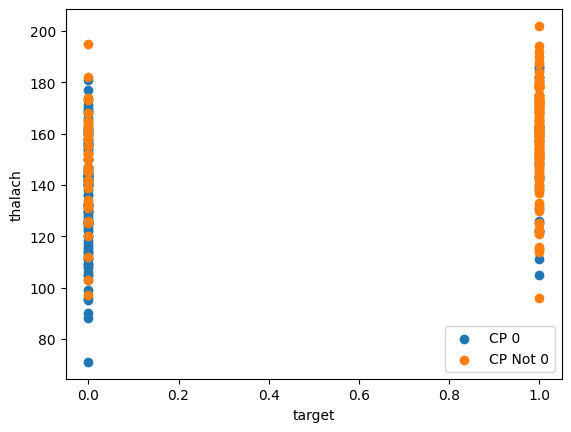

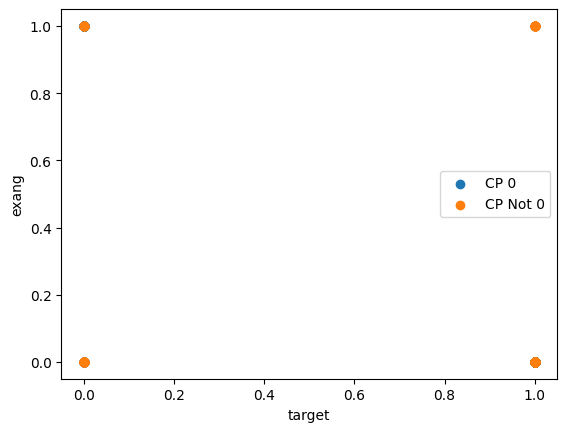

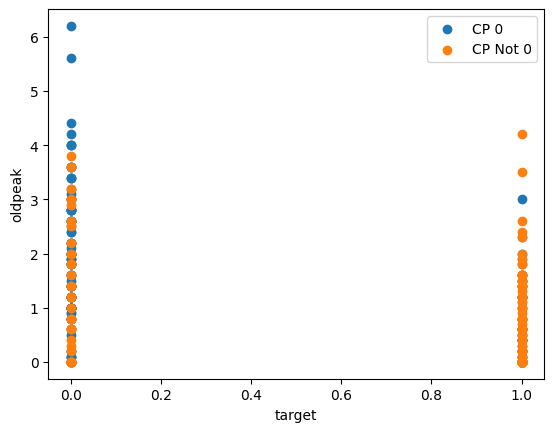

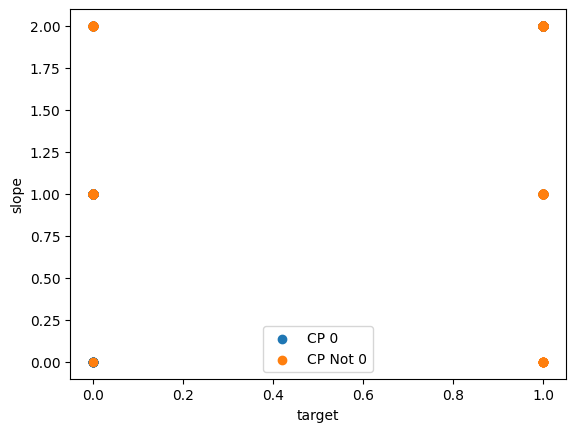

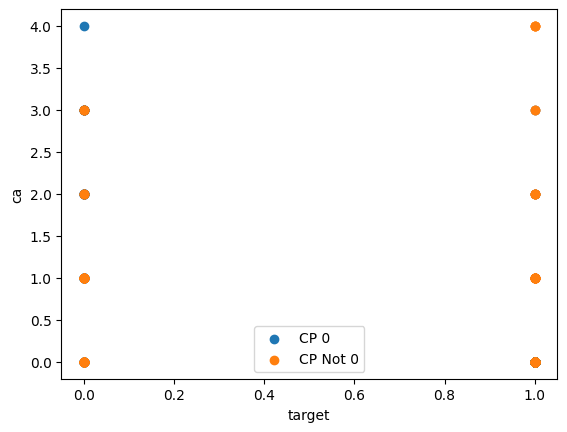

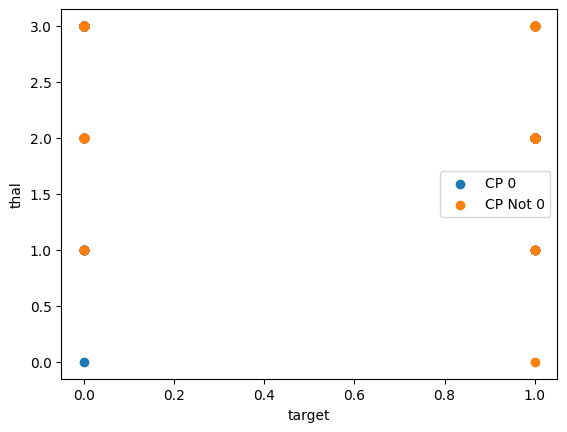

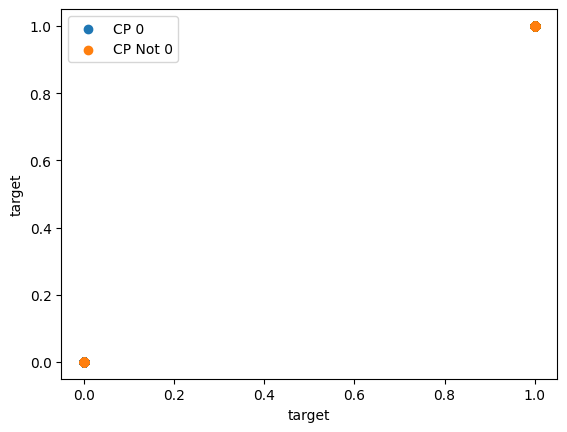

In [39]:
for x_var_name in df.columns:
    for y_var_name in df.columns:
        compare_scatter(df,x_var_name,y_var_name,selection_dict)
        plt.show()


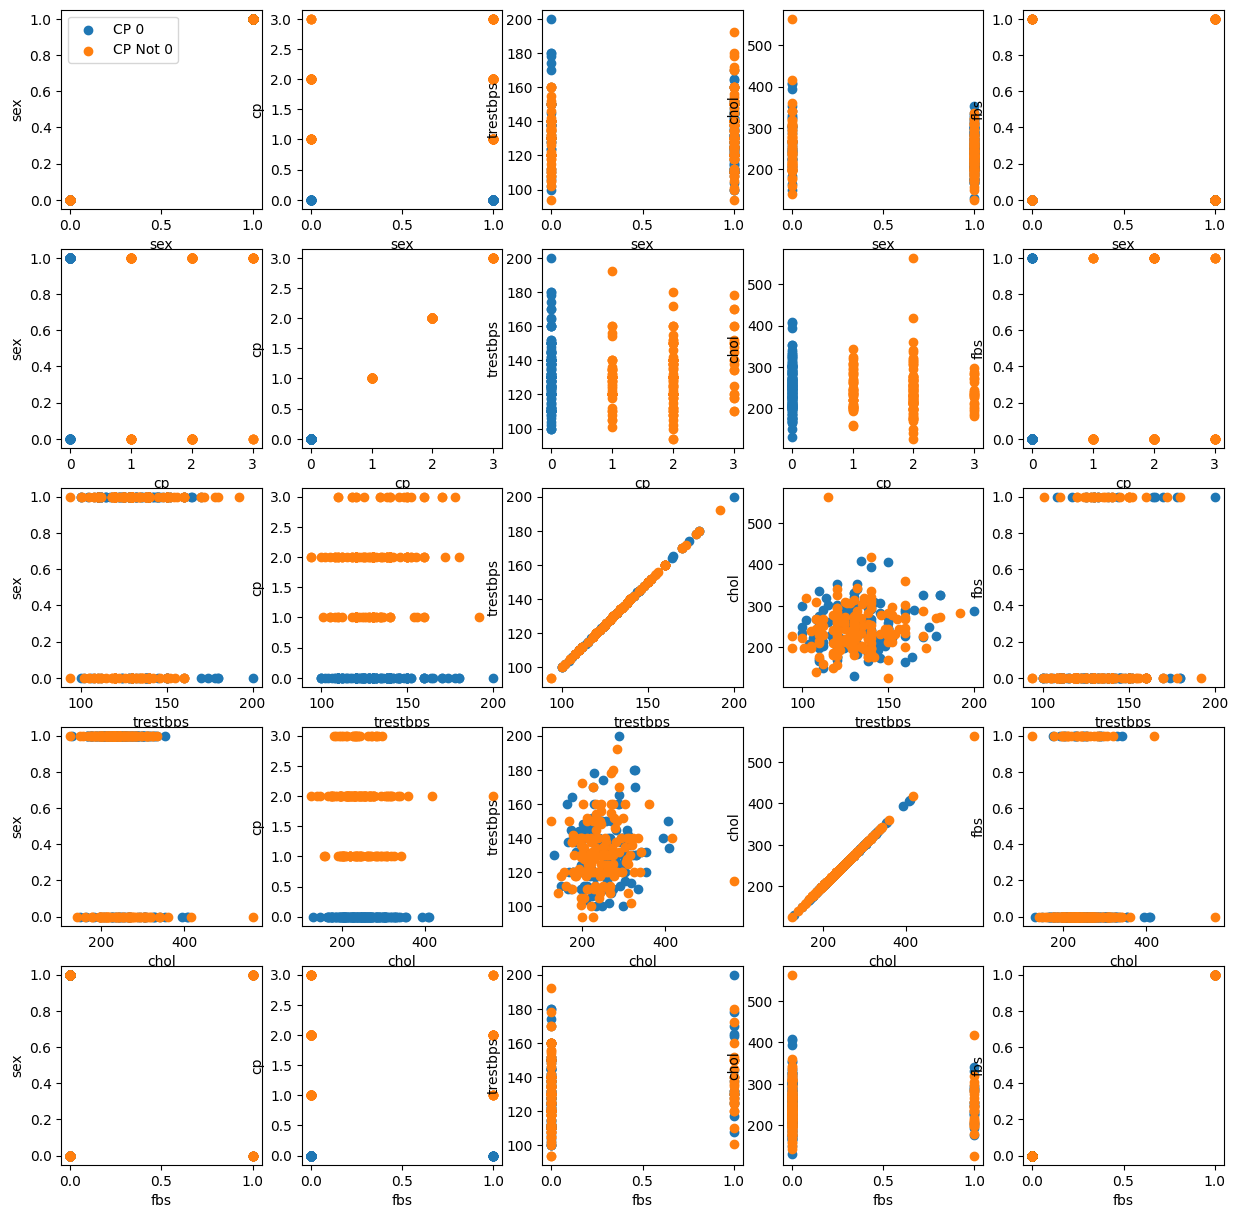

In [40]:
columns = df.columns[1:6]
n_columns=len(columns)
plt.figure(figsize=(15,15))

plot_i=0
for i,x_var_name in enumerate(columns):
    for j,y_var_name in enumerate(columns):
        plot_i+=1
        plt.subplot(n_columns,n_columns,plot_i)
        make_legend = plot_i==1
        compare_scatter(df,x_var_name,y_var_name,selection_dict,make_legend=make_legend)



## Pair Plot

Since the scatter plot of a random variable against itself is trivial, we can replace the diagonal plots above with the 1D histograms

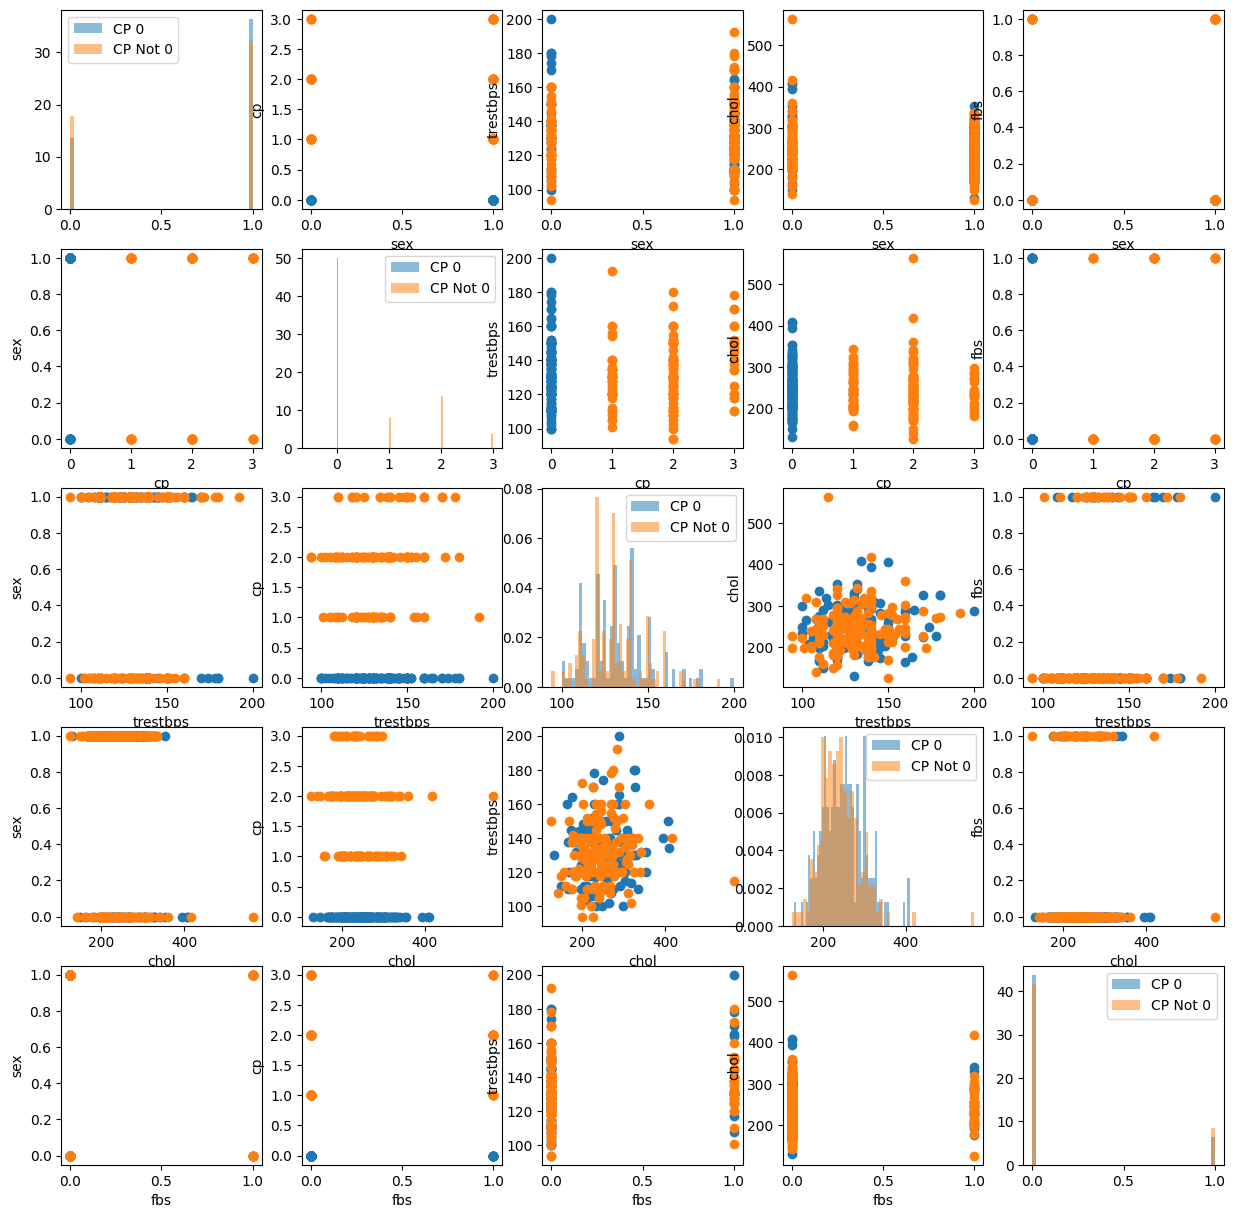

In [41]:
# Pair plot

columns = df.columns[1:6]
n_columns=len(columns)
plt.figure(figsize=(15,15))

plot_i=0
for i,x_var_name in enumerate(columns):
    for j,y_var_name in enumerate(columns):
        plot_i+=1
        plt.subplot(n_columns,n_columns,plot_i)
        make_legend = plot_i==1
        if i==j:
            compare_distributions(df,x_var_name,
                     selection_dict,
                     alpha=0.5,
                     density=1,
                     bins=50,
                     )
        else:
            compare_scatter(df,x_var_name,y_var_name,selection_dict,make_legend=make_legend)

Seabord makes pairplots easy:

In [42]:
import seaborn as sns

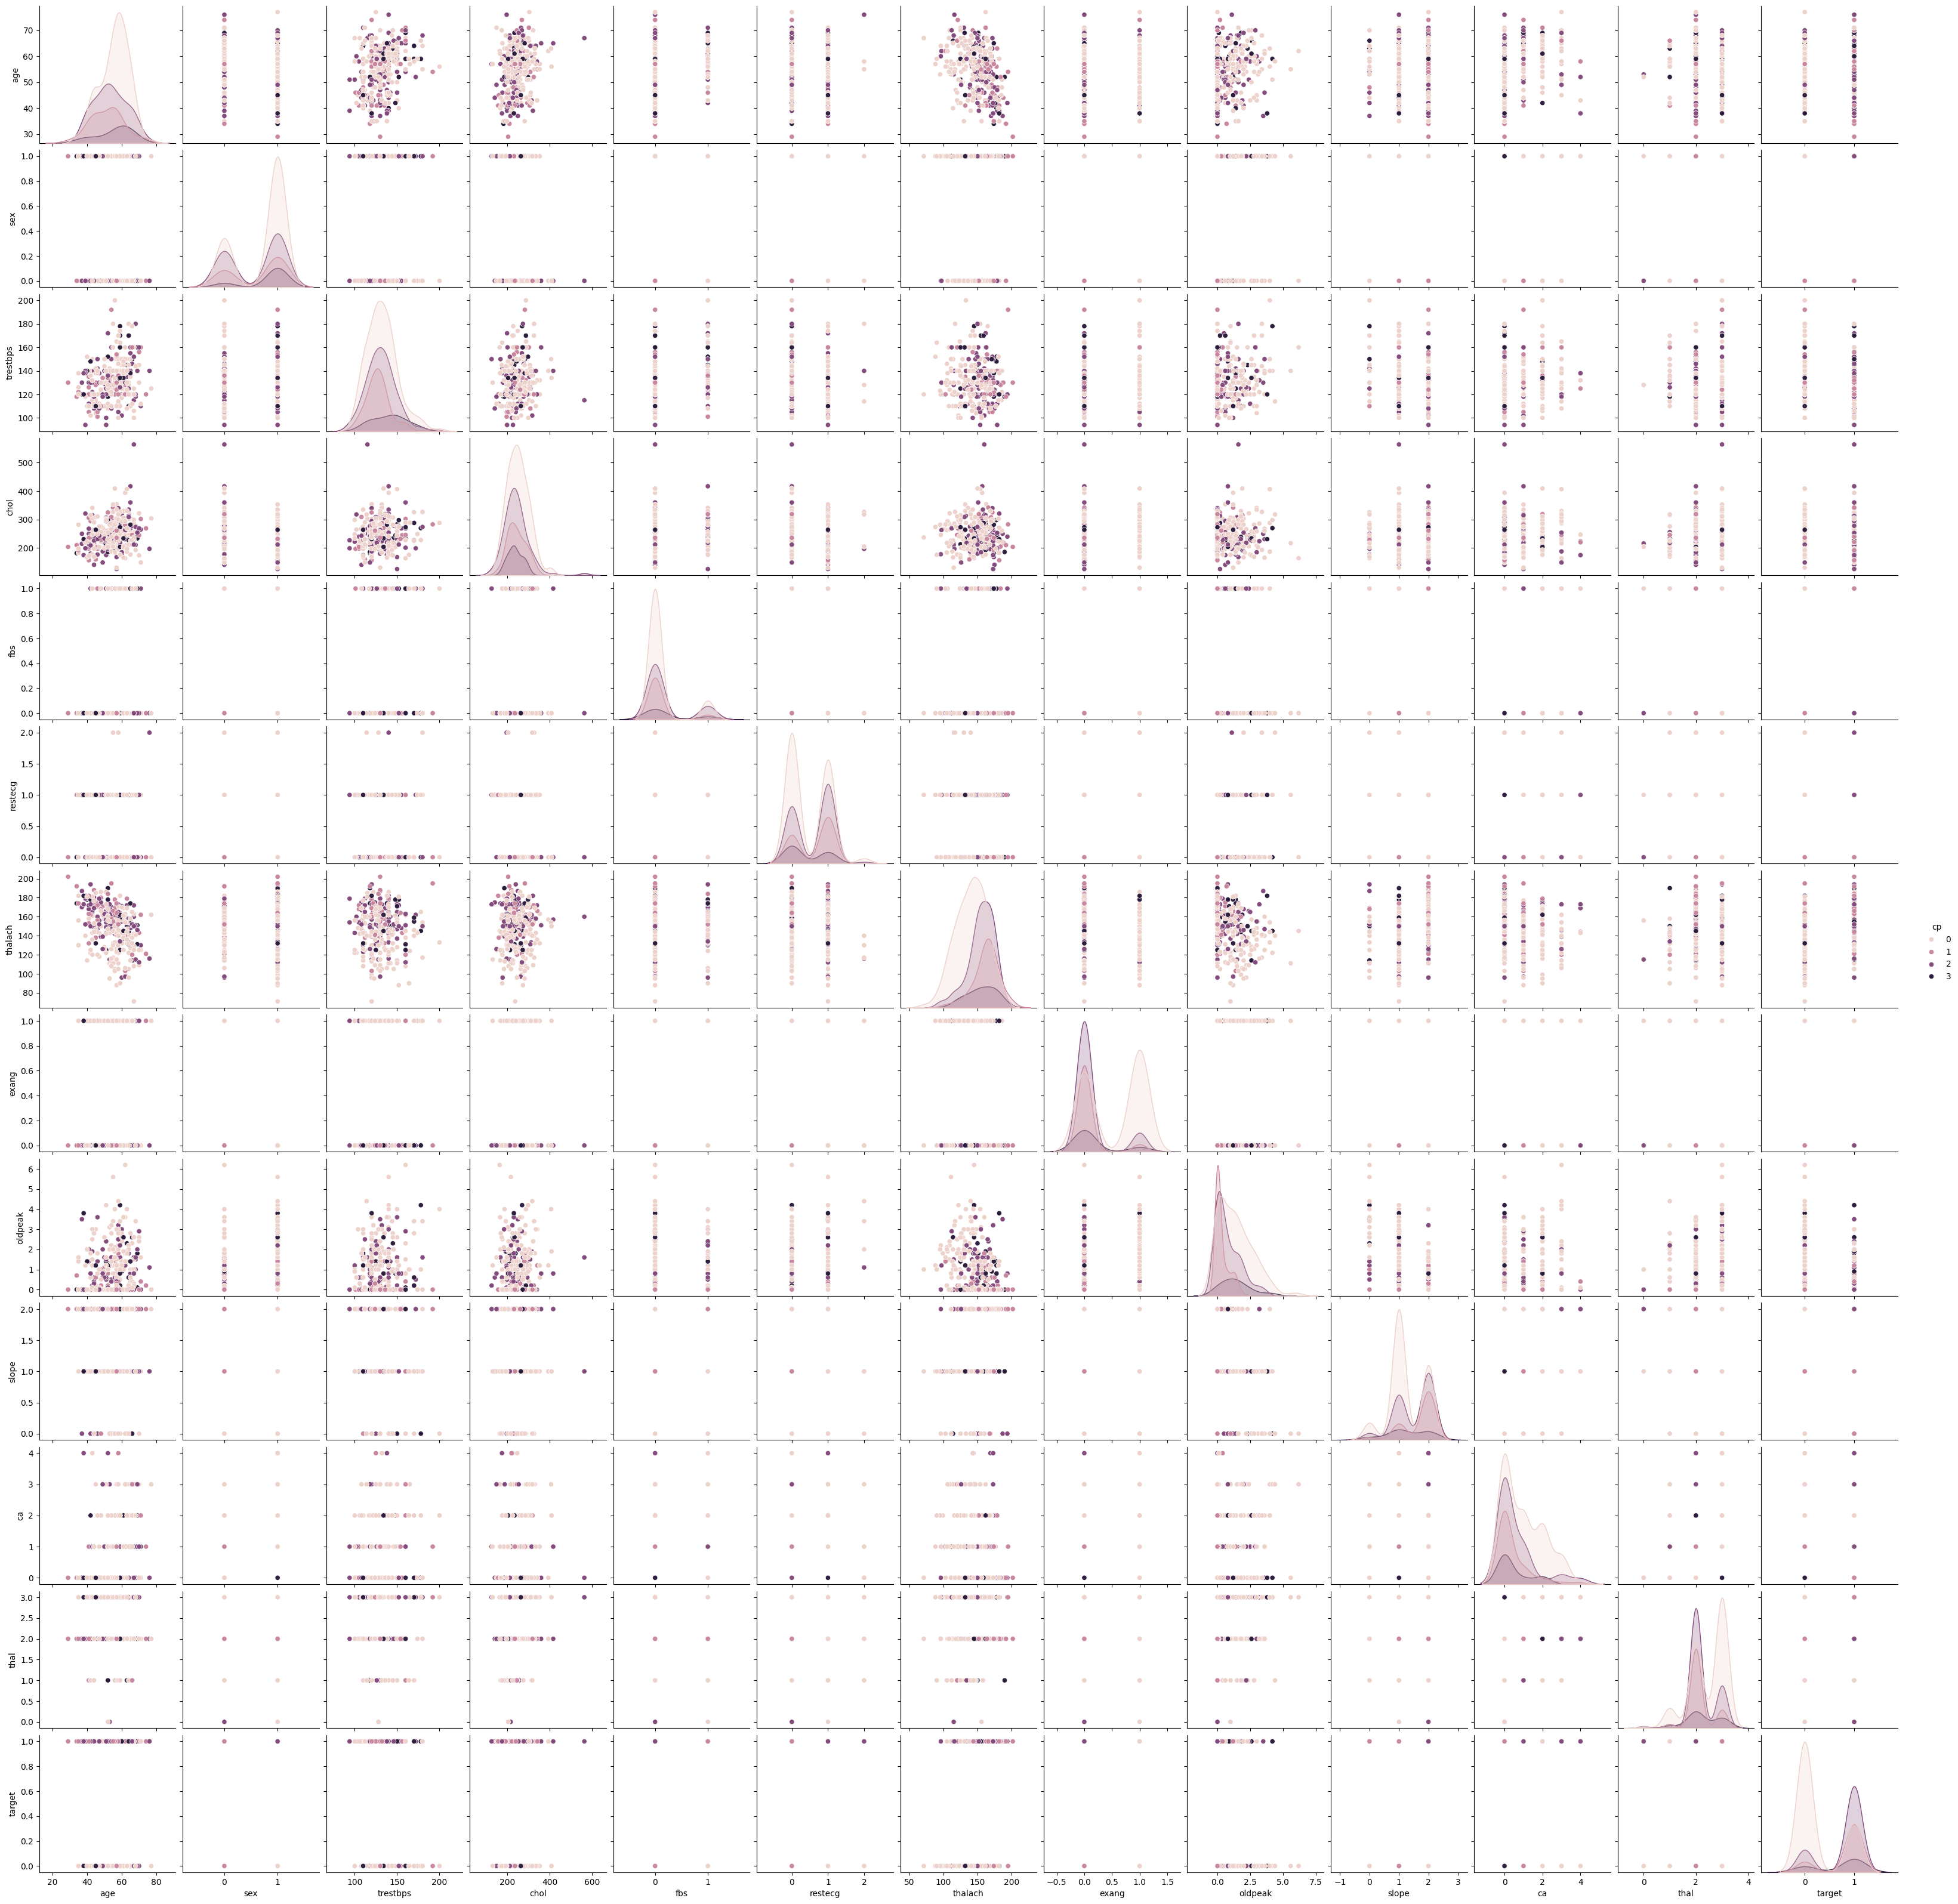

In [43]:
sns.pairplot(df,hue="cp")

### How about 3D?

For datasets of random variables, the usefulness of 3D plots are often similar to 1D plots above... not very useful. There are some instances where 3D plots are likely to show up in data analysis:

* 3D visualizations of 2D histograms. Lets quickly look at [example for matplotlib](https://matplotlib.org/stable/gallery/mplot3d/hist3d.html)
* 3D Scatter plots.
* Contour plots. Lets quickly look at [matplotlib contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html).

**Mini-workflow block**

The next few cells are meant to be read as *one* block: we run a short sequence of commands to answer a single question about the data.

*(First line: `z,x,y,_=plt.hist2d(df["thalach"],df["chol"])`)*

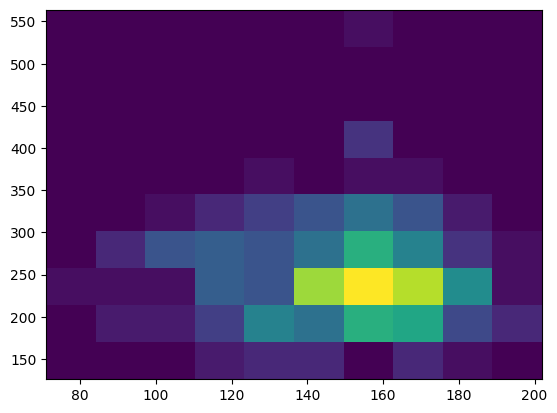

In [44]:
z,x,y,_=plt.hist2d(df["thalach"],df["chol"])

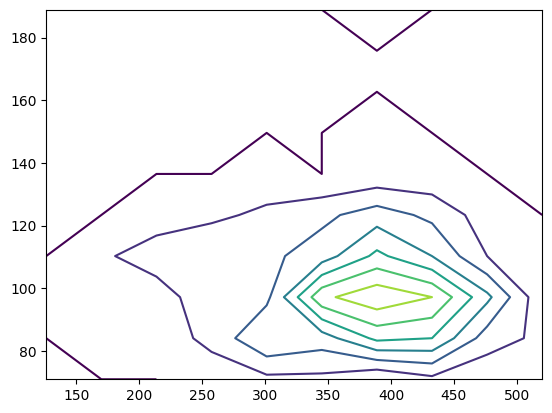

In [45]:
plt.contour(y[:-1],x[:-1],np.array(z).transpose())

# Lecture 13 (Part 2): Basic Data Manipulation

*(Merged into the same notebook for convenience.)*

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Workplace Fatalities by State Data

Lets look at some workforce data... unfortunately the source site is no longer avaliable.

A note about Jupyter: a code cell can run **Python**, but it can also run **shell commands** if the line starts with `!`.  
We’ll use that to peek at the files in the working directory and quickly inspect a CSV before loading it with pandas.

In [89]:
!ls -lh

total 32376
-rw-------@ 1 afarbin  staff   4.8K Mar  4 09:06 2012_Workplace_Fatalities_by_State.csv
-rw-------@ 1 afarbin  staff    11K Mar  4 09:06 heart.csv
-rw-------@ 1 afarbin  staff   7.7M Mar  4 10:36 Lecture.13.a.ipynb
-rw-------@ 1 afarbin  staff   473K Mar  4 09:06 Lecture.13.b.ipynb
-rw-------@ 1 afarbin  staff   7.6M Mar  4 14:07 Lecture.13.merged.ipynb


In [48]:
!head 2012_Workplace_Fatalities_by_State.csv 

State,"Number of Fatalities, 2012","Rate of Fatalities, 2012","State Rank, Fatalities 2012",Number of Injuries/Illnesses 2012,Injuries/Illnesses 2012 Rate,Penalties FY 2013 (Average $),Penalties FY 2013 (Rank),Inspectors,Years to Inspect Each Workplace Once,State or Federal Program
"South Carolina
(33.99882060100049, -81.04536765699964)",63,3.5,25,36200,3,492,49,24,111,State
"West Virginia
(38.665511497000466, -80.71263935099967)",49,6.9,46,19800,4.1,1798,27,7,173,Federal
"Massachusetts
(42.27687306500047, -72.08268985899963)",44,1.4,1,69700,3.1,1929,21,33,123,Federal
"Tennessee
(35.680943063000484, -85.77448642199965)",101,3.8,30,65100,3.5,727,45,30,82,State
"Oklahoma


In [49]:
df=pd.read_csv("2012_Workplace_Fatalities_by_State.csv")

In [50]:
df

,State,"Number of Fatalities, 2012","Rate of Fatalities, 2012","State Rank, Fatalities 2012",Number of Injuries/Illnesses 2012,Injuries/Illnesses 2012 Rate,Penalties FY 2013 (Average $),Penalties FY 2013 (Rank),Inspectors,Years to Inspect Each Workplace Once,State or Federal Program
0,"South Carolina\n(33.99882060100049, -81.045367...",63.0,3.5,25.0,36200.0,3.0,492.0,49.0,24.0,111.0,State
1,"West Virginia\n(38.665511497000466, -80.712639...",49.0,6.9,46.0,19800.0,4.1,1798.0,27.0,7.0,173.0,Federal
2,"Massachusetts\n(42.27687306500047, -72.0826898...",44.0,1.4,1.0,69700.0,3.1,1929.0,21.0,33.0,123.0,Federal
3,"Tennessee\n(35.680943063000484, -85.7744864219...",101.0,3.8,30.0,65100.0,3.5,727.0,45.0,30.0,82.0,State
4,"Oklahoma\n(35.472034350000456, -97.52106845499...",97.0,6.1,42.0,39000.0,3.6,1872.0,24.0,19.0,131.0,Federal
5,"Illinois\n(40.48501278700047, -88.99770813999965)",146.0,2.5,10.0,124900.0,3.2,1876.0,23.0,74.0,137.0,Federal
6,"Nebraska\n(41.64104043900045, -99.36571864599966)",48.0,5.2,38.0,24300.0,3.9,2565.0,5.0,9.0,128.0,Federal
7,"Delaware\n(39.00883351400046, -75.57773943699965)",14.0,3.1,18.0,7900.0,2.8,2406.0,6.0,5.0,175.0,Federal
8,"Hawaii\n(21.30485166200043, -157.85774691599974)",20.0,3.4,22.0,13700.0,3.8,964.0,39.0,20.0,79.0,State
9,"Iowa\n(42.469404401000475, -93.81648936699969)",97.0,6.6,44.0,45600.0,4.5,790.0,43.0,26.0,98.0,State


In [51]:
df.columns[1]

'Number of Fatalities, 2012'

In [52]:
# To access a column
df[df.columns[1]][:50]

0      63.0
1      49.0
2      44.0
3     101.0
4      97.0
5     146.0
6      48.0
7      14.0
8      20.0
9      97.0
10     60.0
11    218.0
12    149.0
13     88.0
14    137.0
15    115.0
16    146.0
17     14.0
18     39.0
19    194.0
20     31.0
21    202.0
22     39.0
23     19.0
24     34.0
25     11.0
26     63.0
27     42.0
28     91.0
29     72.0
30     84.0
31     36.0
32     43.0
33     82.0
34    161.0
35     35.0
36     70.0
37     76.0
38     19.0
39     67.0
40    114.0
41     63.0
42    116.0
43    101.0
44      8.0
45     31.0
46     92.0
47     65.0
48    536.0
49    375.0
Name: Number of Fatalities, 2012, dtype: float64

Lets find the state with the max number of fatalities:

In [53]:
# Max of a column
# Note that the last 4 rows are not states
np.max(df[df.columns[1]][0:50])

np.float64(536.0)

In [54]:
# What was the index of the max?
np.argmax(df[df.columns[1]][0:50])

np.int64(48)

In [55]:
# What was the state?
df[df.columns[0]][np.argmax(df[df.columns[1]][0:50])]

'Texas\n(31.827243635000457, -99.4267664729997)'

The state names aren't quite right... lets look:

In [56]:
# State names:
df[df.columns[0]][0:50]

0     South Carolina\n(33.99882060100049, -81.045367...
1     West Virginia\n(38.665511497000466, -80.712639...
2     Massachusetts\n(42.27687306500047, -72.0826898...
3     Tennessee\n(35.680943063000484, -85.7744864219...
4     Oklahoma\n(35.472034350000456, -97.52106845499...
5     Illinois\n(40.48501278700047, -88.99770813999965)
6     Nebraska\n(41.64104043900045, -99.36571864599966)
7     Delaware\n(39.00883351400046, -75.57773943699965)
8      Hawaii\n(21.30485166200043, -157.85774691599974)
9        Iowa\n(42.469404401000475, -93.81648936699969)
10    Arizona\n(34.865973091000455, -111.76380949799...
11    Florida\n(28.932042899000464, -81.92895558499964)
12    Virginia\n(37.54268075100049, -78.45788924199968)
13    Missouri\n(38.63579372300046, -92.56629737199967)
14    Michigan\n(44.66131575600048, -84.71438724399968)
15     Indiana\n(39.76691364600049, -86.14995579899966)
16    North Carolina\n(35.46622388600048, -79.159249...
17    New Hampshire\n(43.6559537330005, -71.5003

In [57]:
# Clean it up
state_names=list(map(lambda x: x.split("\n")[0],df[df.columns[0]][0:50]))
state_names

['South Carolina',
 'West Virginia',
 'Massachusetts',
 'Tennessee',
 'Oklahoma',
 'Illinois',
 'Nebraska',
 'Delaware',
 'Hawaii',
 'Iowa',
 'Arizona',
 'Florida',
 'Virginia',
 'Missouri',
 'Michigan',
 'Indiana',
 'North Carolina',
 'New Hampshire',
 'New Mexico',
 'Pennsylvania',
 'South Dakota',
 'New York',
 'Utah',
 'Maine',
 'Montana',
 'Vermont',
 'Arkansas',
 'Nevada',
 'Kentucky',
 'Maryland',
 'Alabama',
 'Connecticut',
 'Oregon',
 'Colorado',
 'Ohio',
 'Wyoming',
 'Minnesota',
 'Kansas',
 'Idaho',
 'Washington',
 'Wisconsin',
 'Mississippi',
 'Louisiana',
 'Georgia',
 'Rhode Island',
 'Alaska',
 'New Jersey',
 'North Dakota',
 'Texas',
 'California']

In [58]:
longitude=list(map(lambda x: float(x.split("\n")[1].split(",")[0][1:]),df[df.columns[0]][0:50]))
latitude=list(map(lambda x: float(x.split("\n")[1].split(",")[1][:-1]),df[df.columns[0]][0:50]))

coordinates=list(zip(longitude,latitude))
coordinates

[(33.99882060100049, -81.04536765699964),
 (38.665511497000466, -80.71263935099967),
 (42.27687306500047, -72.08268985899963),
 (35.680943063000484, -85.77448642199965),
 (35.472034350000456, -97.52106845499969),
 (40.48501278700047, -88.99770813999965),
 (41.64104043900045, -99.36571864599966),
 (39.00883351400046, -75.57773943699965),
 (21.30485166200043, -157.85774691599974),
 (42.469404401000475, -93.81648936699969),
 (34.865973091000455, -111.76380949799972),
 (28.932042899000464, -81.92895558499964),
 (37.54268075100049, -78.45788924199968),
 (38.63579372300046, -92.56629737199967),
 (44.66131575600048, -84.71438724399968),
 (39.76691364600049, -86.14995579899966),
 (35.46622388600048, -79.15924924699965),
 (43.6559537330005, -71.50035726399966),
 (34.52088247800049, -106.24057768899968),
 (40.79373106100047, -77.86069775999965),
 (44.35313342000046, -100.37352811899967),
 (42.82700023900048, -75.54396639699968),
 (39.36070374600047, -111.5871285339997),
 (45.254228663000504, -68

In [59]:
df.shape

(54, 11)

In [60]:
df["State"]= state_names+[""]*3+["Total/Average"]
df["Longitude"]=longitude+[0.]*4
df["Latitude"]=latitude+[0.]*4

In [61]:
df

,State,"Number of Fatalities, 2012","Rate of Fatalities, 2012","State Rank, Fatalities 2012",Number of Injuries/Illnesses 2012,Injuries/Illnesses 2012 Rate,Penalties FY 2013 (Average $),Penalties FY 2013 (Rank),Inspectors,Years to Inspect Each Workplace Once,State or Federal Program,Longitude,Latitude
0,South Carolina,63.0,3.5,25.0,36200.0,3.0,492.0,49.0,24.0,111.0,State,33.998821,-81.045368
1,West Virginia,49.0,6.9,46.0,19800.0,4.1,1798.0,27.0,7.0,173.0,Federal,38.665511,-80.712639
2,Massachusetts,44.0,1.4,1.0,69700.0,3.1,1929.0,21.0,33.0,123.0,Federal,42.276873,-72.082690
3,Tennessee,101.0,3.8,30.0,65100.0,3.5,727.0,45.0,30.0,82.0,State,35.680943,-85.774486
4,Oklahoma,97.0,6.1,42.0,39000.0,3.6,1872.0,24.0,19.0,131.0,Federal,35.472034,-97.521068
5,Illinois,146.0,2.5,10.0,124900.0,3.2,1876.0,23.0,74.0,137.0,Federal,40.485013,-88.997708
6,Nebraska,48.0,5.2,38.0,24300.0,3.9,2565.0,5.0,9.0,128.0,Federal,41.641040,-99.365719
7,Delaware,14.0,3.1,18.0,7900.0,2.8,2406.0,6.0,5.0,175.0,Federal,39.008834,-75.577739
8,Hawaii,20.0,3.4,22.0,13700.0,3.8,964.0,39.0,20.0,79.0,State,21.304852,-157.857747
9,Iowa,97.0,6.6,44.0,45600.0,4.5,790.0,43.0,26.0,98.0,State,42.469404,-93.816489


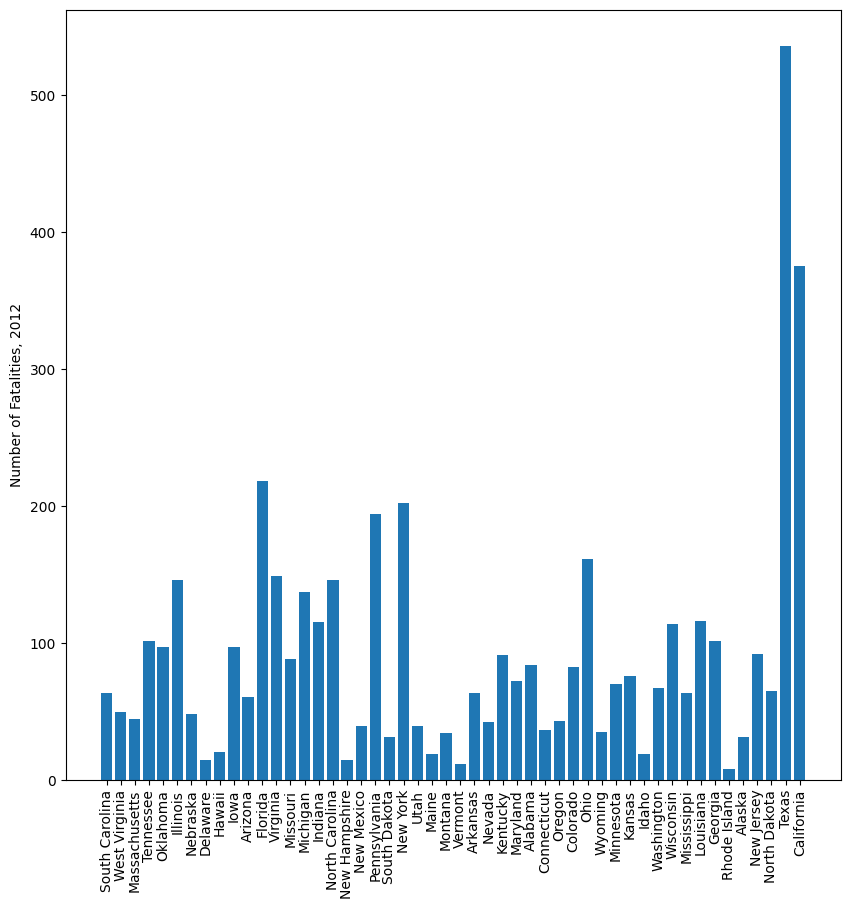

In [62]:
fig,ax= plt.subplots(1,1,figsize=(10,10))

ax.bar(range(50),df[df.columns[1]][0:50])
ax.set_xticks(range(50))
_=ax.set_xticklabels(state_names, rotation='vertical', fontsize=10)
_=ax.set_ylabel(df.columns[1])

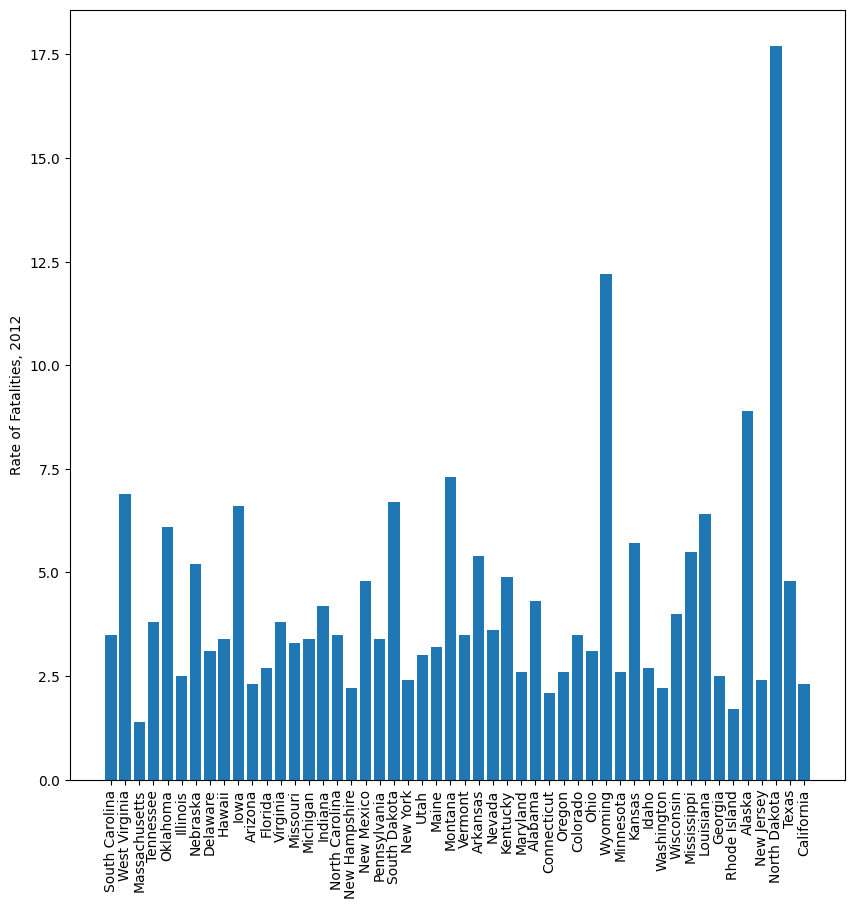

In [63]:
fig,ax= plt.subplots(1,1,figsize=(10,10))

ax.bar(range(50),df[df.columns[2]][0:50])
ax.set_xticks(range(50))
_=ax.set_xticklabels(state_names, rotation='vertical', fontsize=10)
_=ax.set_ylabel(df.columns[2])

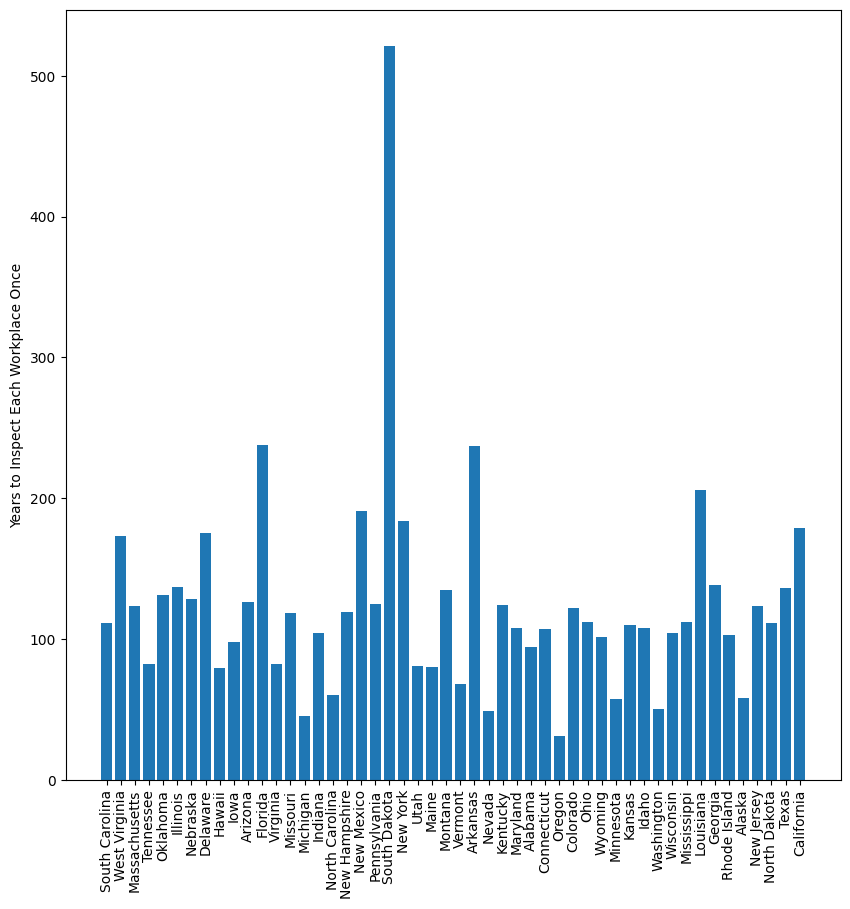

In [64]:
fig,ax= plt.subplots(1,1,figsize=(10,10))

ax.bar(range(50),df[df.columns[9]][0:50])
ax.set_xticks(range(50))
_=ax.set_xticklabels(state_names, rotation='vertical', fontsize=10)
_=ax.set_ylabel(df.columns[9])

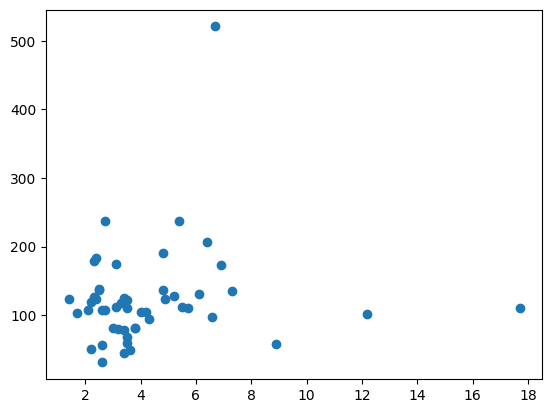

In [65]:
plt.scatter(df[df.columns[2]][0:50],df[df.columns[9]][0:50])

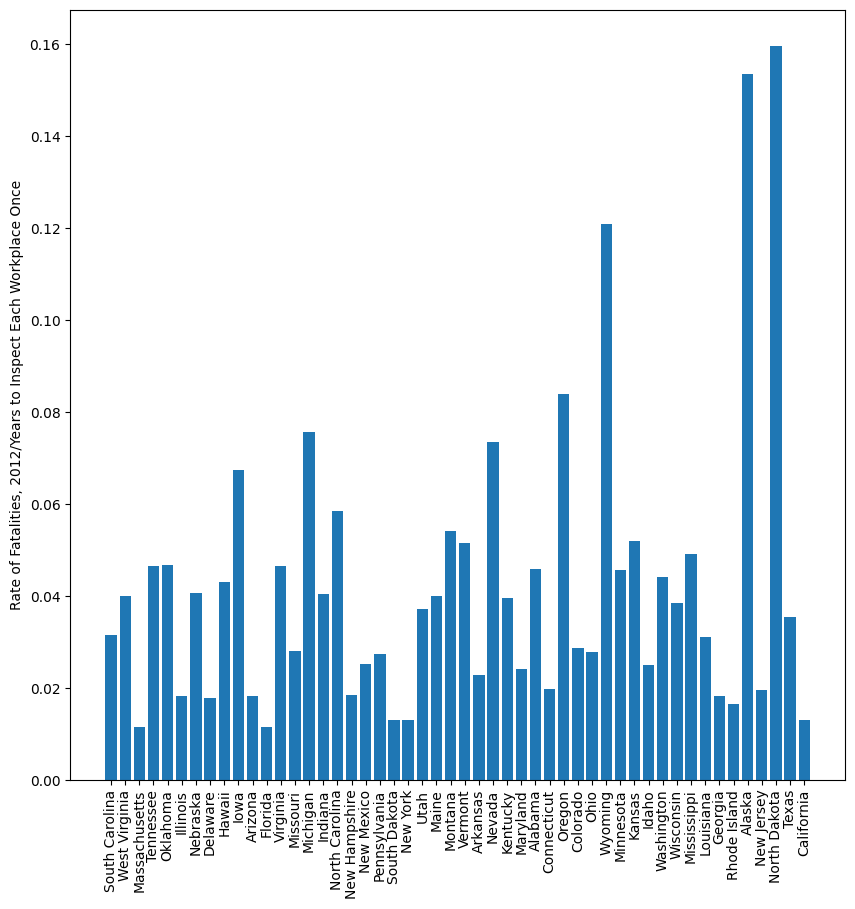

In [66]:
fig,ax= plt.subplots(1,1,figsize=(10,10))

ax.bar(range(50),df[df.columns[2]][0:50]/df[df.columns[9]][0:50])
ax.set_xticks(range(50))
_=ax.set_xticklabels(state_names, rotation='vertical', fontsize=10)
_=ax.set_ylabel(df.columns[2]+"/"+df.columns[9])